#Renewble Energy Project

# import liabrary / Font

In [164]:
import os
import math
import warnings
from functools import partial
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.font_manager as fm
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap, SymLogNorm
from matplotlib.cm import ScalarMappable
import matplotlib.patheffects as pe
import seaborn as sns

from IPython.display import HTML, display
from PIL import Image as PILImage

import flagpy as fp
from plottable import ColumnDefinition, Table
from plottable.plots import image

warnings.filterwarnings('ignore')

In [165]:
FONT_PATH = os.path.join('fonts', 'Garuda.otf')

thai_font_name = None
if os.path.exists(FONT_PATH):
    fm.fontManager.addfont(FONT_PATH)
    thai_font_name = fm.FontProperties(fname=FONT_PATH).get_name()
else:
    # Fallback: a Thai-capable font already installed on this machine
    candidates = ['Garuda', 'Noto Sans Thai', 'Leelawadee UI', 'Leelawadee', 'Tahoma', 'Cordia New', 'Loma']
    installed = {f.name for f in fm.fontManager.ttflist}
    thai_font_name = next((c for c in candidates if c in installed), None)

if thai_font_name:
    plt.rcParams['font.family'] = thai_font_name
    plt.rcParams['font.size'] = 12
    plt.rcParams['axes.unicode_minus'] = False
    print(f'Thai font ready: "{thai_font_name}"')
else:
    print("No Thai font found. Make sure the 'fonts' folder (with Garuda.otf) "
          "sits next to this notebook.")

Thai font ready: "Garuda"


In [166]:
# Locate the bundled fonts from the notebook or workspace directory.
font_dirs = [Path('fonts'), Path('dads 5001') / 'fonts']
font_dir = next((p for p in font_dirs if (p / 'Garuda.otf').is_file()), None)
if font_dir is not None:
    for filename in ['Garuda.otf', 'Garuda-Bold.otf']:
        font_path = font_dir / filename
        if font_path.is_file():
            fm.fontManager.addfont(str(font_path))
    GARUDA = fm.FontProperties(fname=str(font_dir / 'Garuda.otf')).get_name()
else:
    GARUDA = globals().get('thai_font_name') or 'Tahoma'
DEJAVU = 'DejaVu Sans'
plt.rcParams['font.family'] = GARUDA
plt.rcParams['axes.unicode_minus'] = False


# Import file

In [167]:
url = 'https://raw.githubusercontent.com/Manasafang/Transition-or-Addition/main/renewable_energy_countries_selected_v7.csv'
df = pd.read_csv(url)

print(f"Shape: {df.shape}")
print(f"Countries: {df['country'].nunique()}")
print(f"Years: {df['year'].min()} – {df['year'].max()}")
df.head()

Shape: (5381, 23)
Countries: 213
Years: 2000 – 2025


,country,continent,year,iso_code,gdp,electricity_generation,renewables_share_elec,fossil_share_elec,low_carbon_share_elec,solar_electricity,...,coal_electricity,gas_electricity,oil_electricity,other_renewable_electricity,solar_share_elec,wind_share_elec,hydro_share_elec,nuclear_share_elec,coal_share_elec,gas_share_elec
0,Afghanistan,Asia,2000,AFG,1.128379e+10,0.48,64.583,35.417,64.583,0.0,...,0.00,0.0,0.17,0.0,0.0,0.0,64.583,0.0,0.000,0.0
1,Afghanistan,Asia,2001,AFG,1.102127e+10,0.69,72.464,27.536,72.464,0.0,...,0.04,0.0,0.15,0.0,0.0,0.0,72.464,0.0,5.797,0.0
2,Afghanistan,Asia,2002,AFG,1.880487e+10,0.71,78.873,21.127,78.873,0.0,...,0.04,0.0,0.11,0.0,0.0,0.0,78.873,0.0,5.634,0.0
3,Afghanistan,Asia,2003,AFG,2.107434e+10,0.91,69.231,30.769,69.231,0.0,...,0.09,0.0,0.19,0.0,0.0,0.0,69.231,0.0,9.890,0.0
4,Afghanistan,Asia,2004,AFG,2.233257e+10,0.79,70.886,29.114,70.886,0.0,...,0.06,0.0,0.17,0.0,0.0,0.0,70.886,0.0,7.595,0.0


#Figure 1

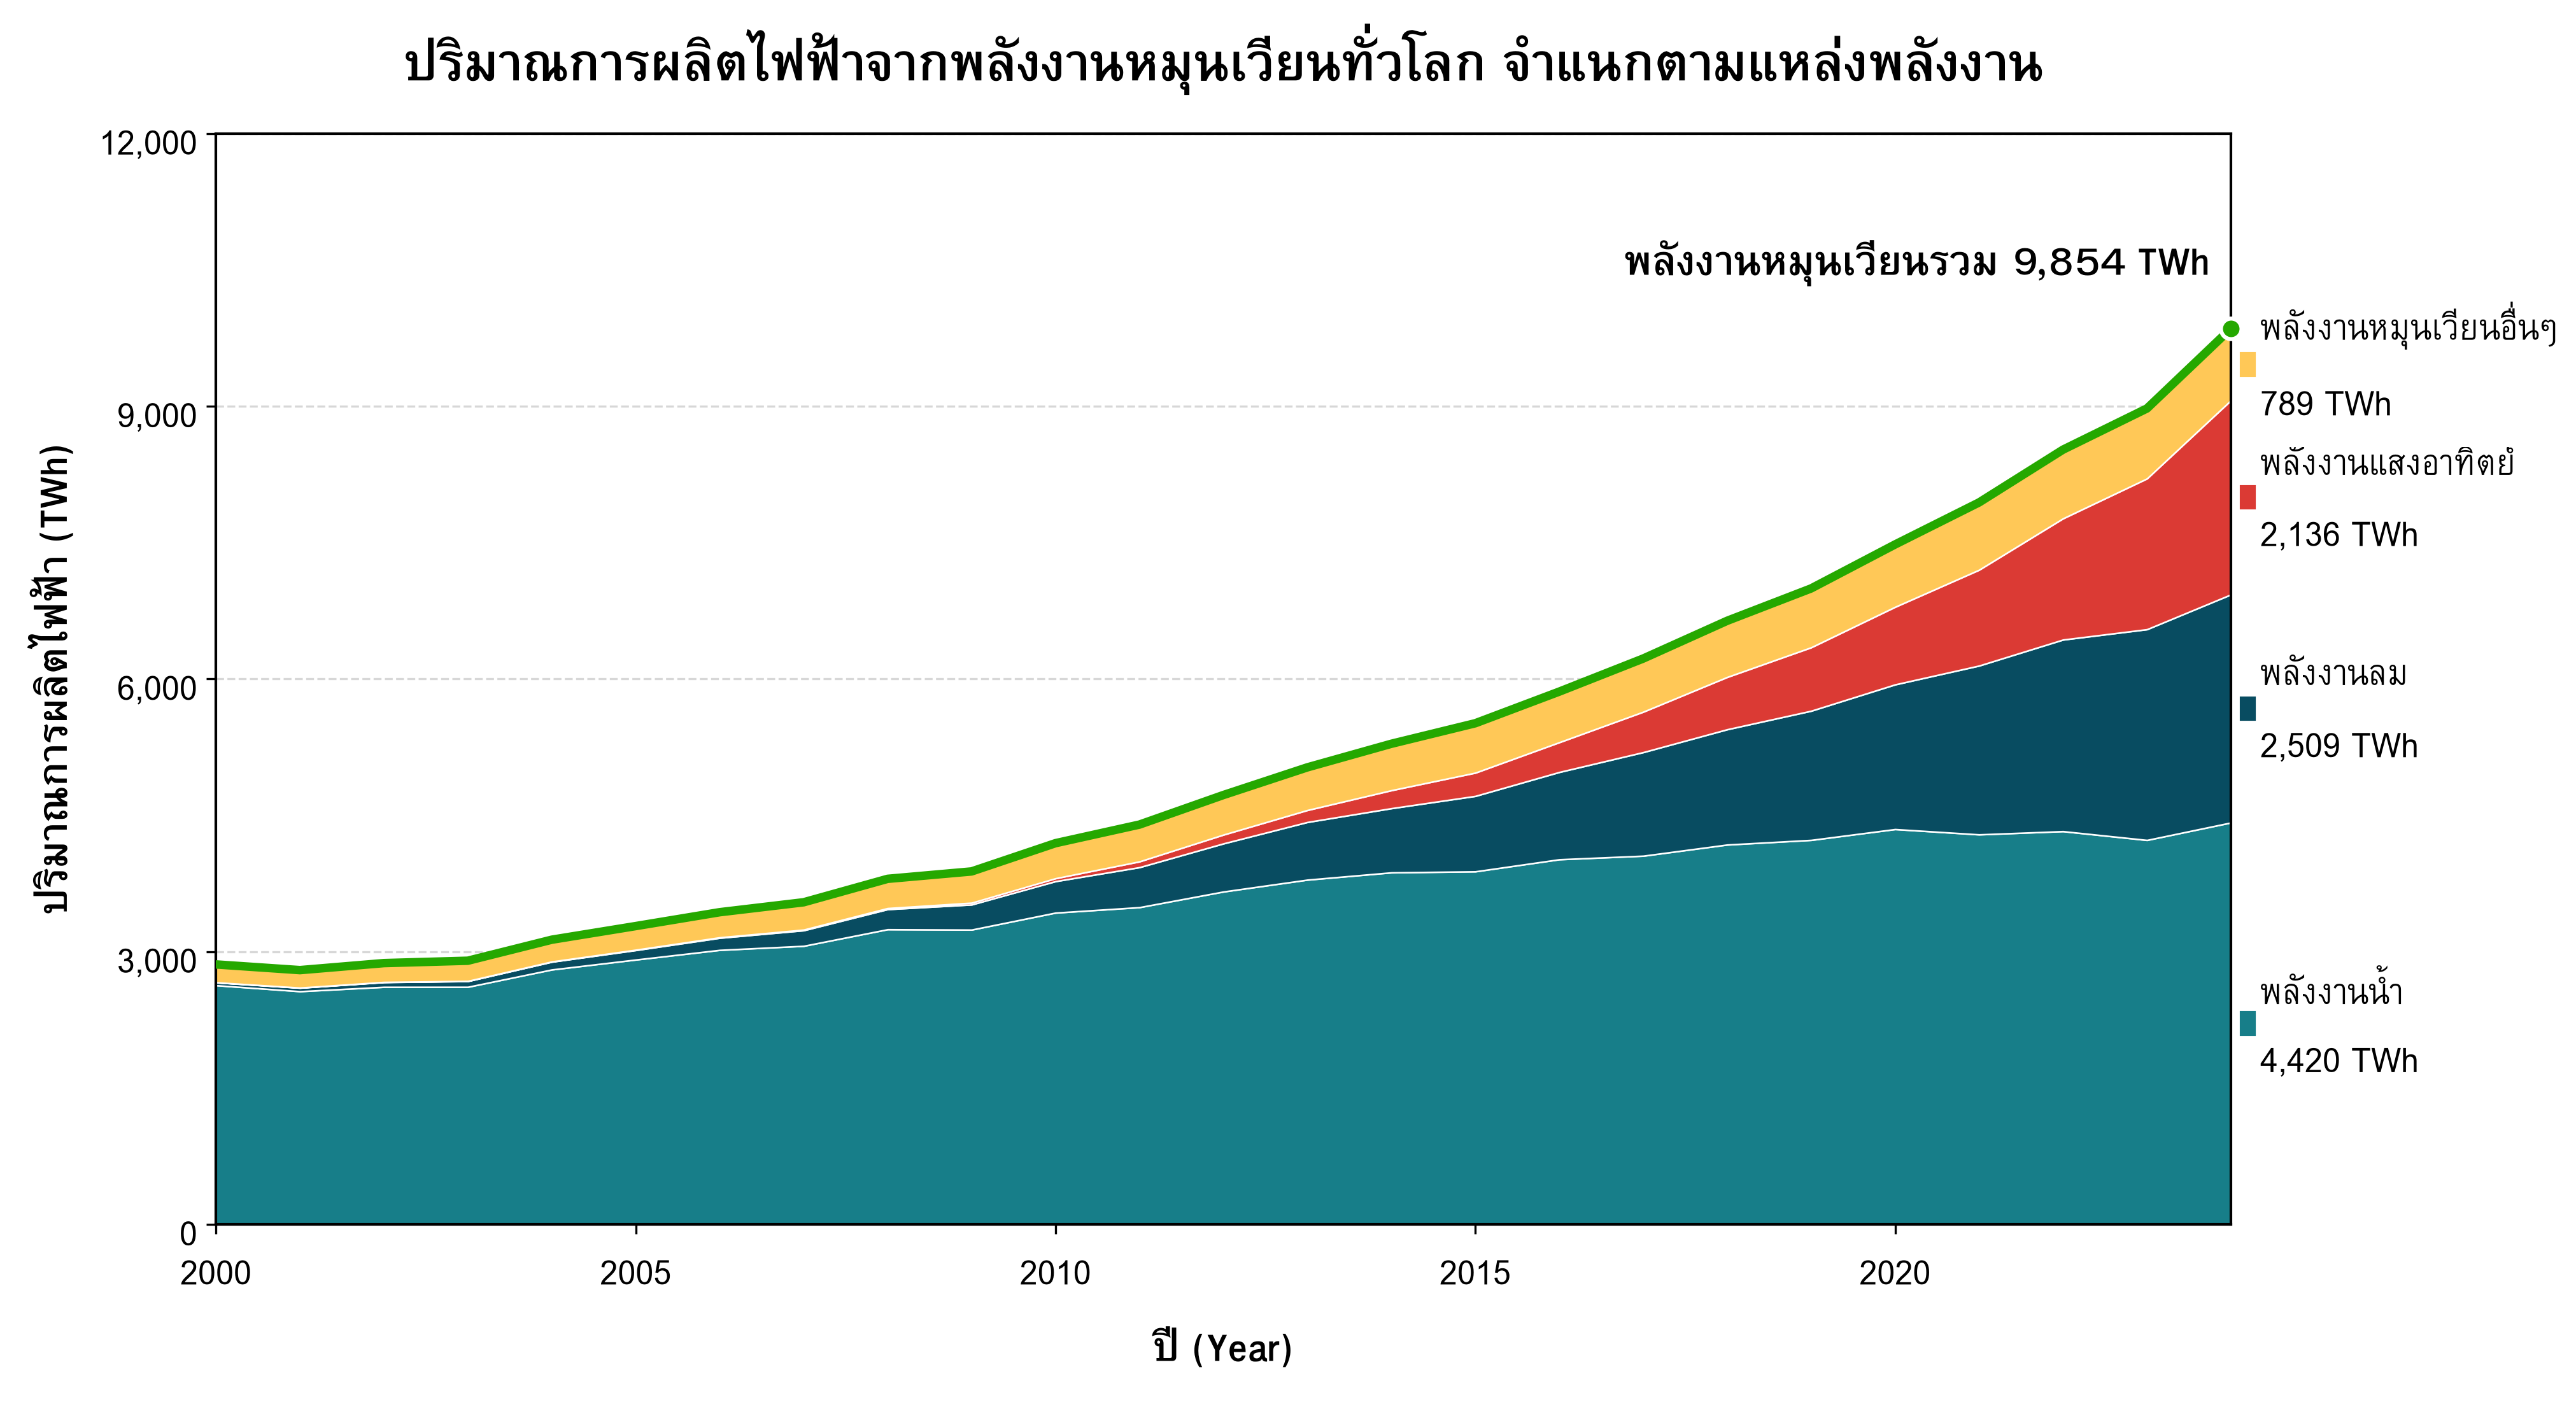

In [168]:
# ── Figure 1: พลังงานหมุนเวียนแยกตามแหล่ง (stacked) + เส้นรวม RE ──────────

# ── 1. เตรียมข้อมูล ────────────────────────────────────────────
df_fig1 = df[df['year'].between(2000, 2024)]

re_src = df_fig1.groupby('year').agg(
    hydro    = ('hydro_electricity',           'sum'),
    wind     = ('wind_electricity',            'sum'),
    solar    = ('solar_electricity',           'sum'),
    other_re = ('other_renewable_electricity', 'sum'),
    total    = ('electricity_generation',      'sum'),
    n_country= ('country',                     'nunique'),
).reset_index()

re_src['RE']       = re_src[['hydro', 'wind', 'solar', 'other_re']].sum(axis=1)
re_src['re_share'] = re_src['RE'] / re_src['total'] * 100
re_src = re_src.set_index('year')

years   = re_src.index.values
first_y = years.min()
last_y  = years.max()
re_0    = re_src.loc[first_y, 'RE']
re_1    = re_src.loc[last_y,  'RE']

# ── 2. สี ─────────────────────────────────────────────────────
# เส้นรวม RE ใช้สีหลักของ RE (#426214) ให้ต่อเนื่องกับ Figure อื่น
FILL_ALPHA = 1.0    # ความทึบของชั้นพื้นที่ (1 = ทึบ, ค่าน้อยลง = โปร่งแสงขึ้น)
C_RE = '#25A800'
SRC_STYLE = [
    # (คอลัมน์,   ชื่อไทย,        สี)
    ('hydro',    'พลังงานน้ำ',      '#177E89'),
    ('wind',     'พลังงานลม',      '#084C61'),
    ('solar',    'พลังงานแสงอาทิตย์', '#DB3A34'),
    ('other_re', 'พลังงานหมุนเวียนอื่นๆ', '#FFC857'),
]
C_TEXT  = '#000000'
C_MUTED = '#666666'

# ── 3. วาดกราฟ ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7.5), facecolor='white', dpi=300)

ax.stackplot(years,
             *[re_src[c] for c, _, _ in SRC_STYLE],
             colors=[col for _, _, col in SRC_STYLE],
             alpha=FILL_ALPHA, edgecolor='white', linewidth=0.6, zorder=2)

# เส้นทึบยอดรวม RE (= ขอบบนของชั้นซ้อน)
ax.plot(years, re_src['RE'], color=C_RE, linewidth=3.2, zorder=4,
        solid_capstyle='round')

# ตัวเลขยอดรวม RE ปีล่าสุด (ปลายเส้นสีเขียว)
ax.scatter(last_y, re_1, s=60, color=C_RE, edgecolor='white',
           linewidth=1.5, zorder=5, clip_on=False)
ax.annotate(f'พลังงานหมุนเวียนรวม {re_1:,.0f} TWh', xy=(last_y, re_1),
            xytext=(-8, 12), textcoords='offset points',
            ha='right', va='bottom', fontsize=14, fontweight='bold',
            color='#000000', zorder=6)
            
y_step = 3000
y_max  = np.ceil(re_1 * 1.15 / y_step) * y_step

# ── 4. ป้ายชื่อชั้นที่ปลายขวา (แทน legend) ─────────────────────
cum = 0
for col, name, color in SRC_STYLE:
    v = re_src.loc[last_y, col]
    ax.text(last_y + 0.35, cum + v / 2, f'{name}\n{v:,.0f} TWh',
            ha='left', va='center', fontsize=12, color=C_TEXT,
            linespacing=1.3, clip_on=False,
            bbox=dict(boxstyle='square,pad=0.15', fc='white', ec='none'))
    ax.add_patch(Rectangle((last_y + 0.12, cum + v / 2 - 120), 0.16, 240,
                           color=color, alpha=FILL_ALPHA, clip_on=False, zorder=5))
    cum += v

# ── 5. แกน / รูปแบบ ───────────────────────────────────────────
ax.set_xlim(first_y, last_y)
ax.set_ylim(0, y_max)
ax.set_yticks(np.arange(0, y_max + y_step, y_step))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax.set_xticks(np.arange(2000, 2025, 5))
ax.tick_params(labelsize=12)

ax.set_title('ปริมาณการผลิตไฟฟ้าจากพลังงานหมุนเวียนทั่วโลก จำแนกตามแหล่งพลังงาน',
             fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('ปี (Year)', fontsize=14,fontweight='bold')
ax.set_ylabel('ปริมาณการผลิตไฟฟ้า (TWh)', fontsize=14,fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)
for sp in ax.spines.values():
    sp.set_visible(True)
    sp.set_color('#000000')
    sp.set_linewidth(1.0)

plt.tight_layout()
plt.subplots_adjust(right=0.84)
plt.savefig('figure1.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


#Figure 2

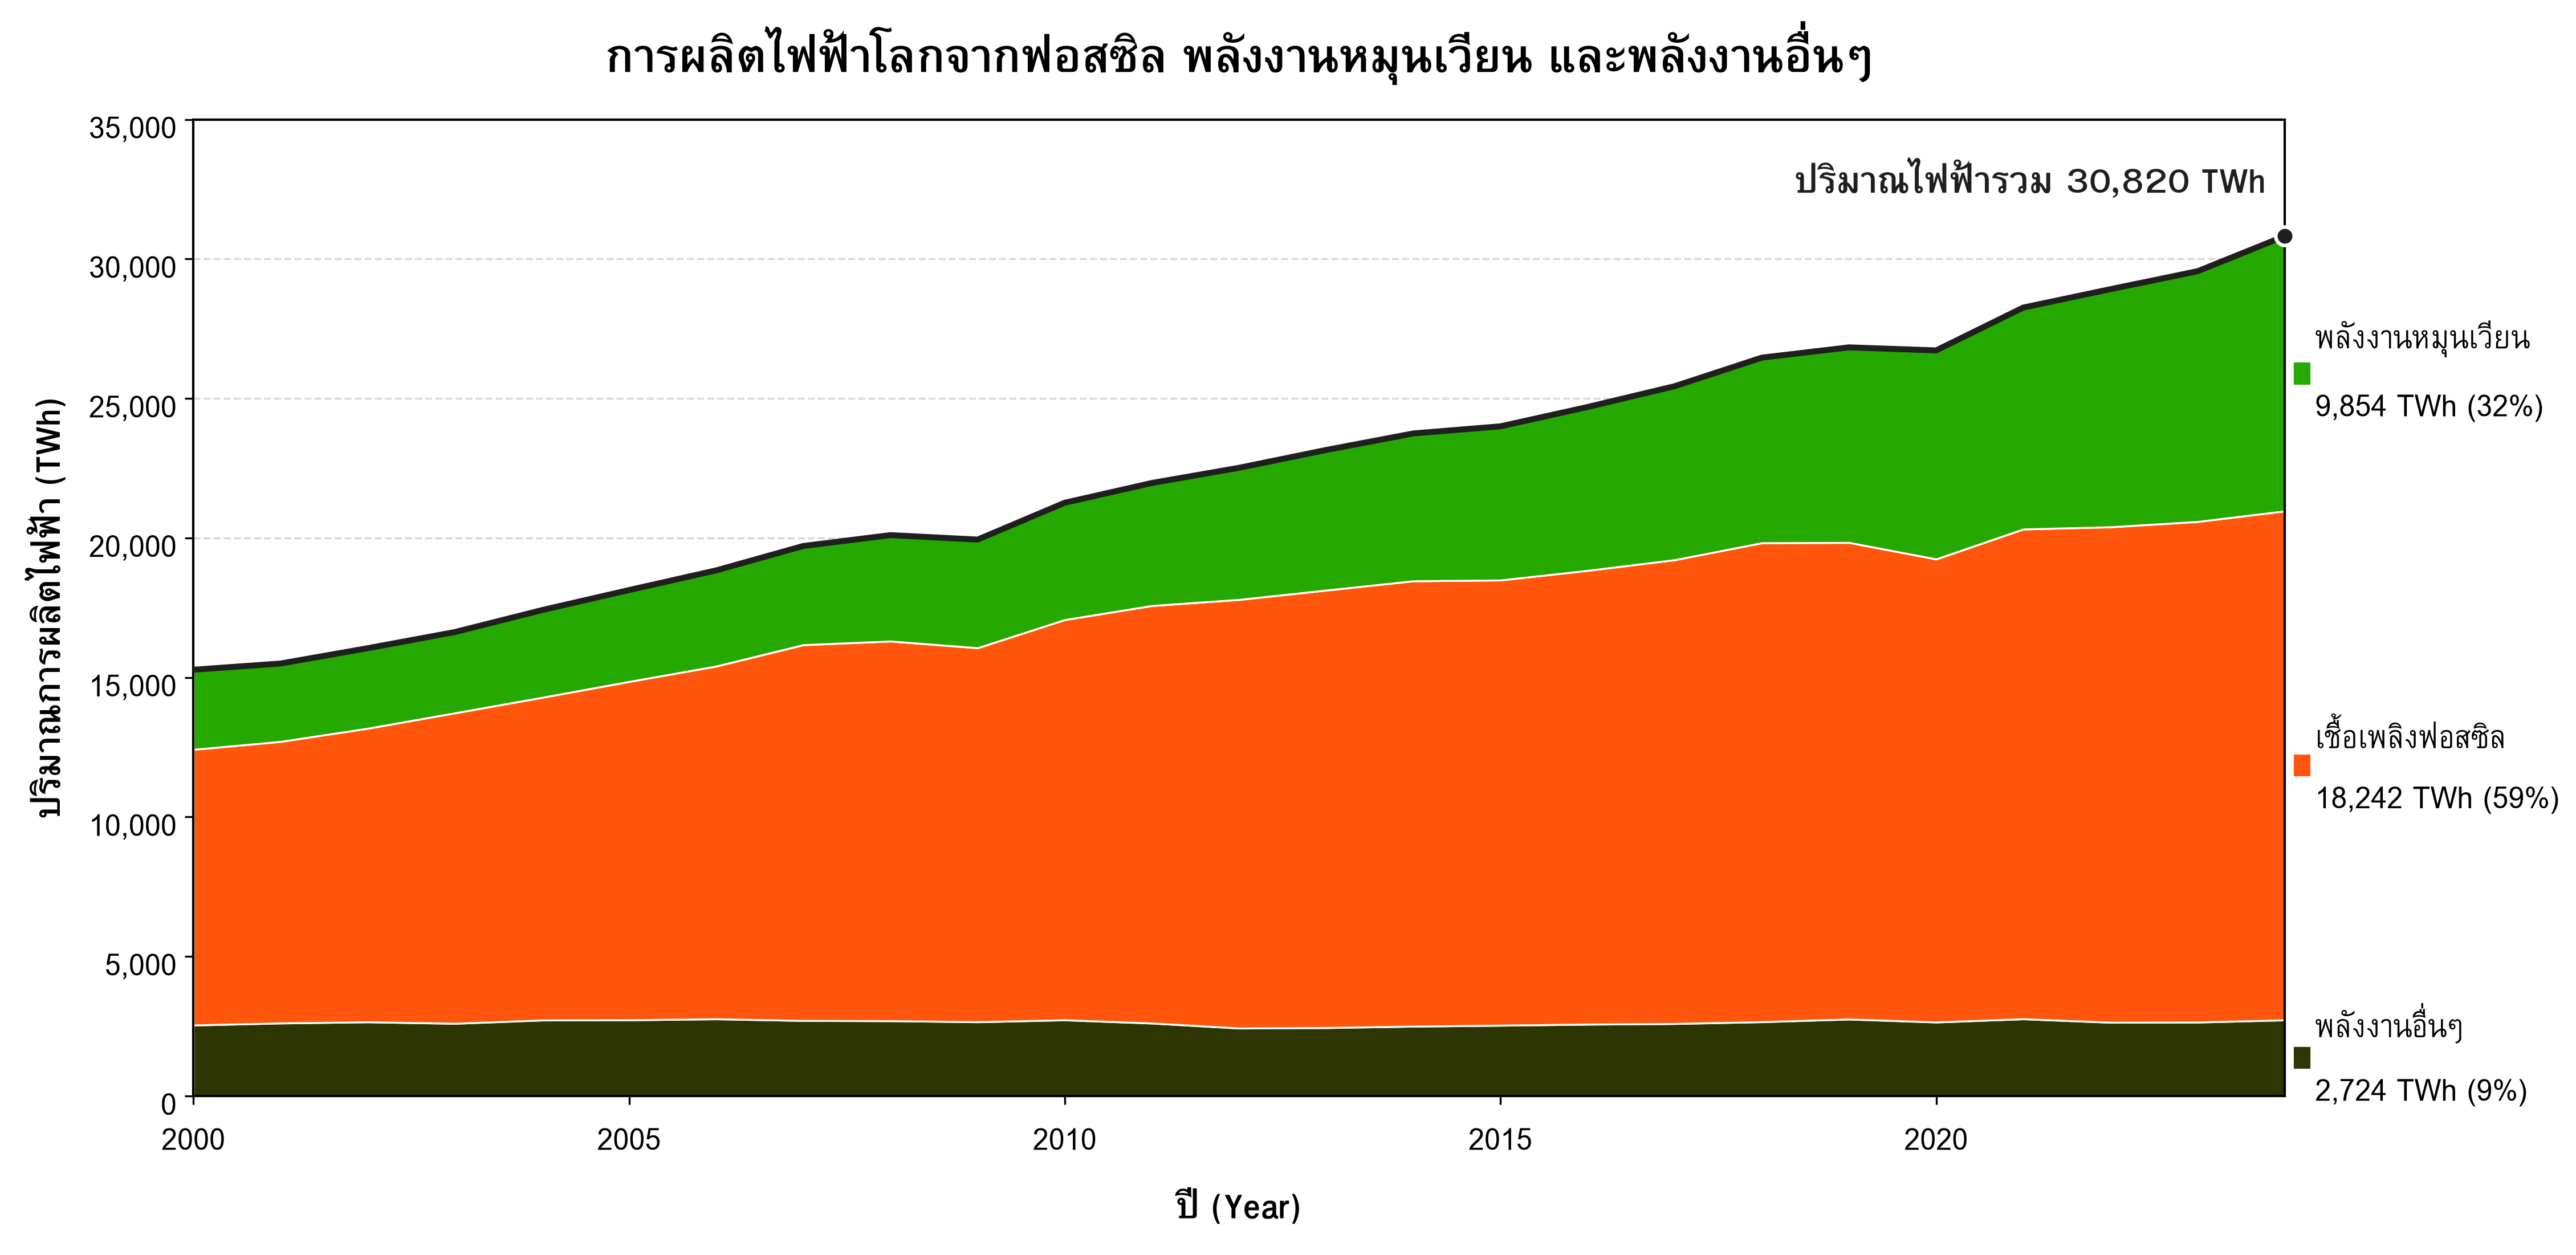

In [169]:
world = df.groupby('year').agg(
    fossil  = ('coal_electricity',  'sum'),
    gas     = ('gas_electricity',   'sum'),
    oil     = ('oil_electricity',   'sum'),
    solar   = ('solar_electricity', 'sum'),
    wind    = ('wind_electricity',  'sum'),
    hydro   = ('hydro_electricity', 'sum'),
    other_re= ('other_renewable_electricity', 'sum'),
    Nuclear = ('nuclear_electricity', 'sum'),
).reset_index()

world['Fossil']  = world['fossil'] + world['gas'] + world['oil']
world['RE']      = world['solar'] + world['wind'] + world['hydro'] + world['other_re']
world = world[world['year'].between(2000, 2024)].set_index('year')
world['Total']   = world[['Nuclear', 'Fossil', 'RE']].sum(axis=1)

years   = world.index.values
first_y = years.min()
last_y  = years.max()
total_1 = world.loc[last_y, 'Total']

# ── สี ────────────────────────────────────────────────────────
C_RE='#25A800'; C_FOSSIL='#FF550D'; C_NUCLEAR='#2D3502'   # ชุดสีเดียวกับ Figure 3
C_TOTAL = '#1F1F1F'     # เส้นยอดรวมไฟฟ้าทั้งหมด
C_TEXT  = '#000000'
FILL_ALPHA = 1.0

# ลำดับชั้นจากล่างขึ้นบน (คอลัมน์, ชื่อไทย, สี)
LAYERS = [
    ('Nuclear', 'พลังงานอื่นๆ',      C_NUCLEAR),
    ('Fossil',  'เชื้อเพลิงฟอสซิล',  C_FOSSIL),
    ('RE',      'พลังงานหมุนเวียน',  C_RE),
]

fig, ax1 = plt.subplots(figsize=(16, 7.5), dpi=300, facecolor='white')

# ── Stacked Area (มีขอบขาวคั่นชั้น) ───────────────────────────
ax1.stackplot(years, *[world[c] for c, _, _ in LAYERS],
              colors=[col for _, _, col in LAYERS],
              alpha=FILL_ALPHA, edgecolor='white', linewidth=0.8, zorder=2)

# เส้นยอดรวม (= ขอบบนของชั้นซ้อน) + ตัวเลขปีล่าสุด
ax1.plot(years, world['Total'], color=C_TOTAL, linewidth=2.5, zorder=4,
         solid_capstyle='round')
ax1.scatter(last_y, total_1, s=60, color=C_TOTAL, edgecolor='white',
            linewidth=1.5, zorder=5, clip_on=False)
ax1.annotate(f'ปริมาณไฟฟ้ารวม {total_1:,.0f} TWh', xy=(last_y, total_1),
             xytext=(-8, 10), textcoords='offset points',
             ha='right', va='bottom', fontsize=14, fontweight='bold',
             color=C_TOTAL, zorder=6)

# ── แกน ───────────────────────────────────────────────────────
y_step = 5000
y_max  = np.ceil(total_1 * 1.10 / y_step) * y_step
ax1.set_xlim(first_y, last_y)
ax1.set_ylim(0, y_max)
ax1.set_yticks(np.arange(0, y_max + y_step, y_step))
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax1.set_xticks(np.arange(2000, 2025, 5))
ax1.tick_params(labelsize=12)

# ── ป้ายชื่อชั้นที่ปลายขวา (แทน legend) ───────────────────────
sw_h = y_max * 0.02          # ความสูงช่องสี (ปรับตามสเกลแกน)
cum = 0
for col, name, color in LAYERS:
    v   = world.loc[last_y, col]
    pct = v / total_1 * 100
    ax1.text(last_y + 0.35, cum + v / 2, f'{name}\n{v:,.0f} TWh ({pct:.0f}%)',
             ha='left', va='center', fontsize=12, color=C_TEXT,
             linespacing=1.3, clip_on=False,
             bbox=dict(boxstyle='square,pad=0.15', fc='white', ec='none'))
    ax1.add_patch(Rectangle((last_y + 0.12, cum + v / 2 - sw_h / 2), 0.16, sw_h,
                            color=color, alpha=FILL_ALPHA, clip_on=False, zorder=5))
    cum += v

# ── label / กรอบ ──────────────────────────────────────────────
ax1.set_xlabel('ปี (Year)', fontsize=14, fontweight='bold')
ax1.set_ylabel('ปริมาณการผลิตไฟฟ้า (TWh)', fontsize=14, fontweight='bold')
ax1.set_title('การผลิตไฟฟ้าโลกจากฟอสซิล พลังงานหมุนเวียน และพลังงานอื่นๆ',
              fontsize=18, fontweight='bold', pad=20)
ax1.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)
for sp in ax1.spines.values():
    sp.set_visible(True)
    sp.set_color('#000000')
    sp.set_linewidth(1.0)

plt.tight_layout()
plt.subplots_adjust(right=0.84)
plt.savefig('figure2.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

#Figure 3

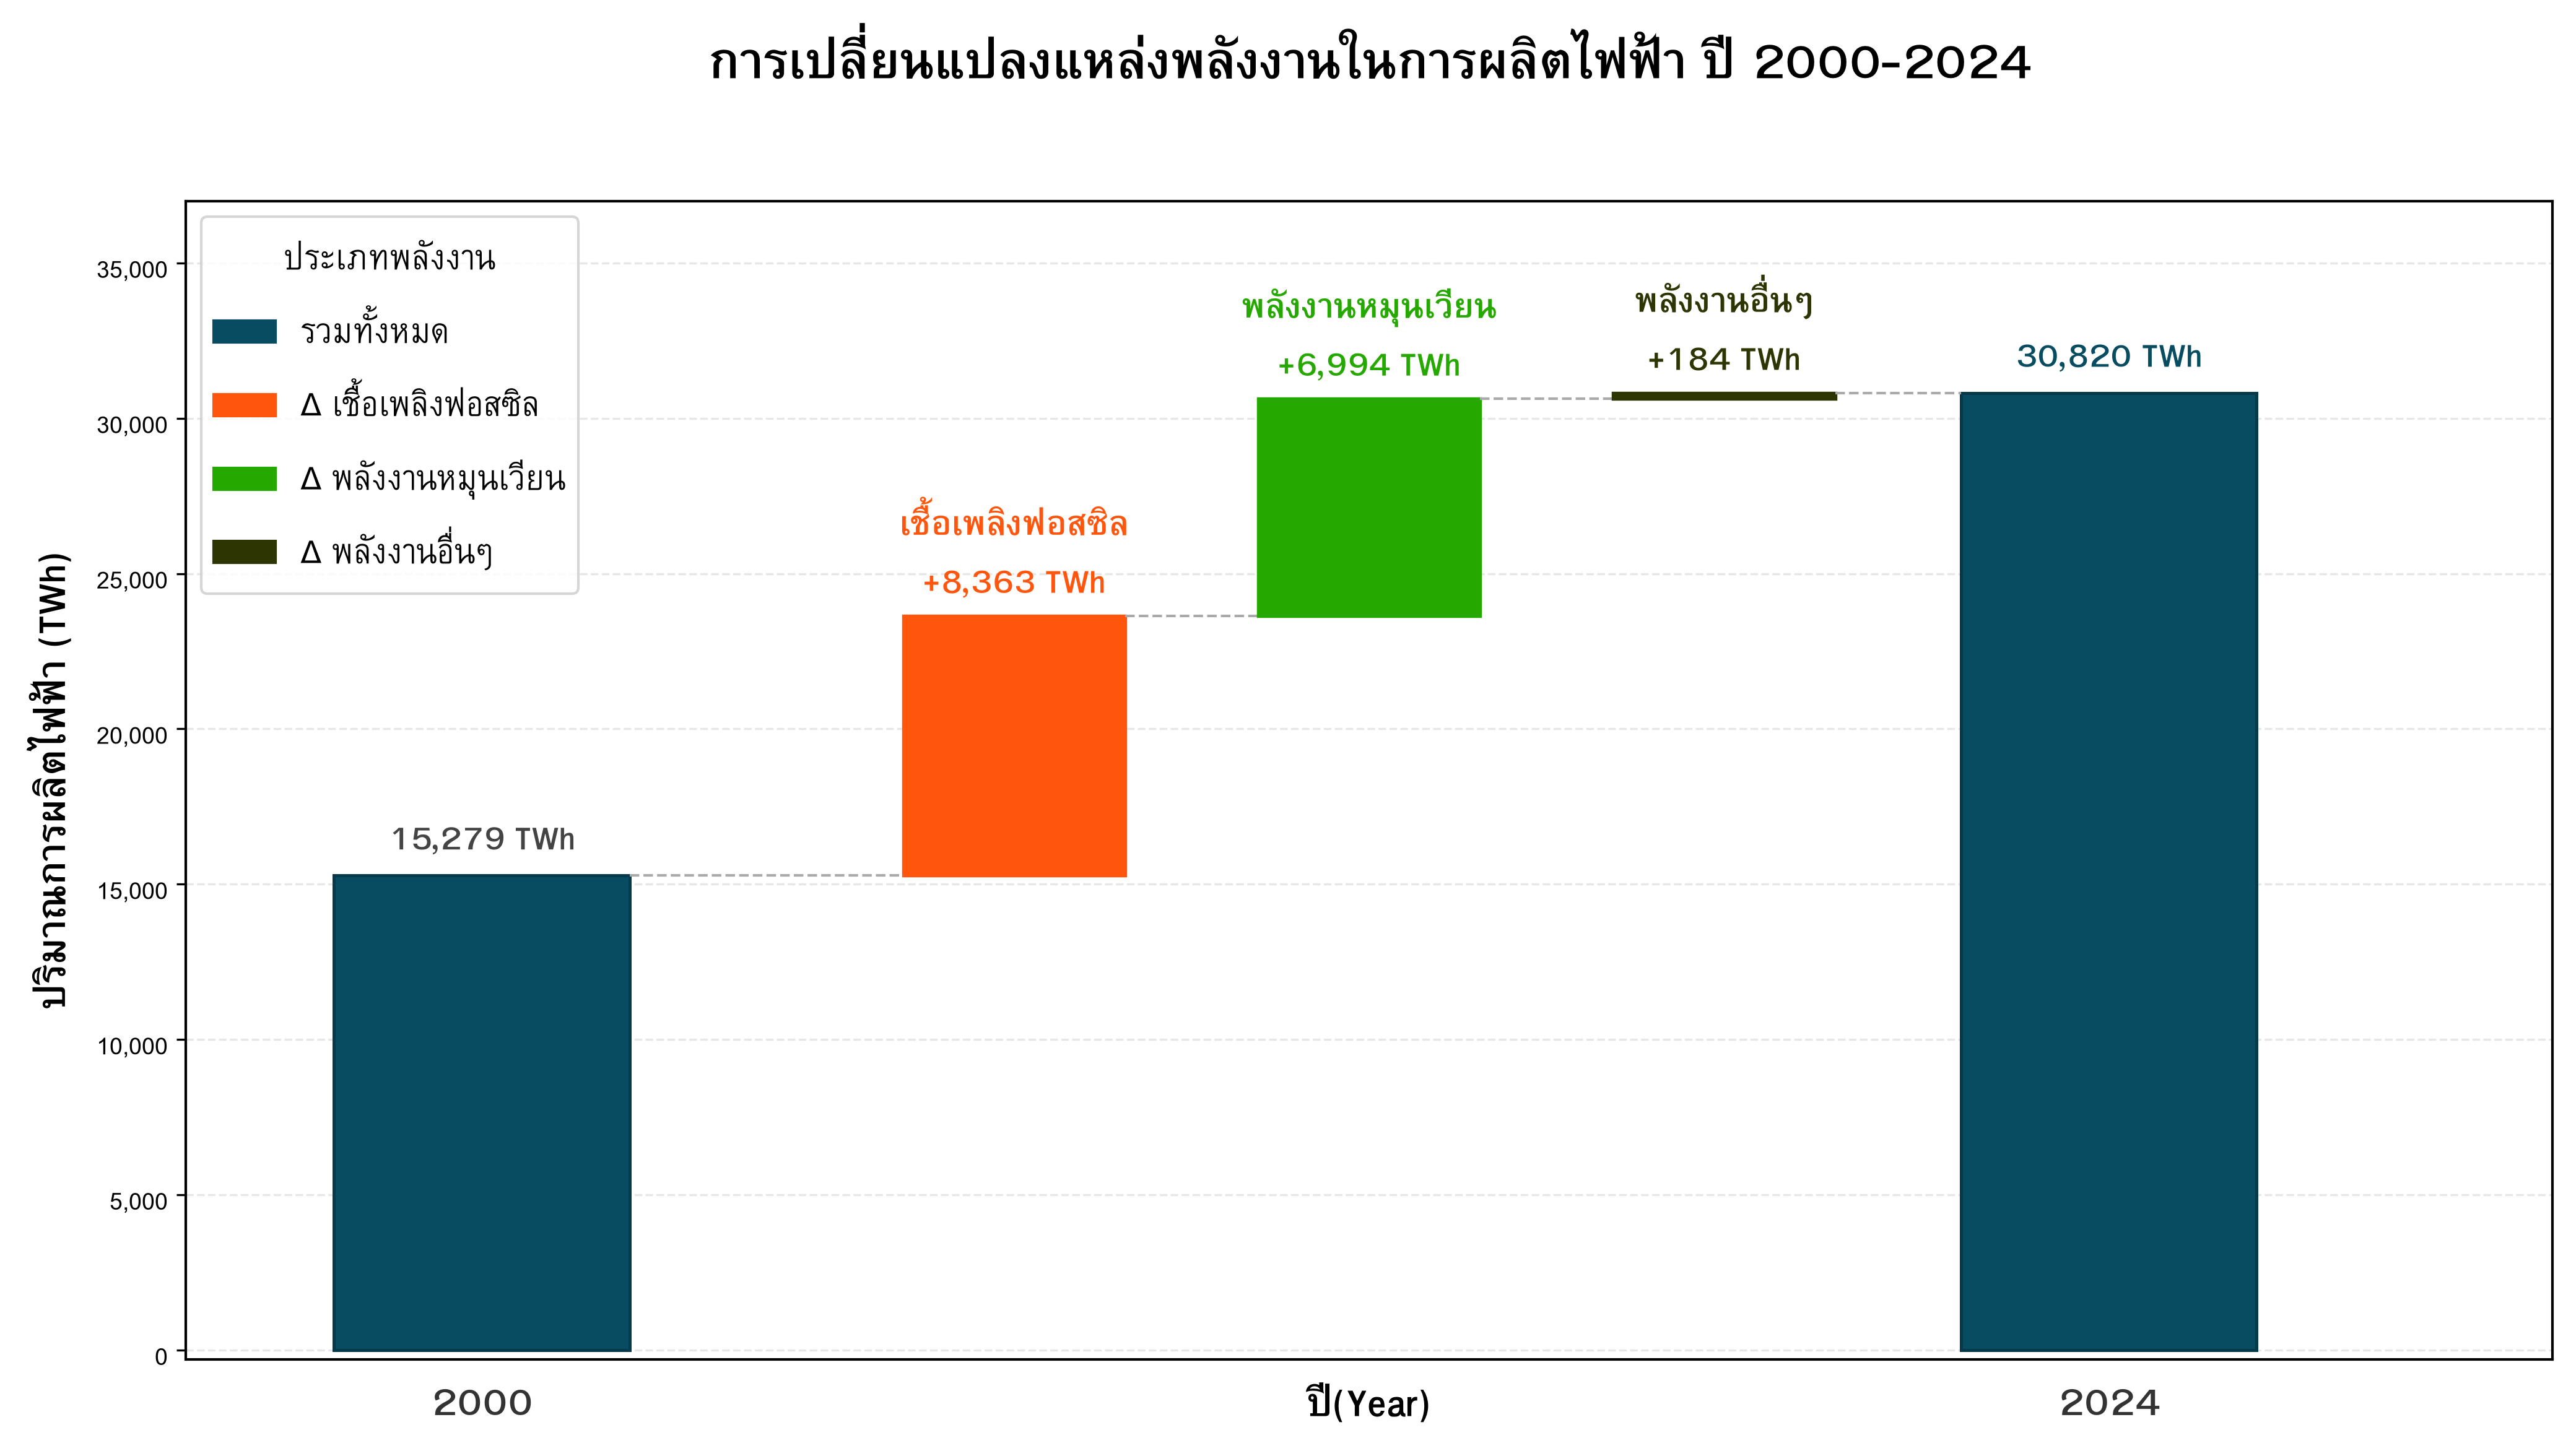

In [170]:
world = df.groupby('year').agg(
    coal     = ('coal_electricity',            'sum'),
    gas      = ('gas_electricity',             'sum'),
    oil      = ('oil_electricity',             'sum'),
    solar    = ('solar_electricity',           'sum'),
    wind     = ('wind_electricity',            'sum'),
    hydro    = ('hydro_electricity',           'sum'),
    other_re = ('other_renewable_electricity', 'sum'),
    Other    = ('nuclear_electricity', 'sum'),  # แสดงเป็นพลังงานอื่นๆ ตามที่กำหนด
).reset_index()

world['Fossil']  = world['coal'] + world['gas'] + world['oil']
world['RE']      = world['solar'] + world['wind'] + world['hydro'] + world['other_re']

# ── ส่วนที่ 2: คำนวณค่า 2000, 2024 และ Δ ────────────────────
y2000 = world[world.year == 2000].iloc[0]
y2024 = world[world.year == 2024].iloc[0]

sources    = ['Fossil', 'RE', 'Other']
val2000    = {s: y2000[s] for s in sources}
val2024    = {s: y2024[s] for s in sources}
delta      = {s: val2024[s] - val2000[s] for s in sources}
total_2000 = sum(val2000.values())
total_2024 = sum(val2024.values())
th_name = {
    'Fossil':  'เชื้อเพลิงฟอสซิล',
    'RE':      'พลังงานหมุนเวียน',
    'Other':   'พลังงานอื่นๆ',
}

# ── ส่วนที่ 3: กำหนดสี ───────────────────────────────────────
C_BAR      = '#084C61'   # แท่งรวมทั้งหมด
C_BAR_EDGE = '#063A4A'
C_src  = {'Fossil': '#FF550D', 'RE': '#25A800', 'Other': '#2D3502'}   # สีแท่ง Δ
C_dark = {'Fossil': '#FF550D', 'RE': '#25A800', 'Other': '#2D3502'}   # สีขอบแท่ง / ตัวอักษร label

# ── ส่วนที่ 4: ตำแหน่งแกน X ──────────────────────────────────
x_left   = 1.0
x_right  = 6.5
bw       = 1.0    # ความกว้างแท่งหลัก
dw       = 0.75   # ความกว้างแท่ง Δ
x_deltas = {'Fossil': 2.8, 'RE': 4.0, 'Other': 5.2}

# ── ส่วนที่ 5: วาดกราฟ ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 8), facecolor='white', dpi=300)
ax.set_facecolor('white')
fig.subplots_adjust(bottom=0.12)

# แท่งรวม 2000 & 2024 (สีเดียว ไม่แยก source)
ax.bar(x_left,  total_2000, width=bw, color=C_BAR,
       edgecolor=C_BAR_EDGE, linewidth=1.2, zorder=3)
ax.bar(x_right, total_2024, width=bw, color=C_BAR,
       edgecolor=C_BAR_EDGE, linewidth=1.2, zorder=3)

# label ยอดรวม
ax.text(x_left,  total_2000 + 250, f'{total_2000:,.0f} TWh',
        ha='center', va='bottom', fontsize=12, fontweight='bold', color='#444')
ax.text(x_right, total_2024 + 250, f'{total_2024:,.0f} TWh',
        ha='center', va='bottom', fontsize=12, fontweight='bold', color=C_BAR)

# label ปี
ax.text(x_left,  -600, '2000', ha='center', va='top',
        fontsize=14, fontweight='bold', color='#333')
ax.text(x_right, -600, '2024', ha='center', va='top',
        fontsize=14, fontweight='bold', color='#333')

# ── ส่วนที่ 6: Waterfall Δ bars (cascade) ────────────────────
# แต่ละแท่งเริ่มต้นที่ปลายของแท่งก่อนหน้า
# เริ่มจากยอดรวมปี 2000
running_bottom = total_2000

for s in sources:
    d  = delta[s]
    xd = x_deltas[s]

    if d >= 0:
        bar_bot = running_bottom
        bar_top = running_bottom + d
    else:
        bar_bot = running_bottom + d
        bar_top = running_bottom

    # วาดแท่ง Δ
    ax.bar(xd, abs(d), bottom=bar_bot, width=dw,
           color=C_src[s], alpha=1.0,
           edgecolor=C_dark[s], linewidth=1.3, zorder=4)

    # label บนแท่ง
    sign = '+' if d >= 0 else ''
    ax.text(xd, bar_top + 150,
            f'{th_name[s]}\n{sign}{d:,.0f} TWh',
            ha='center', va='bottom', fontsize=12,
            fontweight='bold', color=C_dark[s], zorder=6)

    # เส้นประเชื่อมแท่งถัดไป (ที่ระดับ bar_top)
    next_sources = sources[sources.index(s)+1:]
    if next_sources:
        xd_next = x_deltas[next_sources[0]]
        ax.plot([xd + dw/2, xd_next - dw/2],
                [running_bottom + d, running_bottom + d],
                color='#aaaaaa', lw=1.0, ls='--', zorder=4)

    running_bottom += d  # อัปเดตจุดเริ่มต้นของแท่งถัดไป

# เส้นประ: ยอด 2000 → Fossil
ax.plot([x_left + bw/2, x_deltas['Fossil'] - dw/2],
        [total_2000, total_2000],
        color='#aaaaaa', lw=1.0, ls='--', zorder=4)

ax.plot([x_deltas['Other'] + dw/2, x_right - bw/2],
        [total_2024, total_2024],
        color='#aaaaaa', lw=1.0, ls='--', zorder=4)

# ── ส่วนที่ 7: ตกแต่ง Axes ───────────────────────────────────
y_max = total_2024 * 1.20
ax.set_xlim(0, x_right + bw + 0.5)
ax.set_ylim(-300, y_max)
ax.set_yticks(np.arange(0, y_max, 5000))
ax.set_yticklabels([f'{int(v):,}' for v in np.arange(0, y_max, 5000)], fontsize=9)
ax.set_ylabel('ปริมาณการผลิตไฟฟ้า (TWh)', fontsize=14, fontweight='bold')
ax.set_xlabel('ปี(Year)', fontsize=14, fontweight='bold')
ax.set_title('การเปลี่ยนแปลงแหล่งพลังงานในการผลิตไฟฟ้า ปี 2000-2024\n',
    fontsize=18,fontweight='bold',pad=14 )
ax.set_xticks([])
ax.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)
for sp in ax.spines.values():
    sp.set_visible(True)
    sp.set_color('#000000')
    sp.set_linewidth(1.0)

## ── ส่วนที่ 8: Legend ─────────────────────────────────────────
handles = [mpatches.Patch(color=C_BAR, label='รวมทั้งหมด')]
handles += [mpatches.Patch(color=C_src[s], label=f'$\\Delta$ {th_name[s]}') for s in sources]
ax.legend(handles=handles, loc='upper left', fontsize=12,
          framealpha=0.8, title='ประเภทพลังงาน', title_fontsize=12)

plt.tight_layout()
plt.savefig('figure3.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

#Table 1

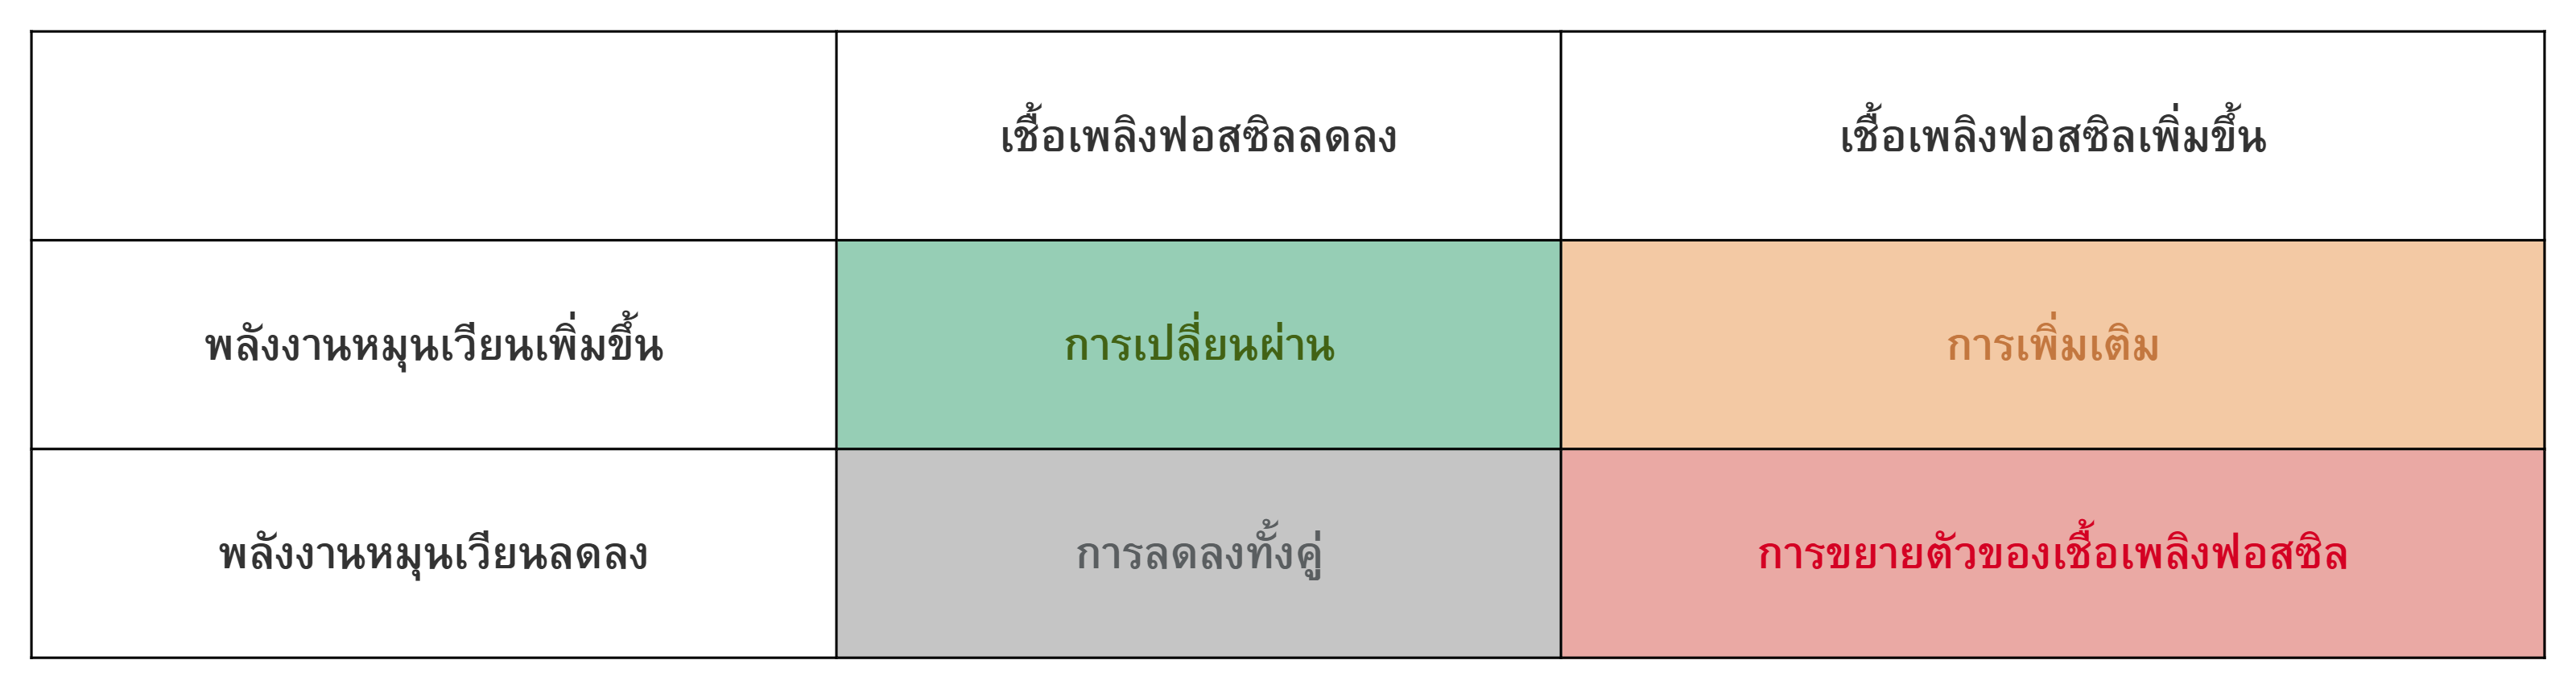

In [171]:
from pathlib import Path
import sys
from html import escape
from IPython.display import Image, display

# 1. เตรียมตัวช่วยส่งออกภาพ
project_dir = Path.cwd()
if not (project_dir / "export_table_image.py").is_file():
    project_dir = project_dir / "dads 5001"
if str(project_dir) not in sys.path:
    sys.path.insert(0, str(project_dir))
from export_table_image import export_table

# 2. ข้อมูลตาราง: หัวแถว และข้อความในสองคอลัมน์
column_headers = ["เชื้อเพลิงฟอสซิลลดลง", "เชื้อเพลิงฟอสซิลเพิ่มขึ้น"]
rows = [
    ("พลังงานหมุนเวียนเพิ่มขึ้น", ["การเปลี่ยนผ่าน", "การเพิ่มเติม"]),
    ("พลังงานหมุนเวียนลดลง", ["การลดลงทั้งคู่", "การขยายตัวของเชื้อเพลิงฟอสซิล"]),
]

# 3. สีตัวอักษรและพื้นหลังของแต่ละประเภท
colors = {
    "การเปลี่ยนผ่าน": {"text": "#426214", "background": "#2E9E6B"},
    "การเพิ่มเติม": {"text": "#C3773F", "background": "#E8934A"},
    "การลดลงทั้งคู่": {"text": "#5A5E60", "background": "#8C8C8C"},
    "การขยายตัวของเชื้อเพลิงฟอสซิล": {"text": "#D40123", "background": "#D6534A"},
}
background_opacity = 50  # เปอร์เซ็นต์ความทึบของสีพื้นหลัง

# 4. รูปแบบตาราง (ไม่มีหัวข้อหรือ caption)
table_css = """
<style>
#table1 {
    border-collapse: collapse;
    font-family: Garuda, sans-serif;
    font-size: 16px;
    width: 1000px;
    max-width: 100%;
}
#table1 th, #table1 td {
    border: 1px solid #000000;
    padding: 26px 28px;
    text-align: center;
    font-weight: bold;
}
#table1 th {
    background: white;
    color: #333333;
}
#table1 tbody th { white-space: nowrap; }
#table1 td {
    min-width: 150px;
    height: 20px;
}
</style>
"""

# 5. สร้างหัวแถวและช่องข้อมูลจากรายการด้านบน
header_html = "<th></th>" + "".join(
    f"<th>{escape(header)}</th>" for header in column_headers
)
body_rows = []
for row_label, categories in rows:
    cells = [f"<th>{escape(row_label)}</th>"]
    for category in categories:
        color = colors[category]
        style = (
            f"color: {color['text']}; "
            f"background-color: color-mix(in srgb, "
            f"{color['background']} {background_opacity}%, transparent);"
        )
        cells.append(f'<td style="{style}">{escape(category)}</td>')
    body_rows.append("<tr>" + "".join(cells) + "</tr>")

table1_html = (
    table_css
    + '<table id="table1">'
    + f"<thead><tr>{header_html}</tr></thead>"
    + "<tbody>" + "".join(body_rows) + "</tbody>"
    + "</table>"
)

# 6. บันทึก PNG และแสดงรูปใน Notebook
table1_path = export_table(table1_html, "table1", width=1100)
display(Image(filename=str(table1_path), width=1000))


#Table2

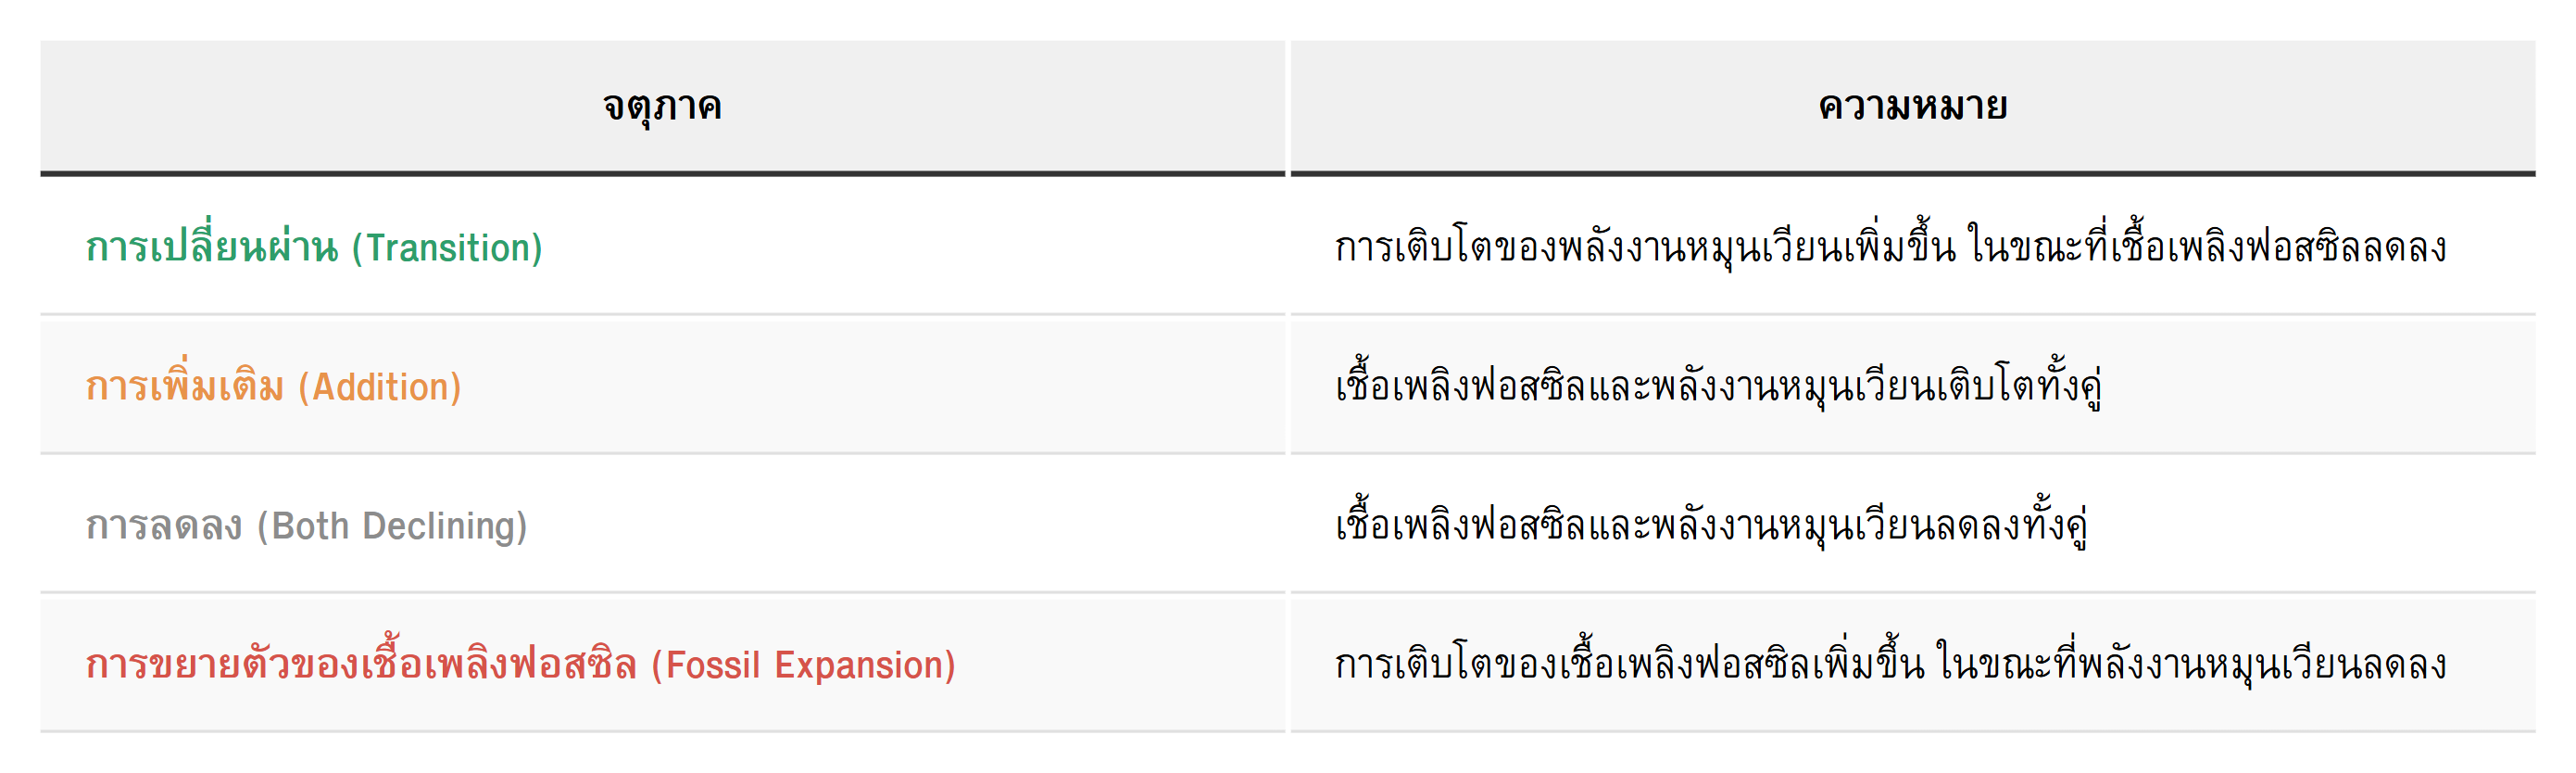

In [172]:
from pathlib import Path
import sys
from IPython.display import Image, display
import pandas as pd
_table_dir = next(p for p in [Path.cwd(), Path.cwd() / 'dads 5001']
                  if (p / 'export_table_image.py').is_file())
if str(_table_dir) not in sys.path:
    sys.path.insert(0, str(_table_dir))
from export_table_image import export_table

# ── ข้อมูลตาราง ───────────────────────────────────────────────
data = {
    'จตุภาค': [
        'การเปลี่ยนผ่าน (Transition)',
        'การเพิ่มเติม (Addition)',
        'การลดลง (Both Declining)',
        'การขยายตัวของเชื้อเพลิงฟอสซิล (Fossil Expansion)',
    ],
    'ความหมาย': [
        'การเติบโตของพลังงานหมุนเวียนเพิ่มขึ้น ในขณะที่เชื้อเพลิงฟอสซิลลดลง',
        'เชื้อเพลิงฟอสซิลและพลังงานหมุนเวียนเติบโตทั้งคู่',
        'เชื้อเพลิงฟอสซิลและพลังงานหมุนเวียนลดลงทั้งคู่',
        'การเติบโตของเชื้อเพลิงฟอสซิลเพิ่มขึ้น ในขณะที่พลังงานหมุนเวียนลดลง',
    ],
}

df_table = pd.DataFrame(data)

# ── สีแต่ละแถว ────────────────────────────────────────────────
ROW_COLORS = {
    0: '#2E9E6B',
    1: '#E8934A',
    2: "#8C8C8C",
    3: '#D6534A',

}

styled = (
    df_table.style
    .apply(lambda row: [
        f'color: {ROW_COLORS[row.name]}; font-weight: bold',
        '',
    ], axis=1)
    .set_properties(**{
        'font-family': 'Garuda',
        'font-size': '13px',
        'padding': '10px 15px',
        'text-align': 'left',
        'border-bottom': '1px solid #e0e0e0',
    })
    .set_table_styles([
        {'selector': 'thead th', 'props': [
            ('background-color', '#f0f0f0'),
            ('font-weight', 'bold'),
            ('font-size', '13px'),
            ('padding', '10px 15px'),
            ('border-bottom', '2px solid #333'),
            ('text-align', 'center'),    
            ('word-wrap', 'break-word'), 
        ]},
        {'selector': 'tbody tr:nth-child(even)', 'props': [
            ('background-color', '#f9f9f9'),
        ]},
        {'selector': 'tbody tr:hover', 'props': [
            ('background-color', '#f0f0f0'),
        ]},
        {'selector': 'caption', 'props': [
            ('font-weight', 'bold'),
            ('font-size', '14px'),
            ('padding', '10px 0'),
            ('text-align', 'left'),
            ('color', '#222'),
        ]},
        {'selector': 'th:nth-child(1), td:nth-child(1)', 'props': [
            ('width', '400px'), ('min-width', '220px'),
        ]},
        {'selector': 'th:nth-child(2), td:nth-child(2)', 'props': [
            ('width', '400px'), ('min-width', '400px'),
        ]},
    ])
    .hide(axis='index')
)

table2_path = export_table(styled.to_html(), 'table2', width=1100)
display(Image(filename=str(table2_path), width=900))

#Figure 4

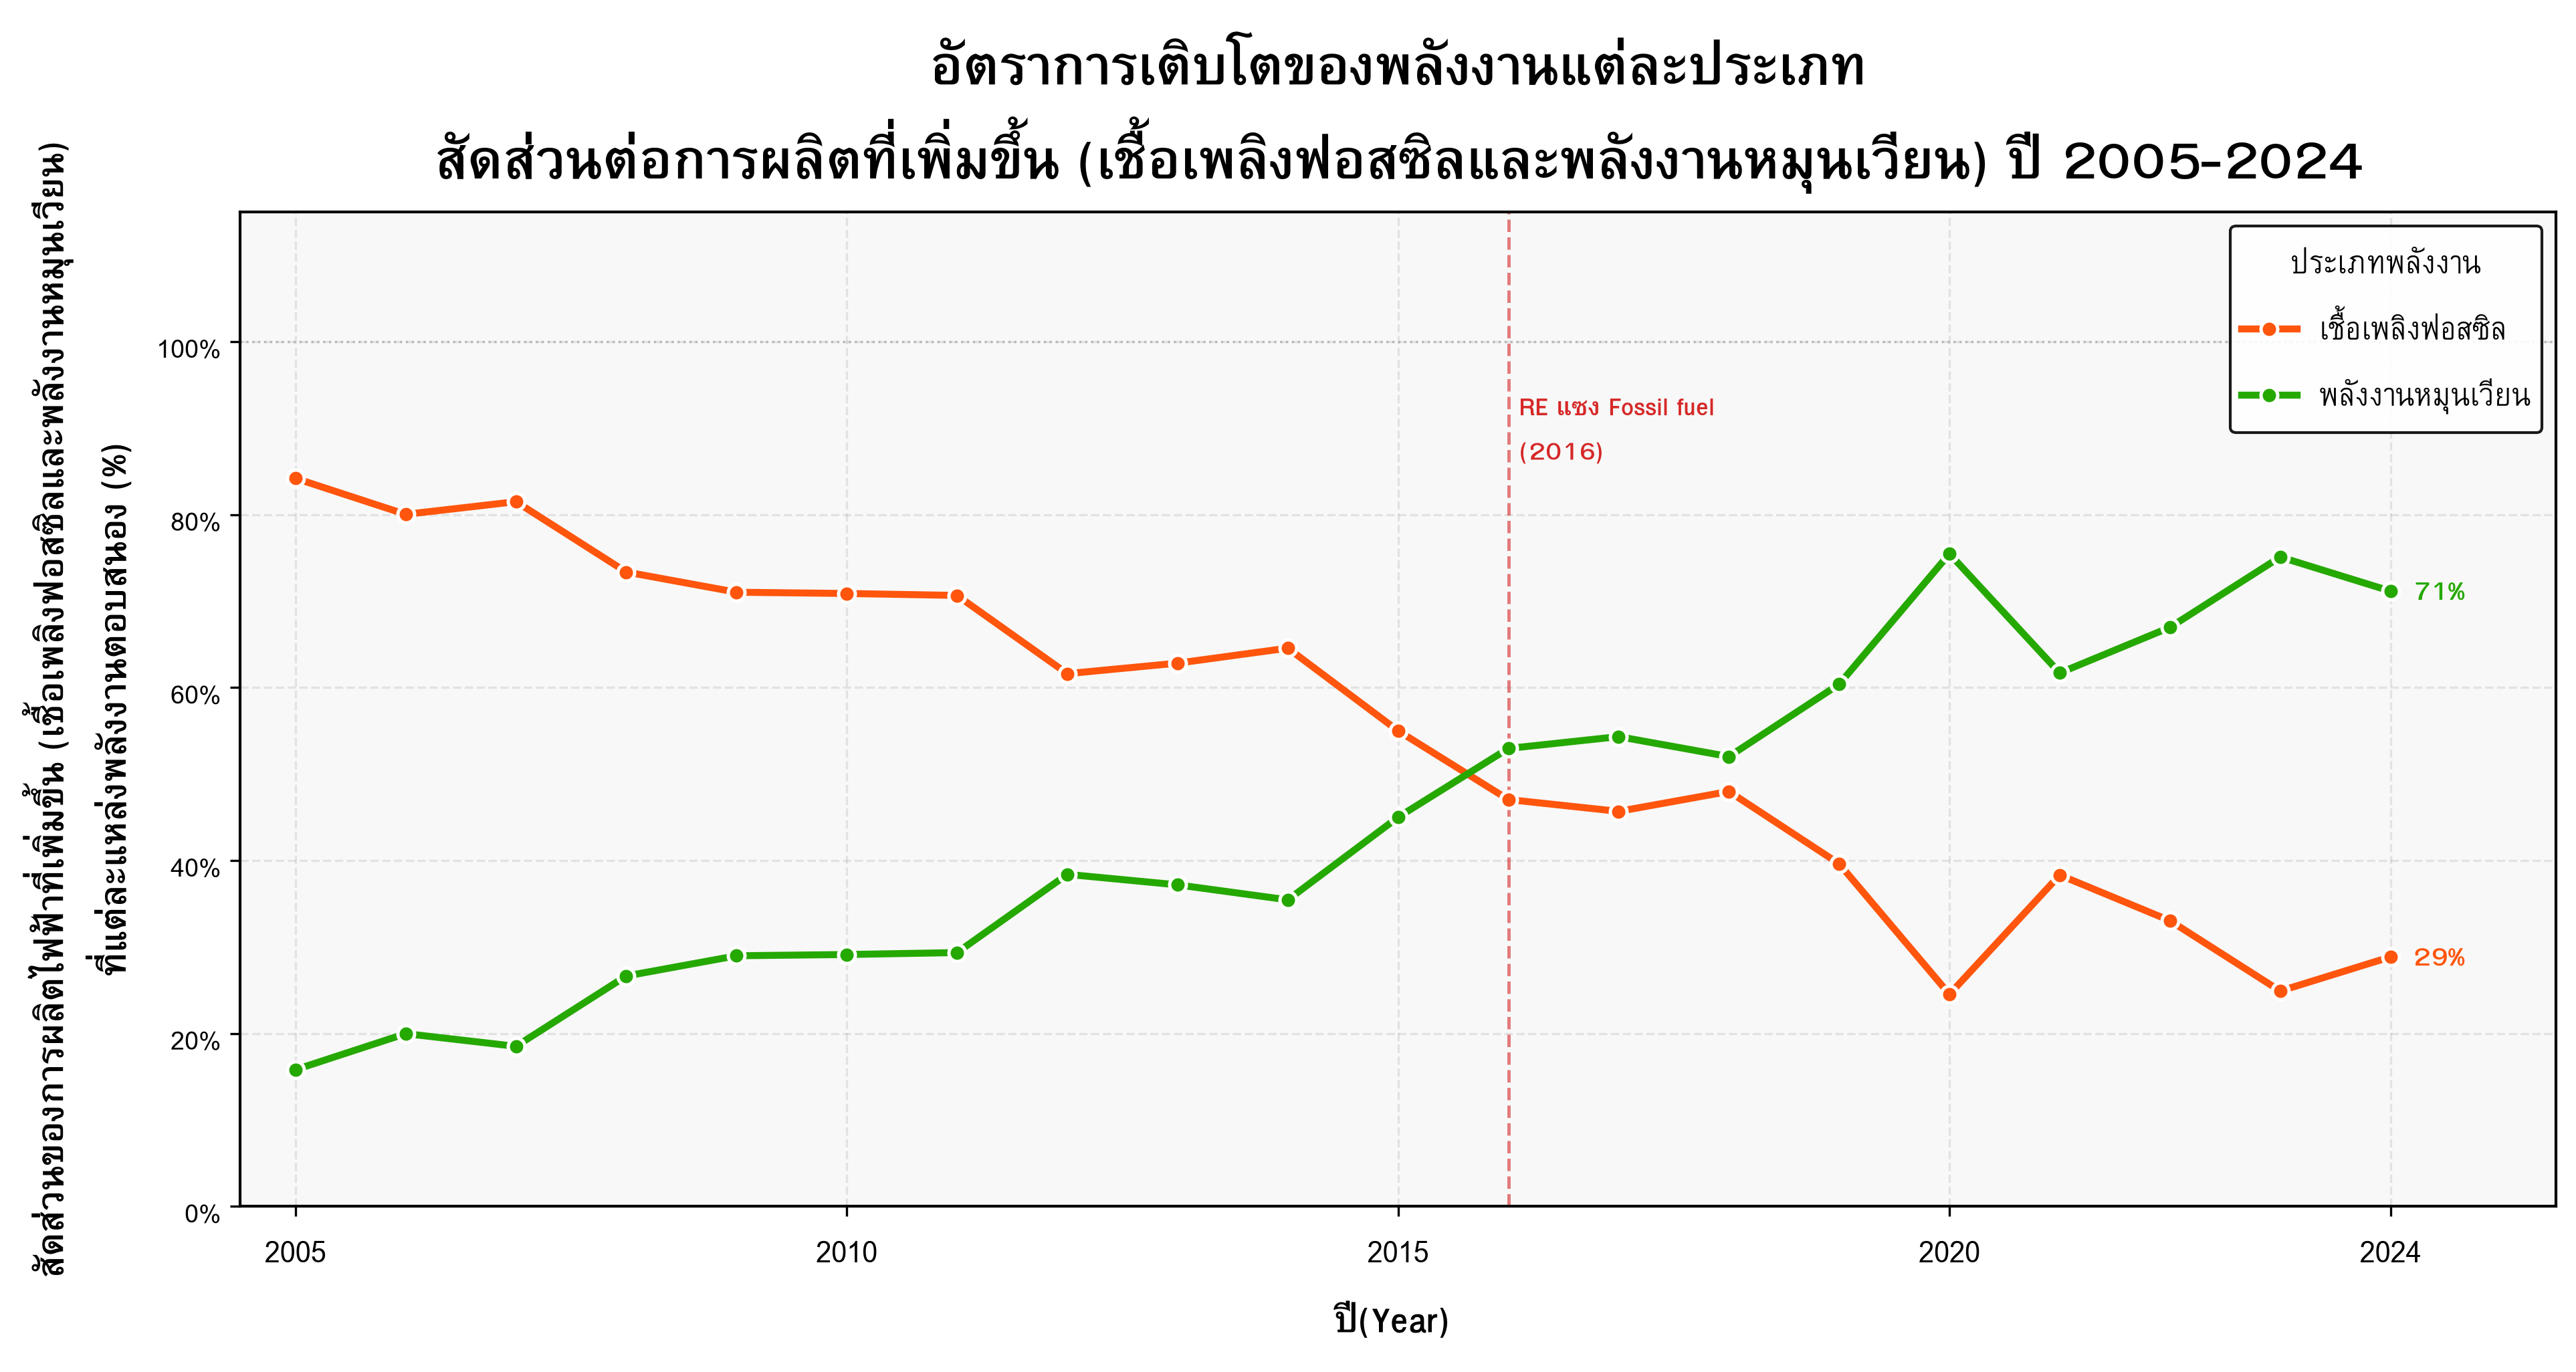

In [173]:

world = df.groupby('year').agg(
    coal     = ('coal_electricity',            'sum'),
    gas      = ('gas_electricity',             'sum'),
    oil      = ('oil_electricity',             'sum'),
    solar    = ('solar_electricity',           'sum'),
    wind     = ('wind_electricity',            'sum'),
    hydro    = ('hydro_electricity',           'sum'),
    other_re = ('other_renewable_electricity', 'sum'),
).reset_index()

world['Fossil']  = world['coal'] + world['gas'] + world['oil']
world['RE']      = world['solar'] + world['wind'] + world['hydro'] + world['other_re']
world['Total']   = world['Fossil'] + world['RE']

world = world[world['year'].between(2000, 2024)].reset_index(drop=True)
world = world.set_index('year')

# ── คำนวณ 5-year rolling share ───────────────────────────────
results = []
for y in range(2005, 2025):
    if y-5 not in world.index or y not in world.index:
        continue
    d_total   = world.loc[y, 'Total']   - world.loc[y-5, 'Total']
    d_fossil  = world.loc[y, 'Fossil']  - world.loc[y-5, 'Fossil']
    d_re      = world.loc[y, 'RE']      - world.loc[y-5, 'RE']
    if d_total == 0:
        continue
    results.append({
        'year':    y,
        'Fossil':  d_fossil  / d_total * 100,
        'RE':      d_re      / d_total * 100,
    })

roll = pd.DataFrame(results)

# ── สี ────────────────────────────────────────────────────────
C_FOSSIL  = '#FF550D'   # ชุดสีเดียวกับ Figure 3
C_RE      = '#25A800'

# ── Figure ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 7), facecolor='white', dpi=300)
ax.set_facecolor('#f8f8f8')

# เส้น reference
ax.axhline(100, color='#bbbbbb', lw=0.8, ls=':', zorder=1)
ax.axhline(0,   color='#888888', lw=1.0, ls='-', zorder=1)

# วาด 2 เส้น
for col, color, label in [
    ('Fossil',  C_FOSSIL,  'เชื้อเพลิงฟอสซิล'),
    ('RE',      C_RE,      'พลังงานหมุนเวียน'),
]:
    ax.plot(roll['year'], roll[col],
            color=color, lw=2.5, marker='o',
            markersize=6, markerfacecolor=color,
            markeredgecolor='white', markeredgewidth=1.2,
            label=label, zorder=4)

    # label ปลายเส้น
    last = roll.iloc[-1]
    ax.text(last['year'] + 0.2, last[col],
            f"{last[col]:.0f}%",
            fontsize=9, color=color, fontweight='bold',
            va='center', zorder=5)

# จุดที่ RE แซง Fossil
cross_year = None
for i in range(len(roll)-1):
    if roll.iloc[i]['RE'] < roll.iloc[i]['Fossil'] and \
       roll.iloc[i+1]['RE'] >= roll.iloc[i+1]['Fossil']:
        cross_year = roll.iloc[i+1]['year']
        break

if cross_year:
    ax.axvline(cross_year, color='#D62828', lw=1.2,
               ls='--', alpha=0.6, zorder=2)
    ax.text(cross_year + 0.1, 95,
            f'RE แซง Fossil fuel\n({cross_year:.0f})',
            fontsize=8.5, color='#D62828',
            va='top', fontweight='bold')

# ── Axes ──────────────────────────────────────────────────────
ax.set_xlim(2004.5, 2025.5)
ax.set_ylim(0, 115)

# แกน x ทีละ 5 ปี
ax.set_xticks([2005, 2010, 2015, 2020, 2024])
ax.set_xticklabels(['2005', '2010', '2015', '2020', '2024'], fontsize=10)

ax.set_yticks(range(0, 120, 20))
ax.set_yticklabels([f'{v}%' for v in range(0, 120, 20)], fontsize=9)

ax.set_xlabel('ปี(Year) ', fontsize=12,fontweight='bold')
ax.set_ylabel('สัดส่วนของการผลิตไฟฟ้าที่เพิ่มขึ้น (เชื้อเพลิงฟอสซิลและพลังงานหมุนเวียน)\nที่แต่ละแหล่งพลังงานตอบสนอง (%)', fontsize=12,fontweight='bold')
ax.set_title('อัตราการเติบโตของพลังงานแต่ละประเภท\n'
             'สัดส่วนต่อการผลิตที่เพิ่มขึ้น (เชื้อเพลิงฟอสซิลและพลังงานหมุนเวียน) ปี 2005-2024',
             fontsize=18,fontweight='bold', pad=12)

ax.grid(axis='both', linestyle='--', alpha=0.3, zorder=1)
for sp in ax.spines.values():
    sp.set_visible(True)
    sp.set_color('#000000')
    sp.set_linewidth(1.0)
# Legend
ax.legend(loc='upper right', fontsize=10, framealpha=0.9,
          edgecolor="#010101",
          title='ประเภทพลังงาน', title_fontsize=10)

plt.tight_layout()
plt.savefig('figure4.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

#figure 5

จำนวนประเทศทั้งหมด: 194
quadrant
การเพิ่มเติม                     133
การเปลี่ยนผ่าน                    53
การขยายตัวของเชื้อเพลิงฟอสซิล      8
Name: count, dtype: int64
saved


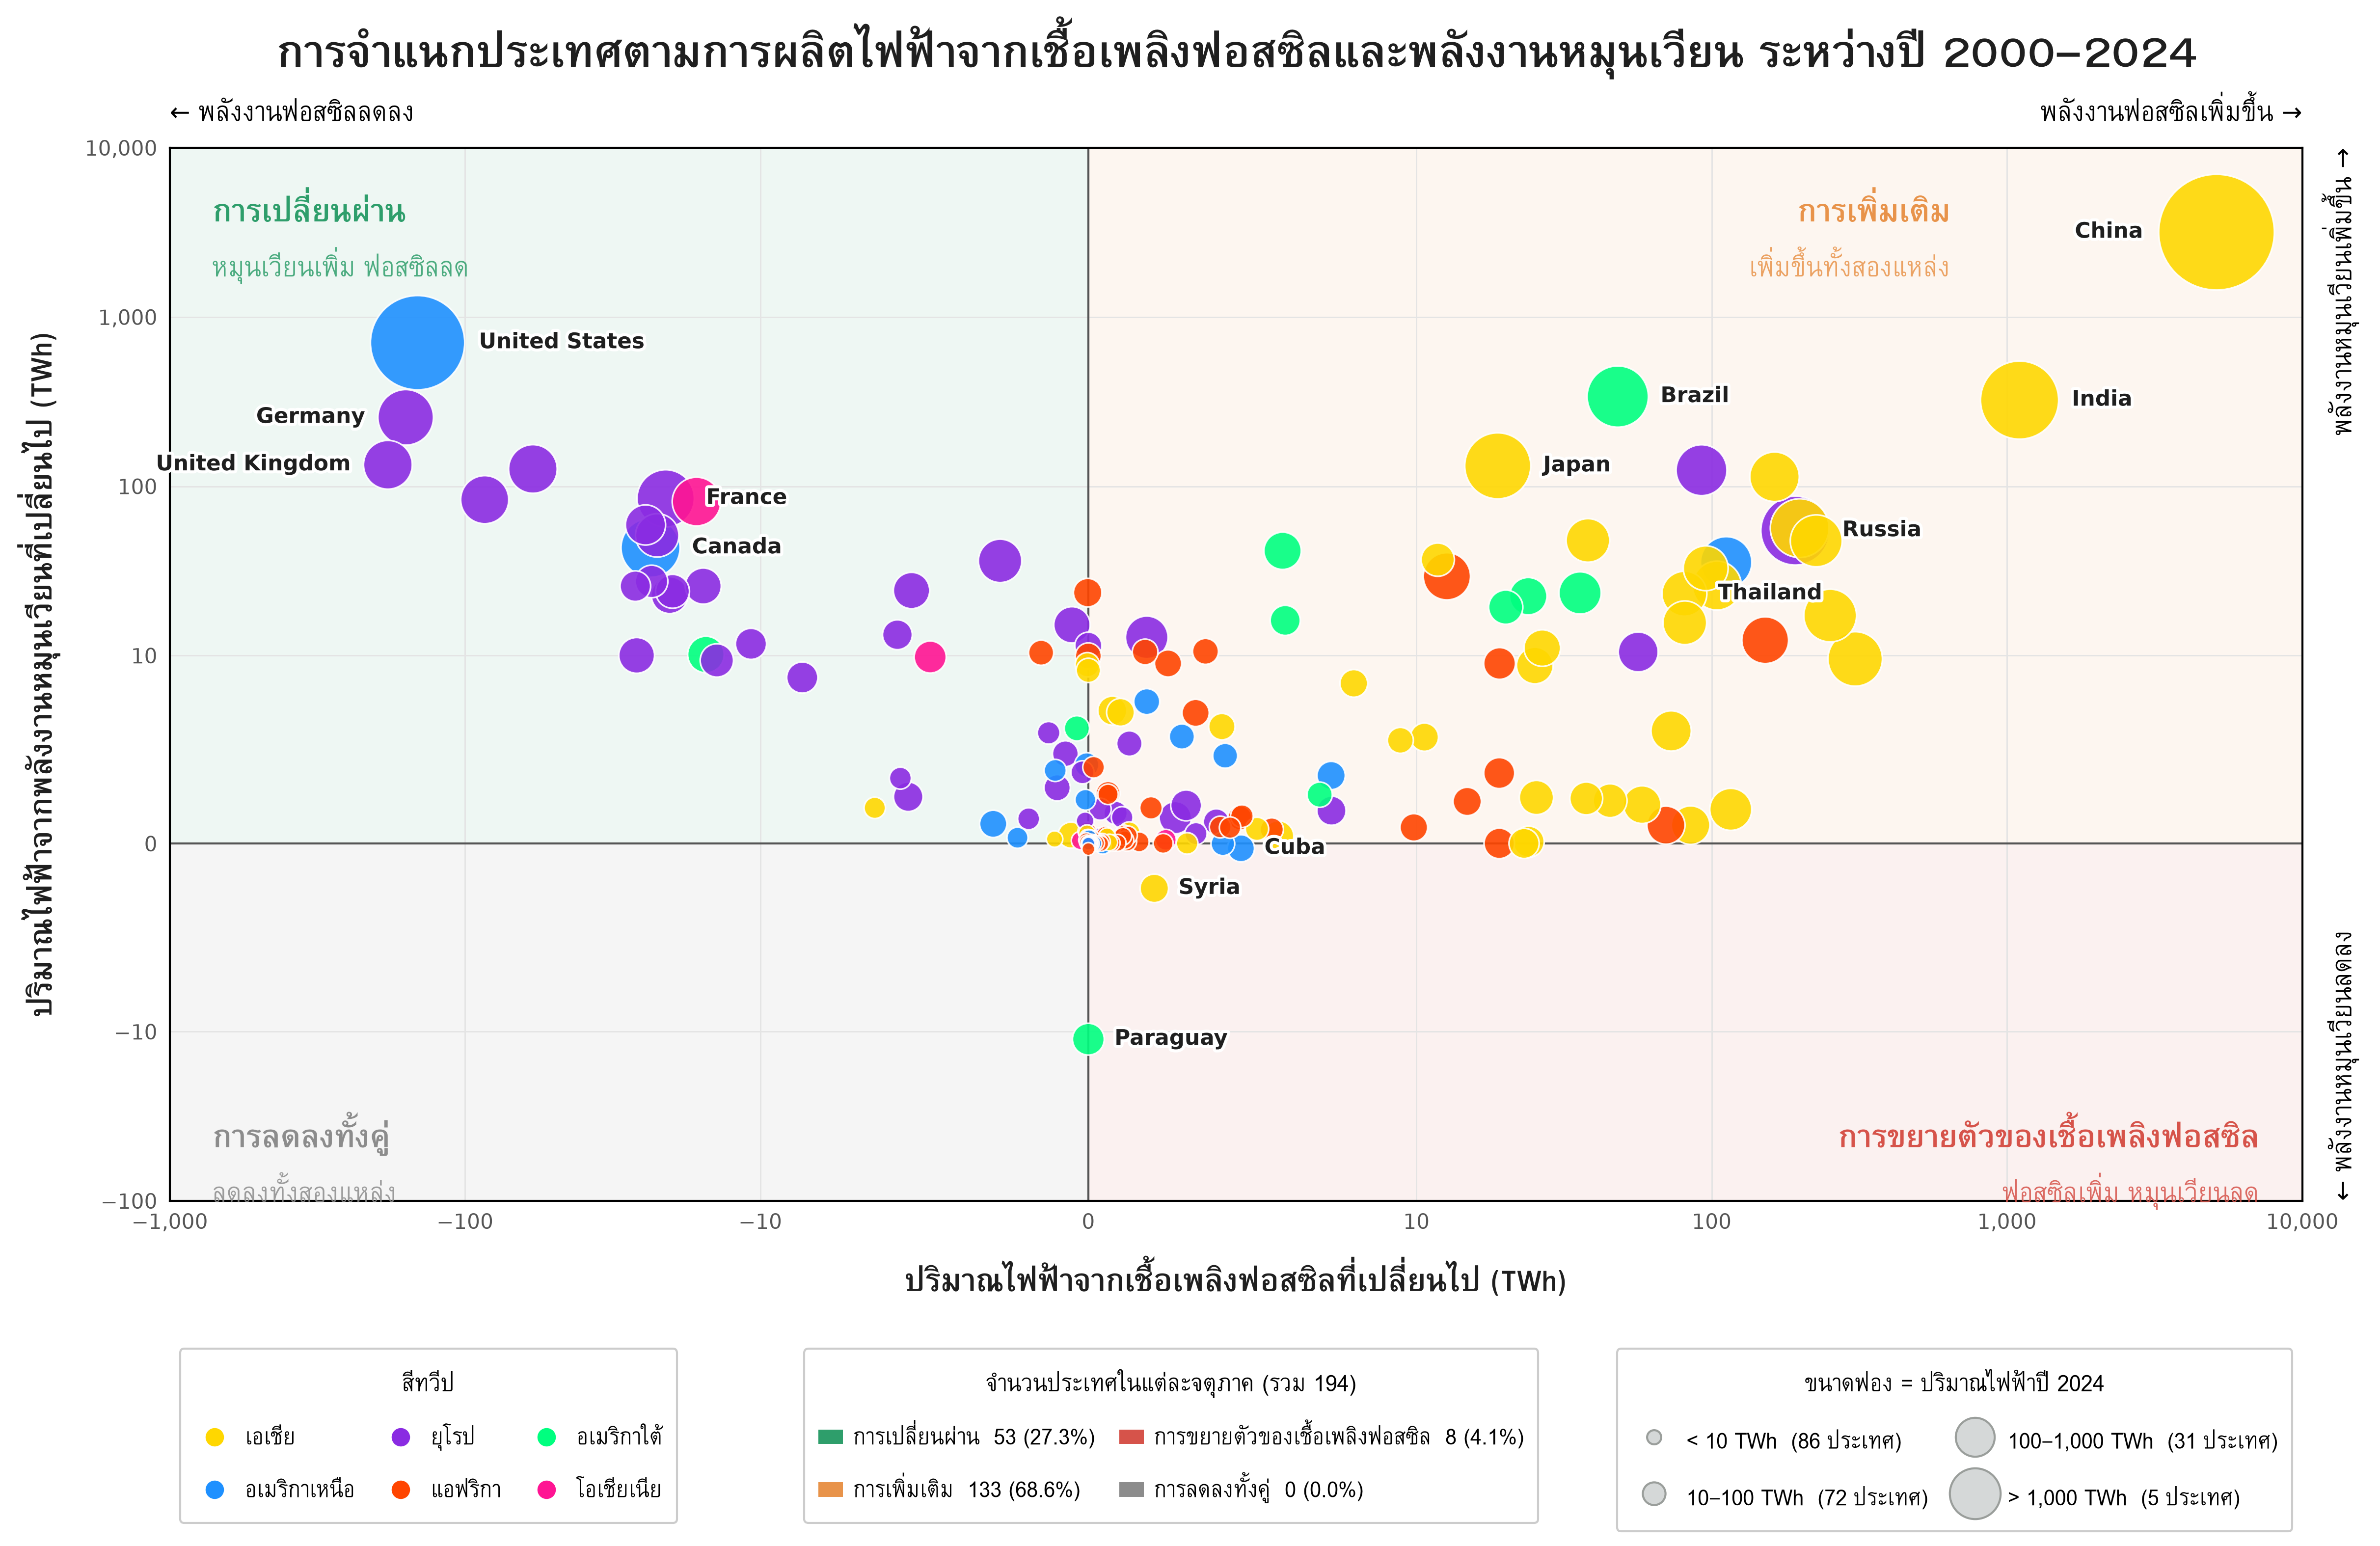

In [174]:
df = df.copy()

df['fossil'] = df['coal_electricity'] + df['gas_electricity'] + df['oil_electricity']
df['renewables'] = (df['hydro_electricity'] + df['solar_electricity']
                     + df['wind_electricity'] + df['other_renewable_electricity'])

p0 = df[df.year == 2000][['country', 'iso_code', 'continent', 'fossil', 'renewables', 'electricity_generation']] \
        .rename(columns={'fossil': 'fossil_2000', 'renewables': 'ren_2000'})
p1 = df[df.year == 2024][['country', 'fossil', 'renewables', 'electricity_generation']] \
        .rename(columns={'fossil': 'fossil_2024', 'renewables': 'ren_2024',
                          'electricity_generation': 'gen_2024'})

m = p0.merge(p1, on='country').dropna(subset=['electricity_generation', 'gen_2024'])

m['delta_fossil'] = m['fossil_2024'] - m['fossil_2000']
m['delta_ren'] = m['ren_2024'] - m['ren_2000']

# ---------- 2. จัด 4 quadrant ----------
def quadrant(row):
    if row['delta_fossil'] >= 0 and row['delta_ren'] >= 0: return 'การเพิ่มเติม'          # top-right
    if row['delta_fossil'] < 0 and row['delta_ren'] >= 0: return 'การเปลี่ยนผ่าน'         # top-left
    if row['delta_fossil'] >= 0 and row['delta_ren'] < 0: return 'การขยายตัวของเชื้อเพลิงฟอสซิล'   # bottom-right
    return 'การลดลงทั้งคู่'

m['quadrant'] = m.apply(quadrant, axis=1)

import matplotlib.transforms as mtransforms

# ---------- 3. สีตามทวีป (โทนตามรูปต้นแบบ) ----------
CONTINENT_COLORS = {
    'Asia':          '#FFD700',
    'North America': '#1e90ff',
    'Europe':        '#8A2BE2',
    'Africa':        '#FF4500',
    'South America': '#00FF7F',
    'Oceania':       '#FF1493',
}
CONTINENT_TH = {
    'Asia': 'เอเชีย', 'Africa': 'แอฟริกา', 'North America': 'อเมริกาเหนือ',
    'South America': 'อเมริกาใต้', 'Europe': 'ยุโรป', 'Oceania': 'โอเชียเนีย',
}
m['color'] = m['continent'].map(CONTINENT_COLORS)

# ---------- 4. ขนาด bubble จาก electricity_generation (gen_2024) ----------
size_raw = np.sqrt(m['gen_2024'].clip(lower=0.01))
size_min, size_max = 40, 3200
m['bubble_size'] = np.interp(size_raw, (size_raw.min(), size_raw.max()), (size_min, size_max))

# ---------- 5. เลือกป้ายชื่อ: 5 ประเทศใหญ่สุดต่อ quadrant (เฉพาะ ≥ 10 TWh) + ไทย ----------
LABEL_TOP_N   = 5
LABEL_MIN_GEN = 10
cand = m[m['gen_2024'] >= LABEL_MIN_GEN]
top_idx = cand.groupby('quadrant')['gen_2024'].nlargest(LABEL_TOP_N).index.get_level_values(1)
label_idx = set(top_idx)
label_idx.update(m[m['country'] == 'Thailand'].index)
m['show_label'] = m.index.isin(label_idx)

print(f"จำนวนประเทศทั้งหมด: {len(m)}")
print(m['quadrant'].value_counts())

# ---------- 6. สี quadrant (ชุดเดียวกับ Table 1–2 / Figure 6) ----------
COLOR_ORANGE = '#E8934A'   # การเพิ่มเติม
COLOR_GREEN  = '#2E9E6B'   # การเปลี่ยนผ่าน
COLOR_RED    = '#D6534A'   # การขยายตัวของเชื้อเพลิงฟอสซิล
COLOR_GRAY   = '#8C8C8C'   # การลดลงทั้งคู่
QUADRANT_ORDER = ['การเปลี่ยนผ่าน', 'การเพิ่มเติม', 'การขยายตัวของเชื้อเพลิงฟอสซิล', 'การลดลงทั้งคู่']
QUADRANT_COLOR = dict(zip(QUADRANT_ORDER, [COLOR_GREEN, COLOR_ORANGE, COLOR_RED, COLOR_GRAY]))
QUADRANT_DESC = {
    'การเปลี่ยนผ่าน':                  'หมุนเวียนเพิ่ม ฟอสซิลลด',
    'การเพิ่มเติม':                    'เพิ่มขึ้นทั้งสองแหล่ง',
    'การขยายตัวของเชื้อเพลิงฟอสซิล':   'ฟอสซิลเพิ่ม หมุนเวียนลด',
    'การลดลงทั้งคู่':                   'ลดลงทั้งสองแหล่ง',
}
QUADRANT_BG_ALPHA = 0.08

C_TEXT, C_SUB, C_AXIS = '#1F1F1F', '#6B6B6B', '#555555'

# ---------- 7. Layout: กราฟด้านบน + กล่องคำอธิบายด้านล่าง (นอกกราฟ) ----------
fig = plt.figure(figsize=(16, 11), facecolor='white', dpi=300)
ax  = fig.add_axes([0.065, 0.25, 0.905, 0.65])     # เว้นด้านล่างไว้วางกล่องคำอธิบาย

# ---------- 8. แกน symlog ----------
LINTHRESH = 10
ax.set_xscale('symlog', linthresh=LINTHRESH, linscale=1)
ax.set_yscale('symlog', linthresh=LINTHRESH, linscale=1)
XLIM = (-1000, 10000)
YLIM = (-100, 10000)
ax.set_xlim(*XLIM); ax.set_ylim(*YLIM)

x_ticks = [-1000, -100, -10, 0, 10, 100, 1000, 10000]
y_ticks = [-100, -10, 0, 10, 100, 1000, 10000]
ax.set_xticks(x_ticks); ax.set_yticks(y_ticks)
ax.set_xticklabels([f'{t:,}'.replace('-', '−') for t in x_ticks], fontsize=10, color=C_AXIS, fontfamily=DEJAVU)
ax.set_yticklabels([f'{t:,}'.replace('-', '−') for t in y_ticks], fontsize=10, color=C_AXIS, fontfamily=DEJAVU)
ax.xaxis.set_minor_locator(mticker.NullLocator())
ax.yaxis.set_minor_locator(mticker.NullLocator())
ax.tick_params(length=0, pad=6)
ax.grid(True, which='major', color='#E4E4E4', linewidth=0.7, zorder=1)
for sp in ax.spines.values():          # ตีกรอบกราฟครบ 4 ด้าน
    sp.set_visible(True); sp.set_color('#000000'); sp.set_linewidth(1.0)

# พื้นหลัง quadrant
x0, x1 = XLIM; y0, y1 = YLIM
bg = {
    'การเปลี่ยนผ่าน':                 (x0, 0, -x0, y1),
    'การเพิ่มเติม':                   (0, 0, x1, y1),
    'การขยายตัวของเชื้อเพลิงฟอสซิล':  (0, y0, x1, -y0),
    'การลดลงทั้งคู่':                  (x0, y0, -x0, -y0),
}
for q, (rx, ry, rw, rh) in bg.items():
    ax.add_patch(Rectangle((rx, ry), rw, rh, facecolor=QUADRANT_COLOR[q],
                           edgecolor='none', alpha=QUADRANT_BG_ALPHA, zorder=0))
ax.axhline(0, color='#555555', linewidth=1.0, zorder=2)
ax.axvline(0, color='#555555', linewidth=1.0, zorder=2)

# ชื่อ quadrant + คำอธิบาย (มุมของแต่ละ quadrant)
tr_y0 = mtransforms.blended_transform_factory(ax.transAxes, ax.transData)
q_pos = {
    'การเปลี่ยนผ่าน':                 (0.02, 0.965, 'left',  'top',    ax.transAxes),
    'การเพิ่มเติม':                   (0.835, 0.965, 'right', 'top',   ax.transAxes),   # เลี่ยงฟองจีน
    'การขยายตัวของเชื้อเพลิงฟอสซิล':  (0.98, 0.035, 'right', 'bottom', ax.transAxes),
    'การลดลงทั้งคู่':                   (0.02, 0.035, 'left',  'bottom', ax.transAxes),
}
# จำนวนประเทศต่อจตุภาค (ใช้ในกล่อง 13b)
q_counts = m['quadrant'].value_counts().reindex(QUADRANT_ORDER, fill_value=0)
n_total  = len(m)
for q, (qx, qy, ha, va, tr) in q_pos.items():
    head = q
    desc = QUADRANT_DESC[q]
    t = ax.text(qx, qy, head, transform=tr, ha=ha, va=va, fontsize=14,
                fontweight='bold', color=QUADRANT_COLOR[q], zorder=6)
    # คำอธิบายบรรทัดล่าง
    ax.annotate(desc, xy=(0, 0), xycoords=t, xytext=(0, -3), textcoords='offset points',
                ha='left', va='top', fontsize=12, color=QUADRANT_COLOR[q], alpha=0.85, zorder=6) \
        if ha == 'left' else \
    ax.annotate(desc, xy=(1, 0), xycoords=t, xytext=(0, -3), textcoords='offset points',
                ha='right', va='top', fontsize=12, color=QUADRANT_COLOR[q], alpha=0.85, zorder=6)

# ---------- 9. Bubbles (ใหญ่อยู่ล่าง เล็กอยู่บน) ----------
m_plot = m.sort_values('gen_2024', ascending=False)
ax.scatter(m_plot['delta_fossil'], m_plot['delta_ren'], s=m_plot['bubble_size'],
           c=m_plot['color'], alpha=0.9, edgecolor='white', linewidth=0.8, zorder=3)

# ---------- 10. ป้ายชื่อประเทศ ----------
# ค่าเริ่มต้น: วางขวาของฟอง ปรับรายประเทศได้ที่ LABEL_SIDE ('left' / 'right')
LABEL_SIDE = {'Germany': 'left', 'United Kingdom': 'left', 'China': 'left'}
halo = [pe.withStroke(linewidth=3, foreground='white')]
for _, r in m[m['show_label']].iterrows():
    rad = np.sqrt(r['bubble_size'] / np.pi)          # รัศมีฟอง (points)
    side = LABEL_SIDE.get(r['country'], 'right')
    dx = (rad + 4) * (1 if side == 'right' else -1)
    ax.annotate(r['country'], (r['delta_fossil'], r['delta_ren']),
                xytext=(dx, 0), textcoords='offset points',
                ha='left' if side == 'right' else 'right', va='center',
                fontsize=10.5, fontfamily=DEJAVU, fontweight='bold', color=C_TEXT,
                path_effects=halo, zorder=7)

# ---------- 11. ชื่อแกน + ลูกศรทิศทาง ----------
ax.set_xlabel('ปริมาณไฟฟ้าจากเชื้อเพลิงฟอสซิลที่เปลี่ยนไป (TWh)', fontsize=14, fontweight='bold', color=C_TEXT, labelpad=10)
ax.set_ylabel('ปริมาณไฟฟ้าจากพลังงานหมุนเวียนที่เปลี่ยนไป (TWh)', fontsize=14, fontweight='bold', color=C_TEXT, labelpad=8)
# ลูกศรทิศทางแกน X (ฟอสซิล) -> ไว้ด้านบนกราฟ
ax.text(0.0, 1.012, '← พลังงานฟอสซิลลดลง', transform=ax.transAxes, ha='left', va='bottom', fontsize=12, color='#000000',
        fontfamily=[GARUDA, DEJAVU])   # DejaVu ใช้แสดงลูกศร
ax.text(1.0, 1.012, 'พลังงานฟอสซิลเพิ่มขึ้น →', transform=ax.transAxes, ha='right', va='bottom', fontsize=12,color='#000000',
        fontfamily=[GARUDA, DEJAVU])

# ลูกศรทิศทางแกน Y (พลังงานหมุนเวียน) -> ไว้ด้านขวากราฟ (ข้อความแนวตั้ง ลูกศรชี้ขึ้น/ลง)
ax.text(1.008, 1.0, 'พลังงานหมุนเวียนเพิ่มขึ้น →', transform=ax.transAxes, rotation=90,
        ha='left', va='top', fontsize=12, color='#000000', fontfamily=[GARUDA, DEJAVU])
ax.text(1.008, 0.0, '← พลังงานหมุนเวียนลดลง', transform=ax.transAxes, rotation=90,
        ha='left', va='bottom', fontsize=12, color='#000000', fontfamily=[GARUDA, DEJAVU])

# ---------- 12. หัวเรื่อง ----------
fig.text(0.5175, 0.935,'การจำแนกประเทศตามการผลิตไฟฟ้าจากเชื้อเพลิงฟอสซิลและพลังงานหมุนเวียน ระหว่างปี 2000–2024',
          ha='center', va='bottom', fontsize=20, fontweight='bold', color=C_TEXT)

# ---------- 13. กล่องคำอธิบาย 3 กล่อง เรียงแถวเดียวใต้กราฟ ----------
LEGEND_Y = 0.165      # ขอบบนของแถวกล่อง (สัดส่วนความสูงรูป)
LEGEND_STYLE = dict(frameon=True, facecolor='white', framealpha=1.0,
                    edgecolor='#CCCCCC', fancybox=True, fontsize=10,
                    title_fontsize=10.5, borderpad=0.7, handletextpad=0.5)

# 13a. สีทวีป (ซ้าย)
cont_handles = [Line2D([0], [0], marker='o', linestyle='', markersize=10,
                       markerfacecolor=col, markeredgecolor='white',
                       label=CONTINENT_TH[cont])
                for cont, col in CONTINENT_COLORS.items()]
fig.legend(handles=cont_handles, title='สีทวีป',
           loc='upper left', bbox_to_anchor=(0.065, LEGEND_Y),
           ncol=3, columnspacing=1.2, labelspacing=0.7, **LEGEND_STYLE)

# 13b. จำนวนประเทศในแต่ละจตุภาค (กลาง)
quad_handles = [mpatches.Patch(facecolor=QUADRANT_COLOR[q], edgecolor='none',
                               label=f'{q}  {q_counts[q]} ({q_counts[q] / n_total * 100:.1f}%)')
                for q in QUADRANT_ORDER]
fig.legend(handles=quad_handles, title=f'จำนวนประเทศในแต่ละจตุภาค (รวม {n_total})',
           loc='upper center', bbox_to_anchor=(0.49, LEGEND_Y),
           ncol=2, columnspacing=1.2, labelspacing=0.7, handlelength=1.2,
           **LEGEND_STYLE)

# 13c. ขนาดฟอง + จำนวนประเทศต่อช่วง (ขวา)
size_bin_edges  = [0, 10, 100, 1000, m['gen_2024'].max() + 1]
size_bin_labels = ['< 10 TWh', '10–100 TWh', '100–1,000 TWh', '> 1,000 TWh']
size_bin_ref    = [10, 100, 1000, 3000]            # ค่าตัวแทนสำหรับวาดวงกลมตัวอย่าง
m['size_bin'] = pd.cut(m['gen_2024'], bins=size_bin_edges, labels=size_bin_labels, include_lowest=True)
bin_counts = m['size_bin'].value_counts().reindex(size_bin_labels, fill_value=0)
SIZE_LEGEND_SCALE = 0.35                           # ย่อวงกลมตัวอย่างให้พอดีกล่อง
size_handles = []
for label, ref in zip(size_bin_labels, size_bin_ref):
    s_area = np.interp(np.sqrt(ref), (size_raw.min(), size_raw.max()), (size_min, size_max))
    size_handles.append(Line2D([0], [0], marker='o', linestyle='',
                               markersize=np.sqrt(s_area * SIZE_LEGEND_SCALE),
                               markerfacecolor='#D5D8D8', markeredgecolor='#9A9E9B',
                               label=f'{label}  ({bin_counts[label]} ประเทศ)'))
fig.legend(handles=size_handles, title='ขนาดฟอง = ปริมาณไฟฟ้าปี 2024',
           loc='upper right', bbox_to_anchor=(0.97, LEGEND_Y),
           ncol=2, columnspacing=1.2, labelspacing=0.9,
           handlelength=2.2, handleheight=2.0, **LEGEND_STYLE)

plt.savefig('figure5.png', dpi=300, facecolor='white', bbox_inches='tight')
print("saved")
plt.show()

#Figure 6

ประเทศที่แสดงชื่อ:
    continent                      quadrant             country  gen_2024
       Africa การขยายตัวของเชื้อเพลิงฟอสซิล            Eswatini      0.61
       Africa การขยายตัวของเชื้อเพลิงฟอสซิล             Lesotho      0.00
       Africa                การเปลี่ยนผ่าน            Ethiopia     25.20
       Africa                การเปลี่ยนผ่าน               Kenya     13.26
       Africa                การเปลี่ยนผ่าน              Malawi      1.83
       Africa                  การเพิ่มเติม        South Africa    247.52
       Africa                  การเพิ่มเติม               Egypt    237.39
       Africa                  การเพิ่มเติม             Algeria     96.36
         Asia การขยายตัวของเชื้อเพลิงฟอสซิล               Syria     24.88
         Asia                การเปลี่ยนผ่าน          Kyrgyzstan     15.77
         Asia                การเปลี่ยนผ่าน               Nepal     11.13
         Asia                การเปลี่ยนผ่าน             Lebanon      5.34
         Asia      

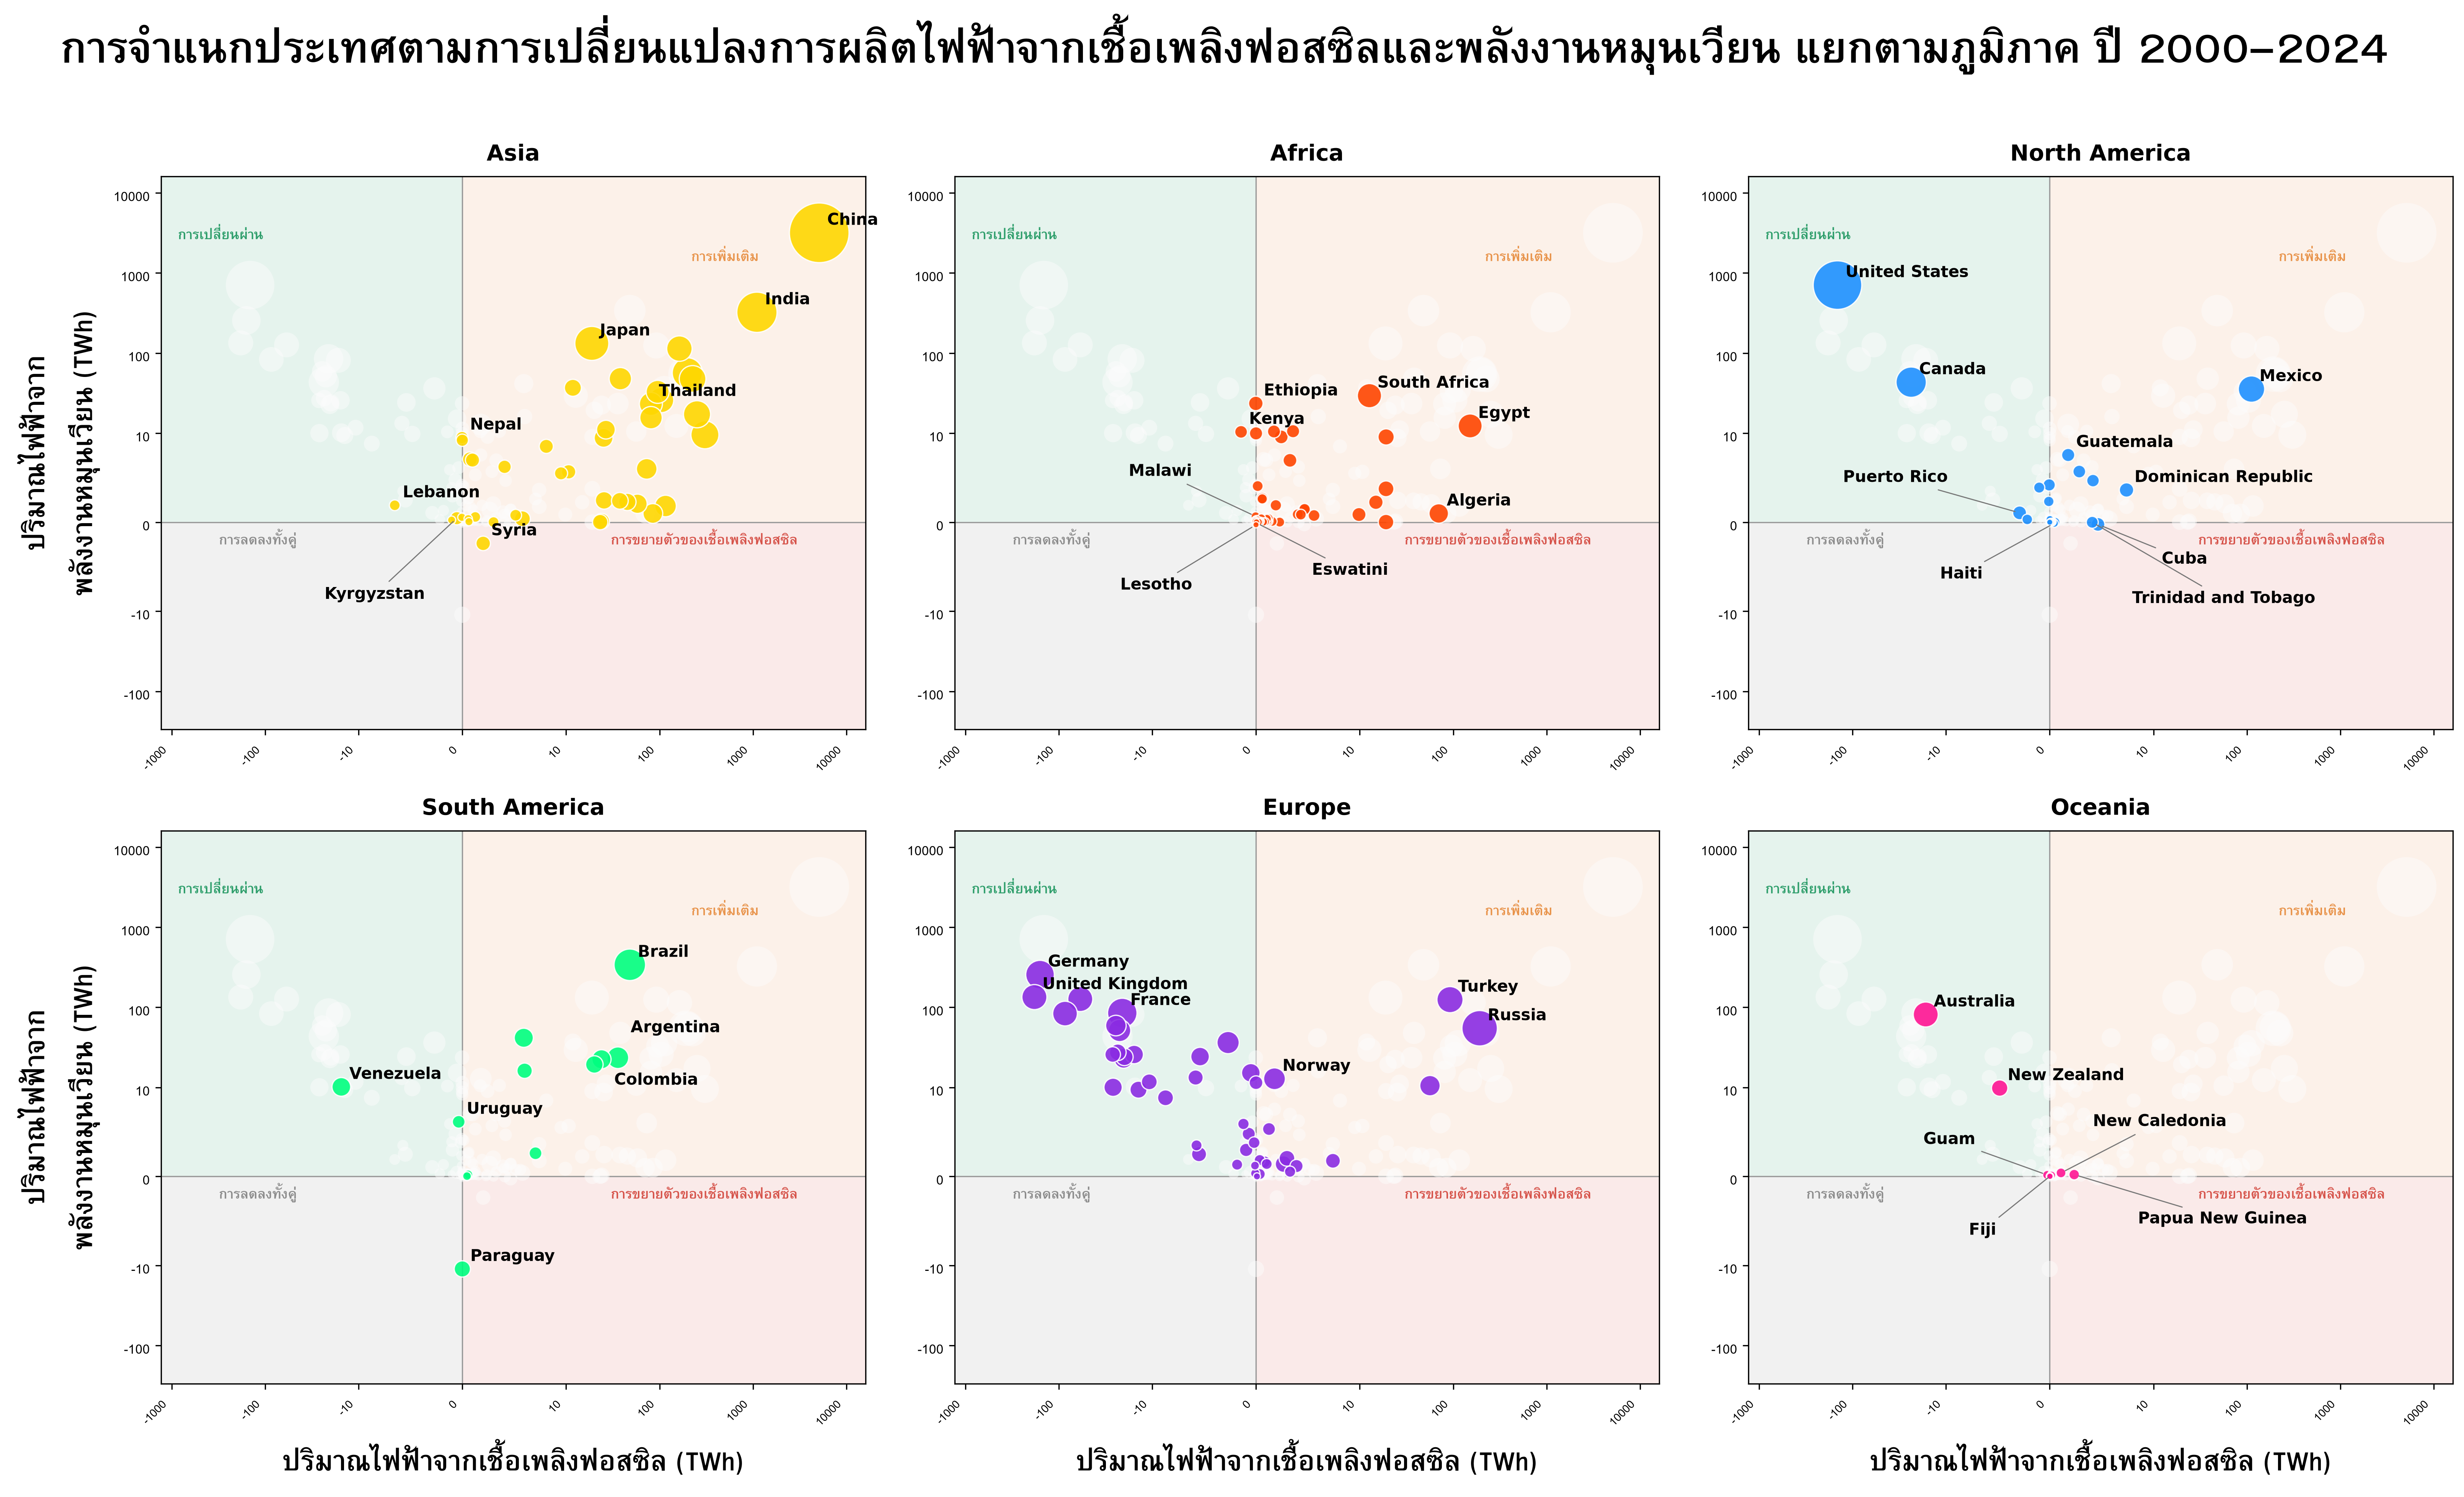

In [175]:
# ---------- 2. สีตามทวีป ----------
CONTINENT_COLORS = {          # ชุดเดียวกับ Figure 5
    'Asia':          '#FFD700',
    'North America': '#1e90ff',
    'Europe':        '#8A2BE2',
    'Africa':        '#FF4500',
    'South America': '#00FF7F',
    'Oceania':       '#FF1493',
}
GRAY = "#fcfcfc"

# ---------- 3. ขนาด bubble จาก electricity_generation (gen_2024) - scale เดียวกันทุกกราฟย่อย ----------
size_raw = np.sqrt(m['gen_2024'].clip(lower=0.01))
size_min, size_max = 15, 1400
m['bubble_size'] = np.interp(size_raw, (size_raw.min(), size_raw.max()), (size_min, size_max))

# ---------- 4. เลือกป้ายชื่อ: 3 ประเทศใหญ่สุด (ตาม gen_2024) ต่อจตุภาคในแต่ละทวีป + ไทย (ในทวีปเอเชีย) ----------
LABEL_TOP_N = 3
top_idx = (m.groupby(['continent', 'quadrant'])['gen_2024']
             .nlargest(LABEL_TOP_N).index.get_level_values(-1))
label_idx = set(top_idx)
thailand_idx = m[m['country'] == 'Thailand'].index
label_idx.update(thailand_idx)
m['show_label'] = m.index.isin(label_idx)

print("ประเทศที่แสดงชื่อ:")
print(m[m['show_label']][['continent', 'quadrant', 'country', 'gen_2024']]
      .sort_values(['continent', 'quadrant', 'gen_2024'], ascending=[True, True, False])
      .to_string(index=False))

# ---------- 5. แกน (scale เดียวกันทุกกราฟ แบบ symlog เหมือน Figure 7) ----------
LINTHRESH = 10
XLIM_4 = (-1300, 16000)
YLIM_4 = (-300, 16000)

X_TICKS = [-1000, -100, -10, 0, 10, 100, 1000, 10000]
Y_TICKS = [-100, -10, 0,10, 100, 1000, 10000]

# ---------- 5b. สี quadrant: ใช้ชุดเดียวกับกราฟ Bubble รวม (Cell 3) ----------
COLOR_ORANGE = '#E8934A'   # การเพิ่มเติม
COLOR_GREEN  = '#2E9E6B'   # การเปลี่ยนผ่าน
COLOR_RED    = '#D6534A'   # การขยายตัวของเชื้อเพลิงฟอสซิล
COLOR_GRAY   = '#8C8C8C'   # การลดลงทั้งคู่

QUADRANT_COLOR = {
    'การเพิ่มเติม': COLOR_ORANGE,
    'การเปลี่ยนผ่าน': COLOR_GREEN,
    'การขยายตัวของเชื้อเพลิงฟอสซิล': COLOR_RED,
    'การลดลงทั้งคู่': COLOR_GRAY,
}
QUADRANT_BG_ALPHA = 0.12   # เท่ากับกราฟ Bubble รวม

# ป้ายชื่อ quadrant บนพื้นหลังสี (ครบทั้ง 4 quadrant)
quadrant_label_pos = {
    'การเพิ่มเติม': (500, 1600),
    'การเปลี่ยนผ่าน': (-300, 3000),
    'การขยายตัวของเชื้อเพลิงฟอสซิล': (300, -2),
    'การลดลงทั้งคู่': (-120, -2),
}

def add_quadrant_labels(ax, positions):
    for label, (x, y) in positions.items():
        ax.text(x, y, label,
                fontsize=8, fontfamily=GARUDA, fontweight='bold',
                color=QUADRANT_COLOR[label], alpha=1.0,
                ha='center', va='center', zorder=1.5)

def add_quadrant_bg(ax, xlim, ylim):
    ax.add_patch(Rectangle((0, 0), xlim[1], ylim[1],
                            facecolor=QUADRANT_COLOR['การเพิ่มเติม'], edgecolor='none',
                            alpha=QUADRANT_BG_ALPHA, zorder=0))
    ax.add_patch(Rectangle((xlim[0], 0), 0 - xlim[0], ylim[1],
                            facecolor=QUADRANT_COLOR['การเปลี่ยนผ่าน'], edgecolor='none',
                            alpha=QUADRANT_BG_ALPHA, zorder=0))
    ax.add_patch(Rectangle((0, ylim[0]), xlim[1], 0 - ylim[0],
                            facecolor=QUADRANT_COLOR['การขยายตัวของเชื้อเพลิงฟอสซิล'], edgecolor='none',
                            alpha=QUADRANT_BG_ALPHA, zorder=0))
    ax.add_patch(Rectangle((xlim[0], ylim[0]), 0 - xlim[0], 0 - ylim[0],
                            facecolor=QUADRANT_COLOR['การลดลงทั้งคู่'], edgecolor='none',
                            alpha=QUADRANT_BG_ALPHA, zorder=0))

# ---------- 6. วาดกราฟ 2x3 ----------
continents = ['Asia', 'Africa', 'North America', 'South America', 'Europe', 'Oceania']
fig, axes = plt.subplots(2, 3, figsize=(22, 14), dpi=300)   # ขยายขนาดรูป
axes = axes.flatten()

# ปรับตำแหน่ง offset ของป้ายชื่อประเทศเฉพาะจุดที่ชิด/ทับกัน (หน่วย points จากจุดศูนย์กลางฟอง)
LABEL_OFFSET_OVERRIDES = {
    'Argentina': (8, 16),
    'Colombia': (8, -16),
    # ประเทศเล็กที่กระจุกใกล้จุด 0 -> ดึงป้ายออกมาพร้อมเส้นโยง
    'Kyrgyzstan': (-20, -48),
    'Malawi': (-40, 28), 'Eswatini': (35, -30), 'Lesotho': (-40, -38),
    'Haiti': (-45, -32), 'Cuba': (40, -22), 'Trinidad and Tobago': (25, -48),
    'Puerto Rico': (-45, 22),
    'Guam': (-45, 22), 'Fiji': (-35, -35), 'New Caledonia': (20, 32), 'Papua New Guinea': (40, -28),
}
LEADER_LINE_MIN = 20   # ถ้า offset ไกลกว่านี้ (points) จะวาดเส้นโยงไปที่ฟอง
DEFAULT_LABEL_OFFSET = (5, 5)

for i, cont in enumerate(continents):
    ax = axes[i]
    color = CONTINENT_COLORS[cont]

    # ทวีปอื่น -> สีเทาอ่อน (พื้นหลัง)
    other = m[m['continent'] != cont]
    ax.scatter(other['delta_fossil'], other['delta_ren'], s=other['bubble_size'],
               color=GRAY, alpha=0.5, edgecolor='none', zorder=2)

    # ทวีปนี้ -> สีของทวีป (ขอบขาวแบบ Figure 5 / ฟองใหญ่วาดก่อน ฟองเล็กอยู่บน)
    sub = m[m['continent'] == cont].sort_values('gen_2024', ascending=False)
    ax.scatter(sub['delta_fossil'], sub['delta_ren'], s=sub['bubble_size'],
               color=color, alpha=0.9, edgecolor='white', linewidth=0.8, zorder=3)

    # เส้นแบ่ง quadrant ที่ 0
    ax.axhline(0, color='#999999', linewidth=0.8, zorder=1)
    ax.axvline(0, color='#999999', linewidth=0.8, zorder=1)

    # พื้นหลังสี quadrant
    add_quadrant_bg(ax, XLIM_4, YLIM_4)
    add_quadrant_labels(ax, quadrant_label_pos)

    # ป้ายชื่อประเทศ (เฉพาะของทวีปนี้) - แก้ทับกัน + ตัวหนา
    labels = sub[sub['show_label']]
    for _, r in labels.iterrows():
        dx, dy = LABEL_OFFSET_OVERRIDES.get(r['country'], DEFAULT_LABEL_OFFSET)
        far = max(abs(dx), abs(dy)) >= LEADER_LINE_MIN
        ax.annotate(r['country'], (r['delta_fossil'], r['delta_ren']),
                    xytext=(dx, dy), textcoords='offset points',
                    ha='right' if dx < 0 else 'left',
                    va='center' if far else 'baseline',
                    fontsize=10, fontfamily=DEJAVU, fontweight='bold',
                    color='#000000', zorder=4,
                    arrowprops=dict(arrowstyle='-', color='#777777', lw=0.7,
                                    shrinkA=2, shrinkB=3) if far else None)

    # ชื่อทวีป (เหนือกราฟ)
    ax.set_title(cont, fontsize=14, fontfamily=DEJAVU, fontweight='bold', color='#000000', pad=10)

    # scale และแกน
    ax.set_xscale('symlog', linthresh=LINTHRESH, linscale=1)
    ax.set_yscale('symlog', linthresh=LINTHRESH, linscale=1)
    ax.set_xlim(XLIM_4)
    ax.set_ylim(YLIM_4)
    ax.set_xticks(X_TICKS)
    ax.set_yticks(Y_TICKS)
    ax.set_xticklabels([f"{t:g}" for t in X_TICKS], fontsize=7, rotation=45, ha='right')
    ax.set_yticklabels([f"{t:g}" for t in Y_TICKS], fontsize=8)
    ax.grid(True, which='major', color='None', linewidth=0.6, zorder=1)

    # แสดงชื่อแกนเฉพาะขอบนอกของตาราง (ซ้ายสุด / แถวล่างสุด) เพื่อลดความรก
    row, col = divmod(i, 3)
    if col == 0:
        ax.set_ylabel('ปริมาณไฟฟ้าจาก\nพลังงานหมุนเวียน (TWh)', fontsize=16, fontfamily=GARUDA, fontweight='bold')
    if row == 1:
        ax.set_xlabel('ปริมาณไฟฟ้าจากเชื้อเพลิงฟอสซิล (TWh)', fontsize=16, fontfamily=GARUDA, fontweight='bold')

# ---------- หัวข้อรวม ----------
fig.suptitle('การจำแนกประเทศตามการเปลี่ยนแปลงการผลิตไฟฟ้าจากเชื้อเพลิงฟอสซิลและพลังงานหมุนเวียน แยกตามภูมิภาค ปี 2000–2024',
             fontsize=25, fontfamily=GARUDA, fontweight='bold', color='#000000', x=0.5, y=0.965, ha='center')

plt.tight_layout(rect=[0.012, 0.035, 0.995, 0.955])
plt.savefig('figure6.png', dpi=300, facecolor='white')
print("saved")

#Figure 7

findfont: Font family 'Loma' not found.
findfont: Font family 'Loma' not found.
findfont: Font family 'Loma' not found.
findfont: Font family 'Loma' not found.
findfont: Font family 'Loma' not found.
findfont: Font family 'Loma' not found.
findfont: Font family 'Loma' not found.
findfont: Font family 'Loma' not found.
findfont: Font family 'Loma' not found.
findfont: Font family 'Loma' not found.
findfont: Font family 'Loma' not found.
findfont: Font family 'Loma' not found.
findfont: Font family 'Loma' not found.
findfont: Font family 'Loma' not found.
findfont: Font family 'Loma' not found.
findfont: Font family 'Loma' not found.
findfont: Font family 'Loma' not found.
findfont: Font family 'Loma' not found.
findfont: Font family 'Loma' not found.
findfont: Font family 'Loma' not found.
findfont: Font family 'Loma' not found.
findfont: Font family 'Loma' not found.
findfont: Font family 'Loma' not found.
findfont: Font family 'Loma' not found.
findfont: Font family 'Loma' not found.


จำนวนประเทศที่มีข้อมูลครบ 2000 & 2024: 194
quadrant
Addition            132
Transition           53
Fossil Expansion      8
Decline               1
Name: count, dtype: int64

=== % นับประเทศ ===
quadrant       Transition  Addition  Fossil Expansion  Decline
continent                                                     
Africa               10.0      86.0               4.0      0.0
Asia                 11.4      86.4               2.3      0.0
Europe               64.4      33.3               0.0      2.2
North America        27.6      58.6              13.8      0.0
Oceania              28.6      71.4               0.0      0.0
South America        16.7      75.0               8.3      0.0

=== % ถ่วงด้วย Δren ===
quadrant       Transition  Addition  Fossil Expansion  Decline
continent                                                     
Africa               21.6      78.4               0.0      0.0
Asia                  0.3      99.7               0.0      0.0
Europe               82.

findfont: Font family 'Loma' not found.
findfont: Font family 'Loma' not found.
findfont: Font family 'Loma' not found.
findfont: Font family 'Loma' not found.
findfont: Font family 'Loma' not found.
findfont: Font family 'Loma' not found.
findfont: Font family 'Loma' not found.
findfont: Font family 'Loma' not found.
findfont: Font family 'Loma' not found.
findfont: Font family 'Loma' not found.
findfont: Font family 'Loma' not found.
findfont: Font family 'Loma' not found.
findfont: Font family 'Loma' not found.
findfont: Font family 'Loma' not found.
findfont: Font family 'Loma' not found.
findfont: Font family 'Loma' not found.
findfont: Font family 'Loma' not found.
findfont: Font family 'Loma' not found.
findfont: Font family 'Loma' not found.
findfont: Font family 'Loma' not found.
findfont: Font family 'Loma' not found.
findfont: Font family 'Loma' not found.
findfont: Font family 'Loma' not found.
findfont: Font family 'Loma' not found.
findfont: Font family 'Loma' not found.


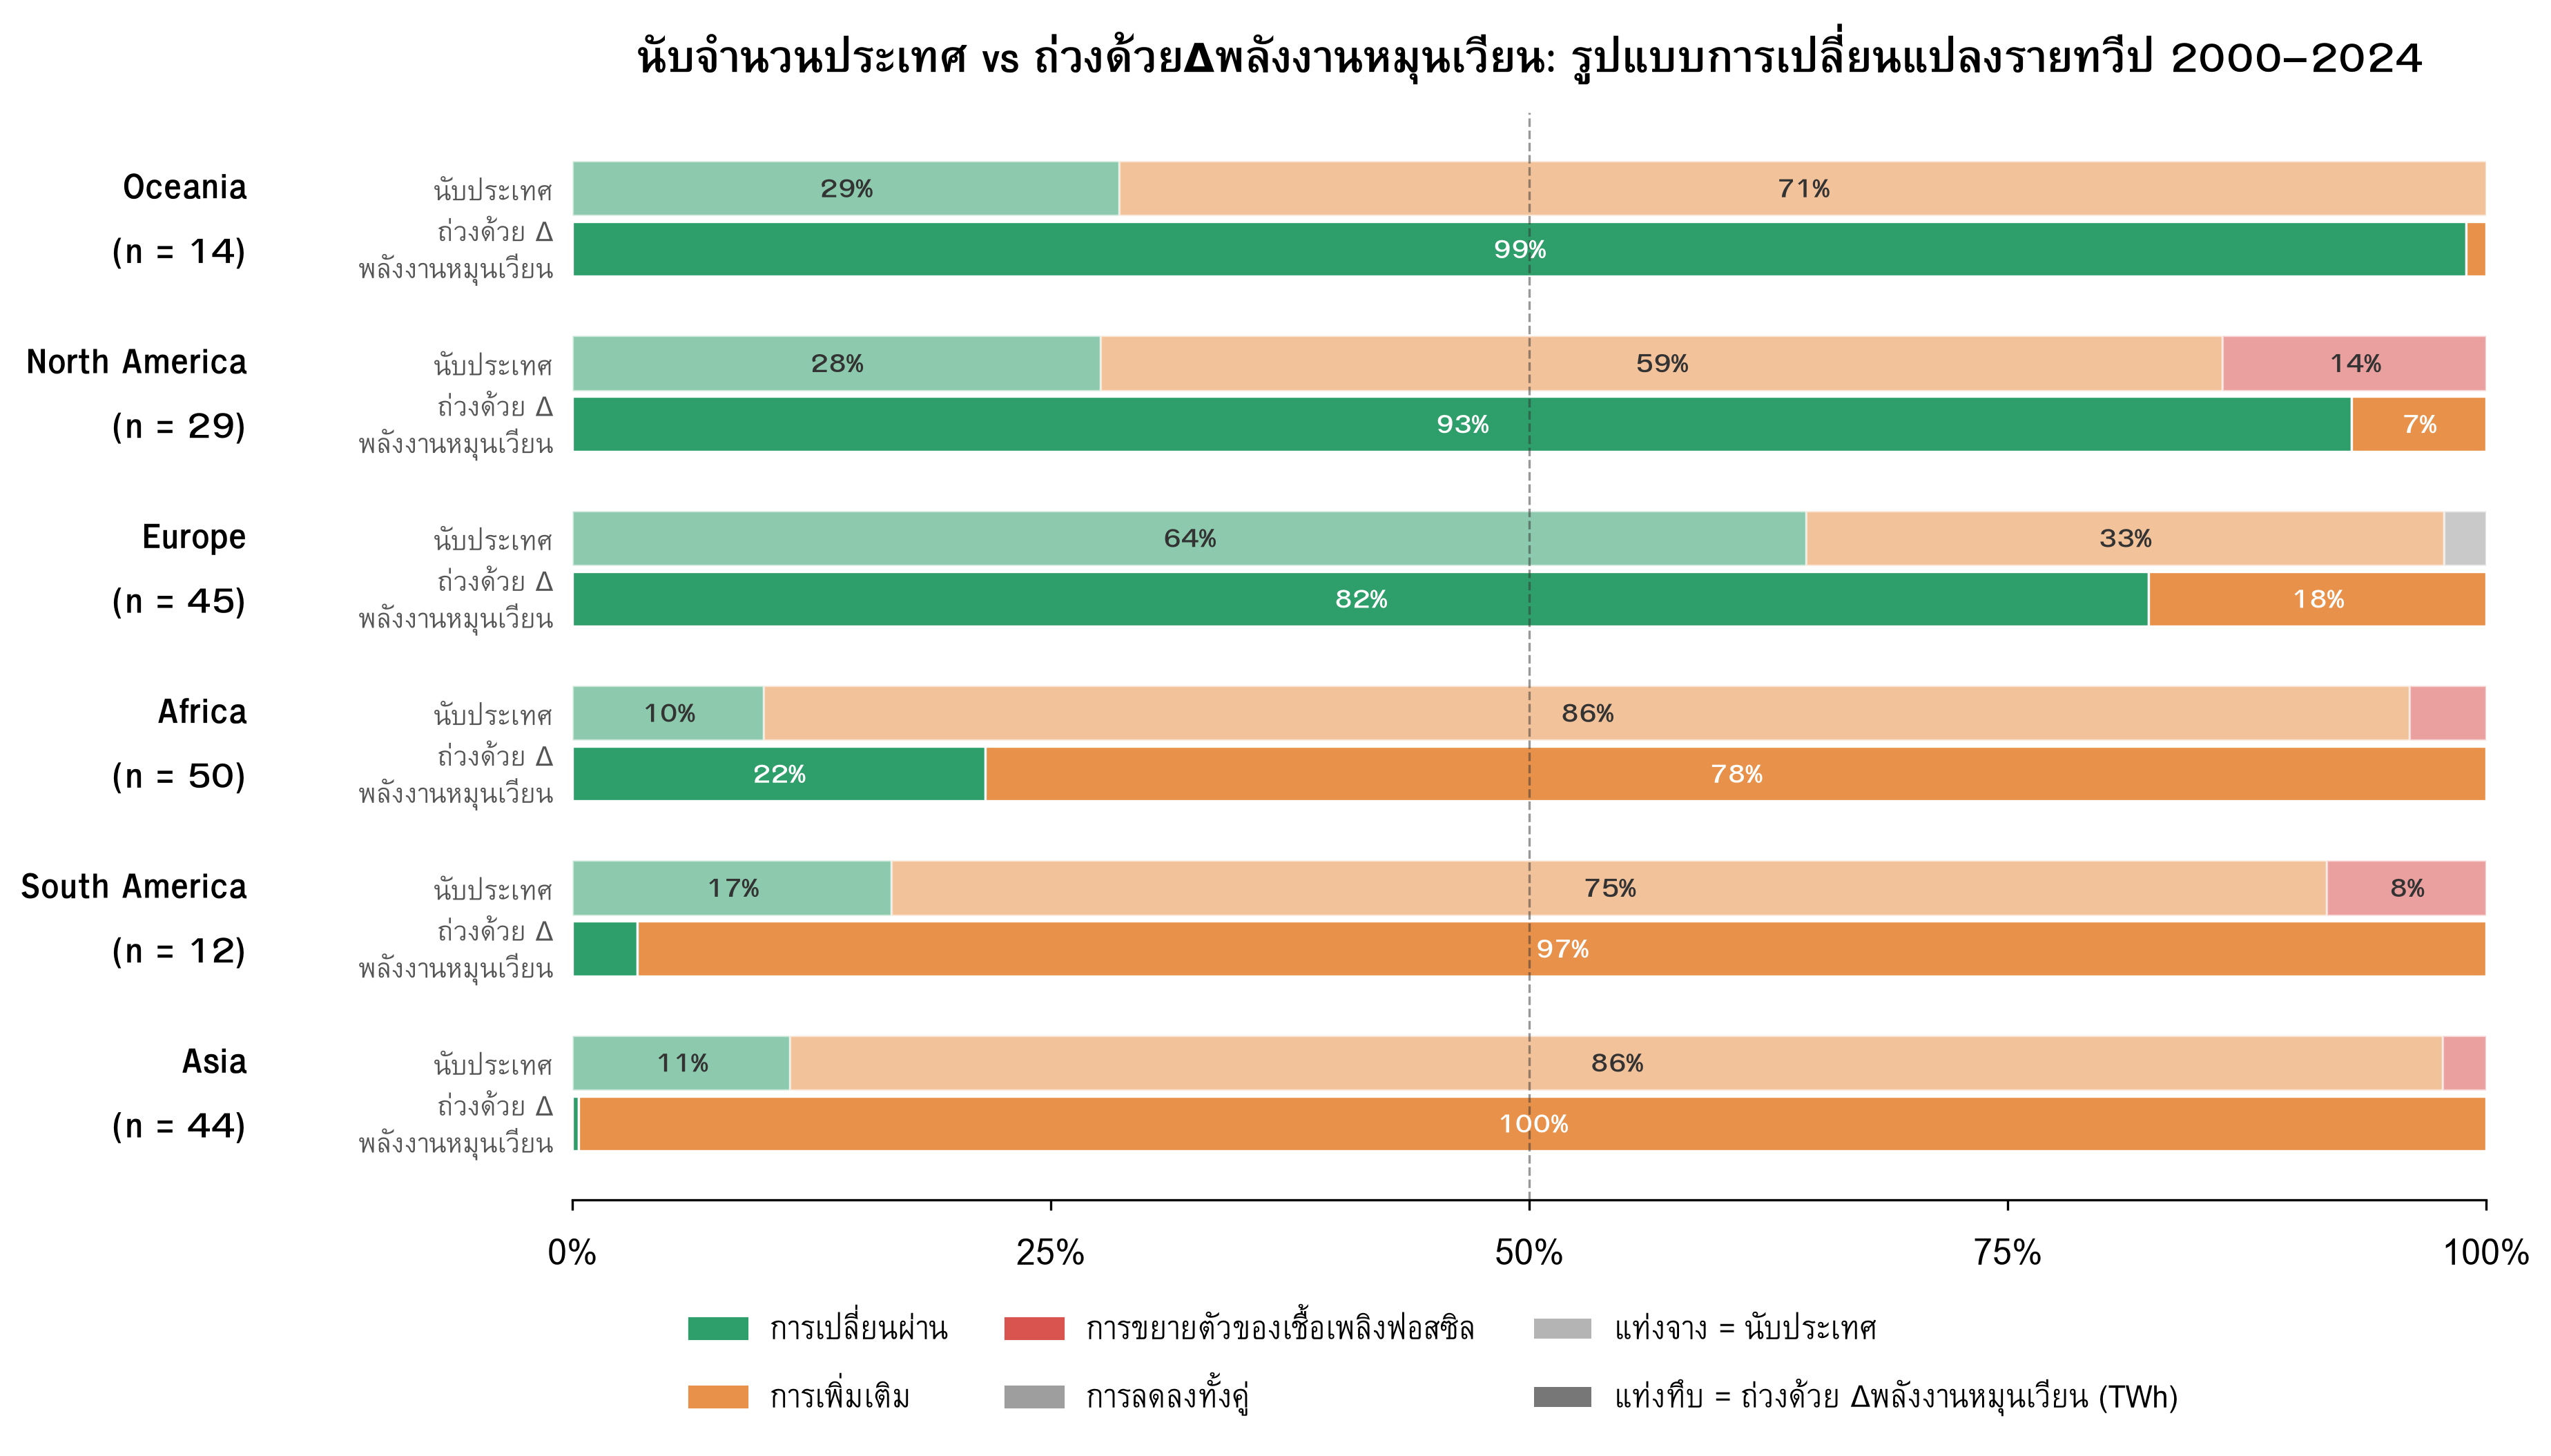

In [176]:
"""
Figure 7: นับจำนวนประเทศ vs ถ่วงด้วย Δพลังงานหมุนเวียน (Δren) รายทวีป
"""

# ============================================================
# 0. ตั้งค่า
# ============================================================
HAS_CONTINENT_COL = True   # True ถ้าไฟล์ cleaned มีคอลัมน์ continent อยู่แล้ว
YEAR_START, YEAR_END = 2000, 2024

FOSSIL_COLS = ["coal_electricity", "gas_electricity", "oil_electricity"]
# ปรับให้ตรงกับนิยาม "renewable" ที่ใช้จริงในโน้ตบุ๊กหลัก (Figure 1-5)
REN_COLS = ["solar_electricity", "wind_electricity", "hydro_electricity",
            "other_renewable_electricity"]

QUADRANTS = ["Transition", "Addition", "Fossil Expansion", "Decline"]
LABELS_TH = {"Transition": "การเปลี่ยนผ่าน", "Addition": "การเพิ่มเติม",
             "Fossil Expansion": "การขยายตัวของเชื้อเพลิงฟอสซิล",
             "Decline": "การลดลงทั้งคู่"}
COLORS = {"Transition": "#2E9E6B", "Addition": "#E8914A",
          "Fossil Expansion": "#D9534F", "Decline": "#9E9E9E"}
CONTINENT_LABEL = {"Europe": "Europe", "North America": "North America",
                    "Oceania": "Oceania", "South America": "South America",
                    "Asia": "Asia", "Africa": "Africa"}

plt.rcParams["font.family"] = ["Garuda", "Loma", "DejaVu Sans"]


# ============================================================
# 1. โหลดข้อมูล + จับคู่ทวีป (ข้ามได้ถ้า HAS_CONTINENT_COL = True)
# ============================================================
MANUAL_CONTINENT = {
    "East Timor": "Asia",
    "Western Sahara": "Africa",
    "Netherlands Antilles": "North America",
}


def map_continent(country, iso3):
    if country in MANUAL_CONTINENT:
        return MANUAL_CONTINENT[country]
    import pycountry_convert as pc
    try:
        iso2 = pc.country_alpha3_to_country_alpha2(iso3)
        code = pc.country_alpha2_to_continent_code(iso2)
        return {"AF": "Africa", "AS": "Asia", "EU": "Europe",
                "NA": "North America", "OC": "Oceania",
                "SA": "South America", "AN": "Antarctica"}.get(code)
    except Exception:
        return None


def load_data(source_df):
    d = source_df[source_df["iso_code"].notna()].copy()
    if not HAS_CONTINENT_COL:
        d["continent"] = d.apply(
            lambda r: map_continent(r["country"], r["iso_code"]), axis=1)
    d = d[d["continent"] != "Antarctica"]
    return d


# ============================================================
# 2. คำนวณ Δfossil, Δren ต่อประเทศ (2000→2024) แล้วจำแนกกลุ่ม
# ============================================================
def classify_countries(d):
    d = d[d["year"].isin([YEAR_START, YEAR_END])].copy()
    d["fossil"] = d[FOSSIL_COLS].sum(axis=1, min_count=1)
    d["ren"] = d[REN_COLS].sum(axis=1, min_count=1)

    p_fossil = d.pivot(index="country", columns="year", values="fossil")
    p_ren = d.pivot(index="country", columns="year", values="ren")

    # เก็บเฉพาะประเทศที่มีข้อมูลครบทั้งสองปี ทั้ง fossil และ ren
    complete = p_fossil.dropna().index.intersection(p_ren.dropna().index)

    cont_map = d.drop_duplicates("country").set_index("country")["continent"]

    res = pd.DataFrame({
        "continent": cont_map.loc[complete],
        "d_fossil": p_fossil.loc[complete, YEAR_END] - p_fossil.loc[complete, YEAR_START],
        "d_ren": p_ren.loc[complete, YEAR_END] - p_ren.loc[complete, YEAR_START],
    })

    def quadrant(row):
        if row["d_ren"] >= 0 and row["d_fossil"] < 0:
            return "Transition"
        if row["d_ren"] >= 0 and row["d_fossil"] >= 0:
            return "Addition"
        if row["d_ren"] < 0 and row["d_fossil"] >= 0:
            return "Fossil Expansion"
        return "Decline"

    res["quadrant"] = res.apply(quadrant, axis=1)
    return res


# ============================================================
# 3. สร้างตาราง % นับประเทศ vs % ถ่วงด้วย Δren
# ============================================================
def build_percentages(res):
    count_pct = pd.crosstab(res["continent"], res["quadrant"], normalize="index") * 100

    # ถ่วงด้วย Δren: ประเทศกลุ่ม Fossil Expansion มี d_ren ติดลบ (renewable ลดลง)
    # -> clip เป็น 0 ก่อนคำนวณสัดส่วน เพราะเป็นสัดส่วนที่เล็กมากเทียบกับผลรวมทวีป
    #    (ตรวจสอบขนาดจริงก่อนใช้ — ถ้าทวีปไหนมีค่าลบมากผิดปกติ ต้องดูเป็นกรณีพิเศษ)
    raw = res.groupby(["continent", "quadrant"])["d_ren"].sum().unstack(fill_value=0)
    raw_clipped = raw.clip(lower=0)
    weighted_pct = raw_clipped.div(raw_clipped.sum(axis=1), axis=0) * 100

    count_pct = count_pct.reindex(columns=QUADRANTS, fill_value=0)
    weighted_pct = weighted_pct.reindex(columns=QUADRANTS, fill_value=0).fillna(0)
    return count_pct, weighted_pct


# ============================================================
# 4. วาดกราฟ
# ============================================================
def plot(count_pct, weighted_pct, n_per_continent, save_path="images/figure6b.png"):
    order = weighted_pct["Transition"].sort_values().index.tolist()

    fig, ax = plt.subplots(figsize=(12, 7.5), dpi=300)
    bar_h, gap = 0.36, 0.04
    ypos = np.arange(len(order)) * 1.15

    for i, cont in enumerate(order):
        rows = [(count_pct, ypos[i] + bar_h / 2 + gap / 2, "นับประเทศ", 0.55),
                (weighted_pct, ypos[i] - bar_h / 2 - gap / 2, "ถ่วงด้วย Δ\nพลังงานหมุนเวียน", 1.0)]
        for table, y, row_label, alpha in rows:
            left = 0
            for q in QUADRANTS:
                v = table.loc[cont, q]
                if v <= 0:
                    continue
                ax.barh(y, v, left=left, height=bar_h, color=COLORS[q],
                        alpha=alpha, edgecolor="white", linewidth=0.8)
                if v >= 6:
                    ax.text(left + v / 2, y, f"{v:.0f}%", ha="center", va="center",
                            fontsize=9, color="white" if alpha == 1.0 else "#333",
                            fontweight="bold")
                left += v
            ax.text(-1, y, row_label, ha="right", va="center", fontsize=9, color="#555", linespacing=0.85)
        ax.text(-17, ypos[i], f"{CONTINENT_LABEL.get(cont, cont)}\n(n = {n_per_continent[cont]})",
                ha="right", va="center", fontsize=12, fontweight="bold")

    ax.axvline(50, color="#333", lw=0.8, ls="--", alpha=0.5)
    ax.set_xlim(0, 100)
    ax.set_ylim(ypos[0] - 0.7, ypos[-1] + 0.7)
    ax.set_yticks([])
    ax.set_xticks(range(0, 101, 25))
    ax.set_xticklabels([f"{x}%" for x in range(0, 101, 25)])
    for s in ["top", "right", "left"]:
        ax.spines[s].set_visible(False)

    ax.set_title("นับจำนวนประเทศ vs ถ่วงด้วยΔพลังงานหมุนเวียน: รูปแบบการเปลี่ยนแปลงรายทวีป 2000–2024",
                 fontsize=14, fontweight="bold", pad=14)
    handles = [mpatches.Patch(color=COLORS[q], label=LABELS_TH[q]) for q in QUADRANTS]
    handles += [mpatches.Patch(facecolor="#777", alpha=0.55, label="แท่งจาง = นับประเทศ"),
                mpatches.Patch(facecolor="#777", label="แท่งทึบ = ถ่วงด้วย Δพลังงานหมุนเวียน (TWh)")]
    ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.45, -0.07),
              ncol=3, frameon=False, fontsize=10)
    fig.subplots_adjust(left=0.2, right=0.97, top=0.88, bottom=0.18)
    Path(save_path).parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    return fig

# ============================================================
# main
# ============================================================
if __name__ == "__main__":
    d = load_data(df)
    res = classify_countries(d)

    print(f"จำนวนประเทศที่มีข้อมูลครบ 2000 & {YEAR_END}: {len(res)}")
    print(res["quadrant"].value_counts())
    print()

    count_pct, weighted_pct = build_percentages(res)
    n = res["continent"].value_counts()

    print("=== % นับประเทศ ===")
    print(count_pct.round(1))
    print("\n=== % ถ่วงด้วย Δren ===")
    print(weighted_pct.round(1))

    plot(count_pct, weighted_pct, n, save_path="images/figure6b.png")
    count_pct.round(1).to_csv("continent_count_pct.csv")
    weighted_pct.round(1).to_csv("continent_weighted_pct.csv")
    res.to_csv("country_classification.csv")


#Table3-5

Saved: table3_4_side_by_side.png
Saved: table5_merge_verdict.png
DONE — combined Tables 3-4 and Table 5 generated.


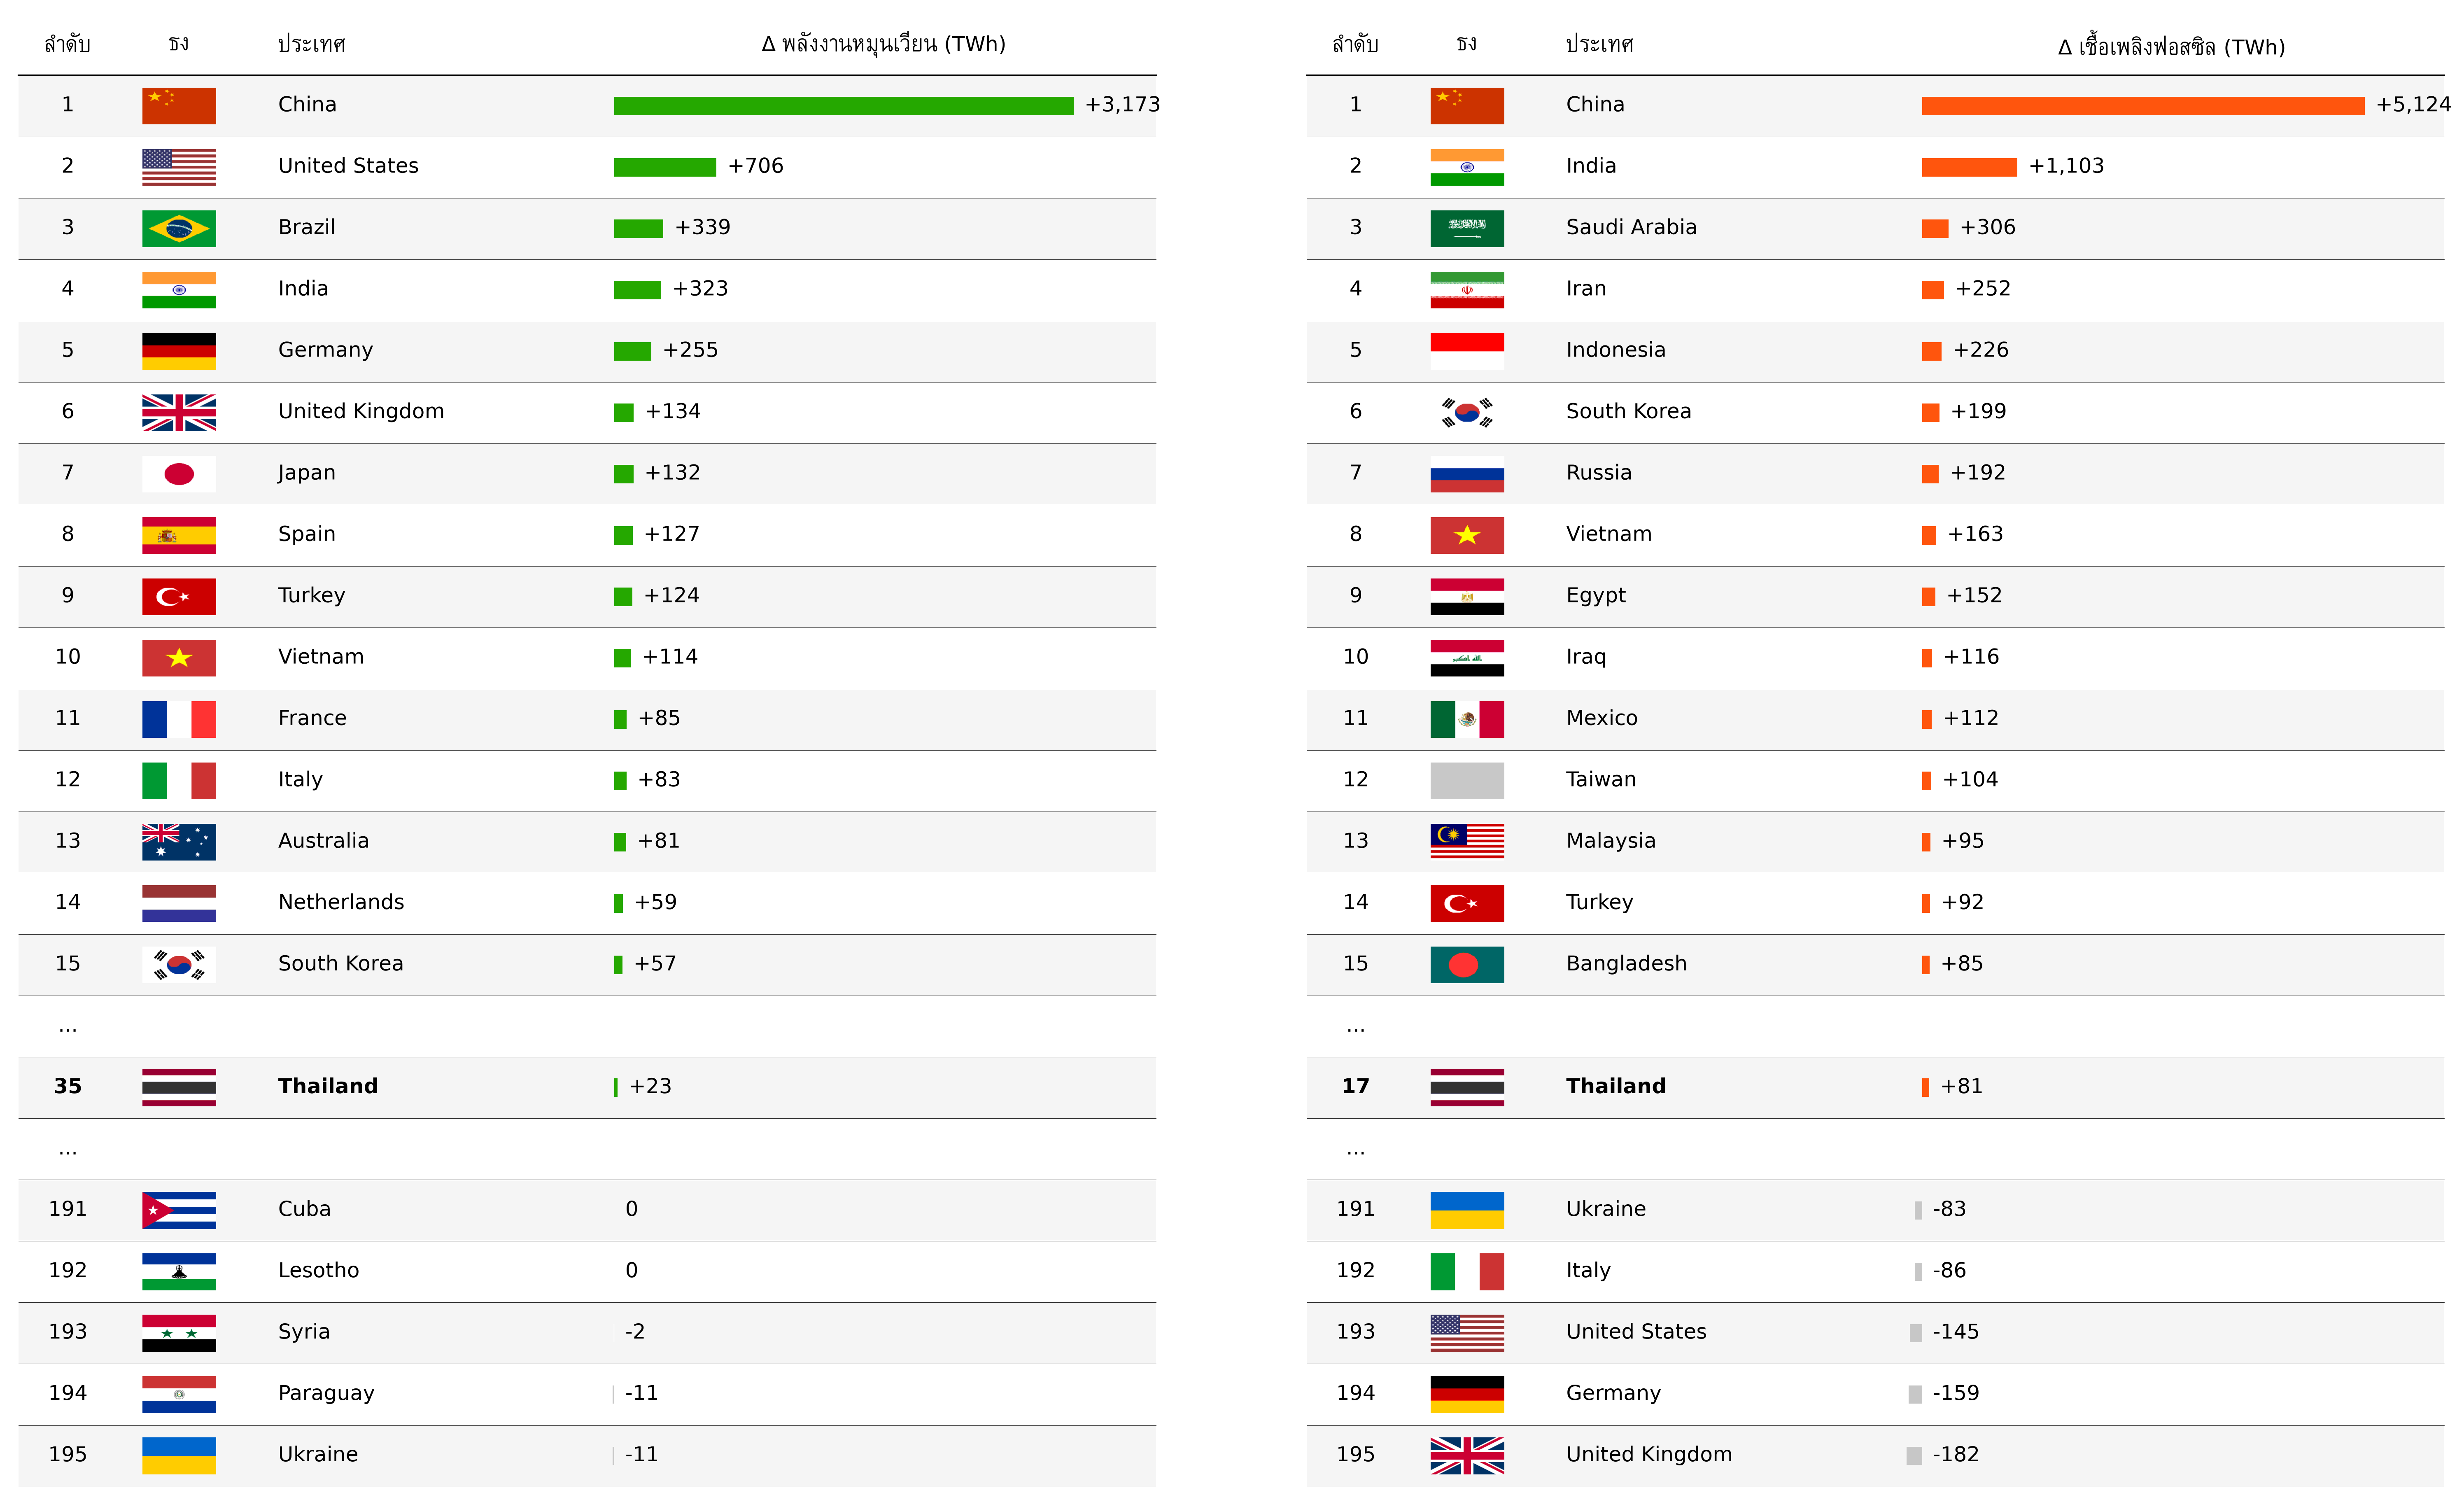

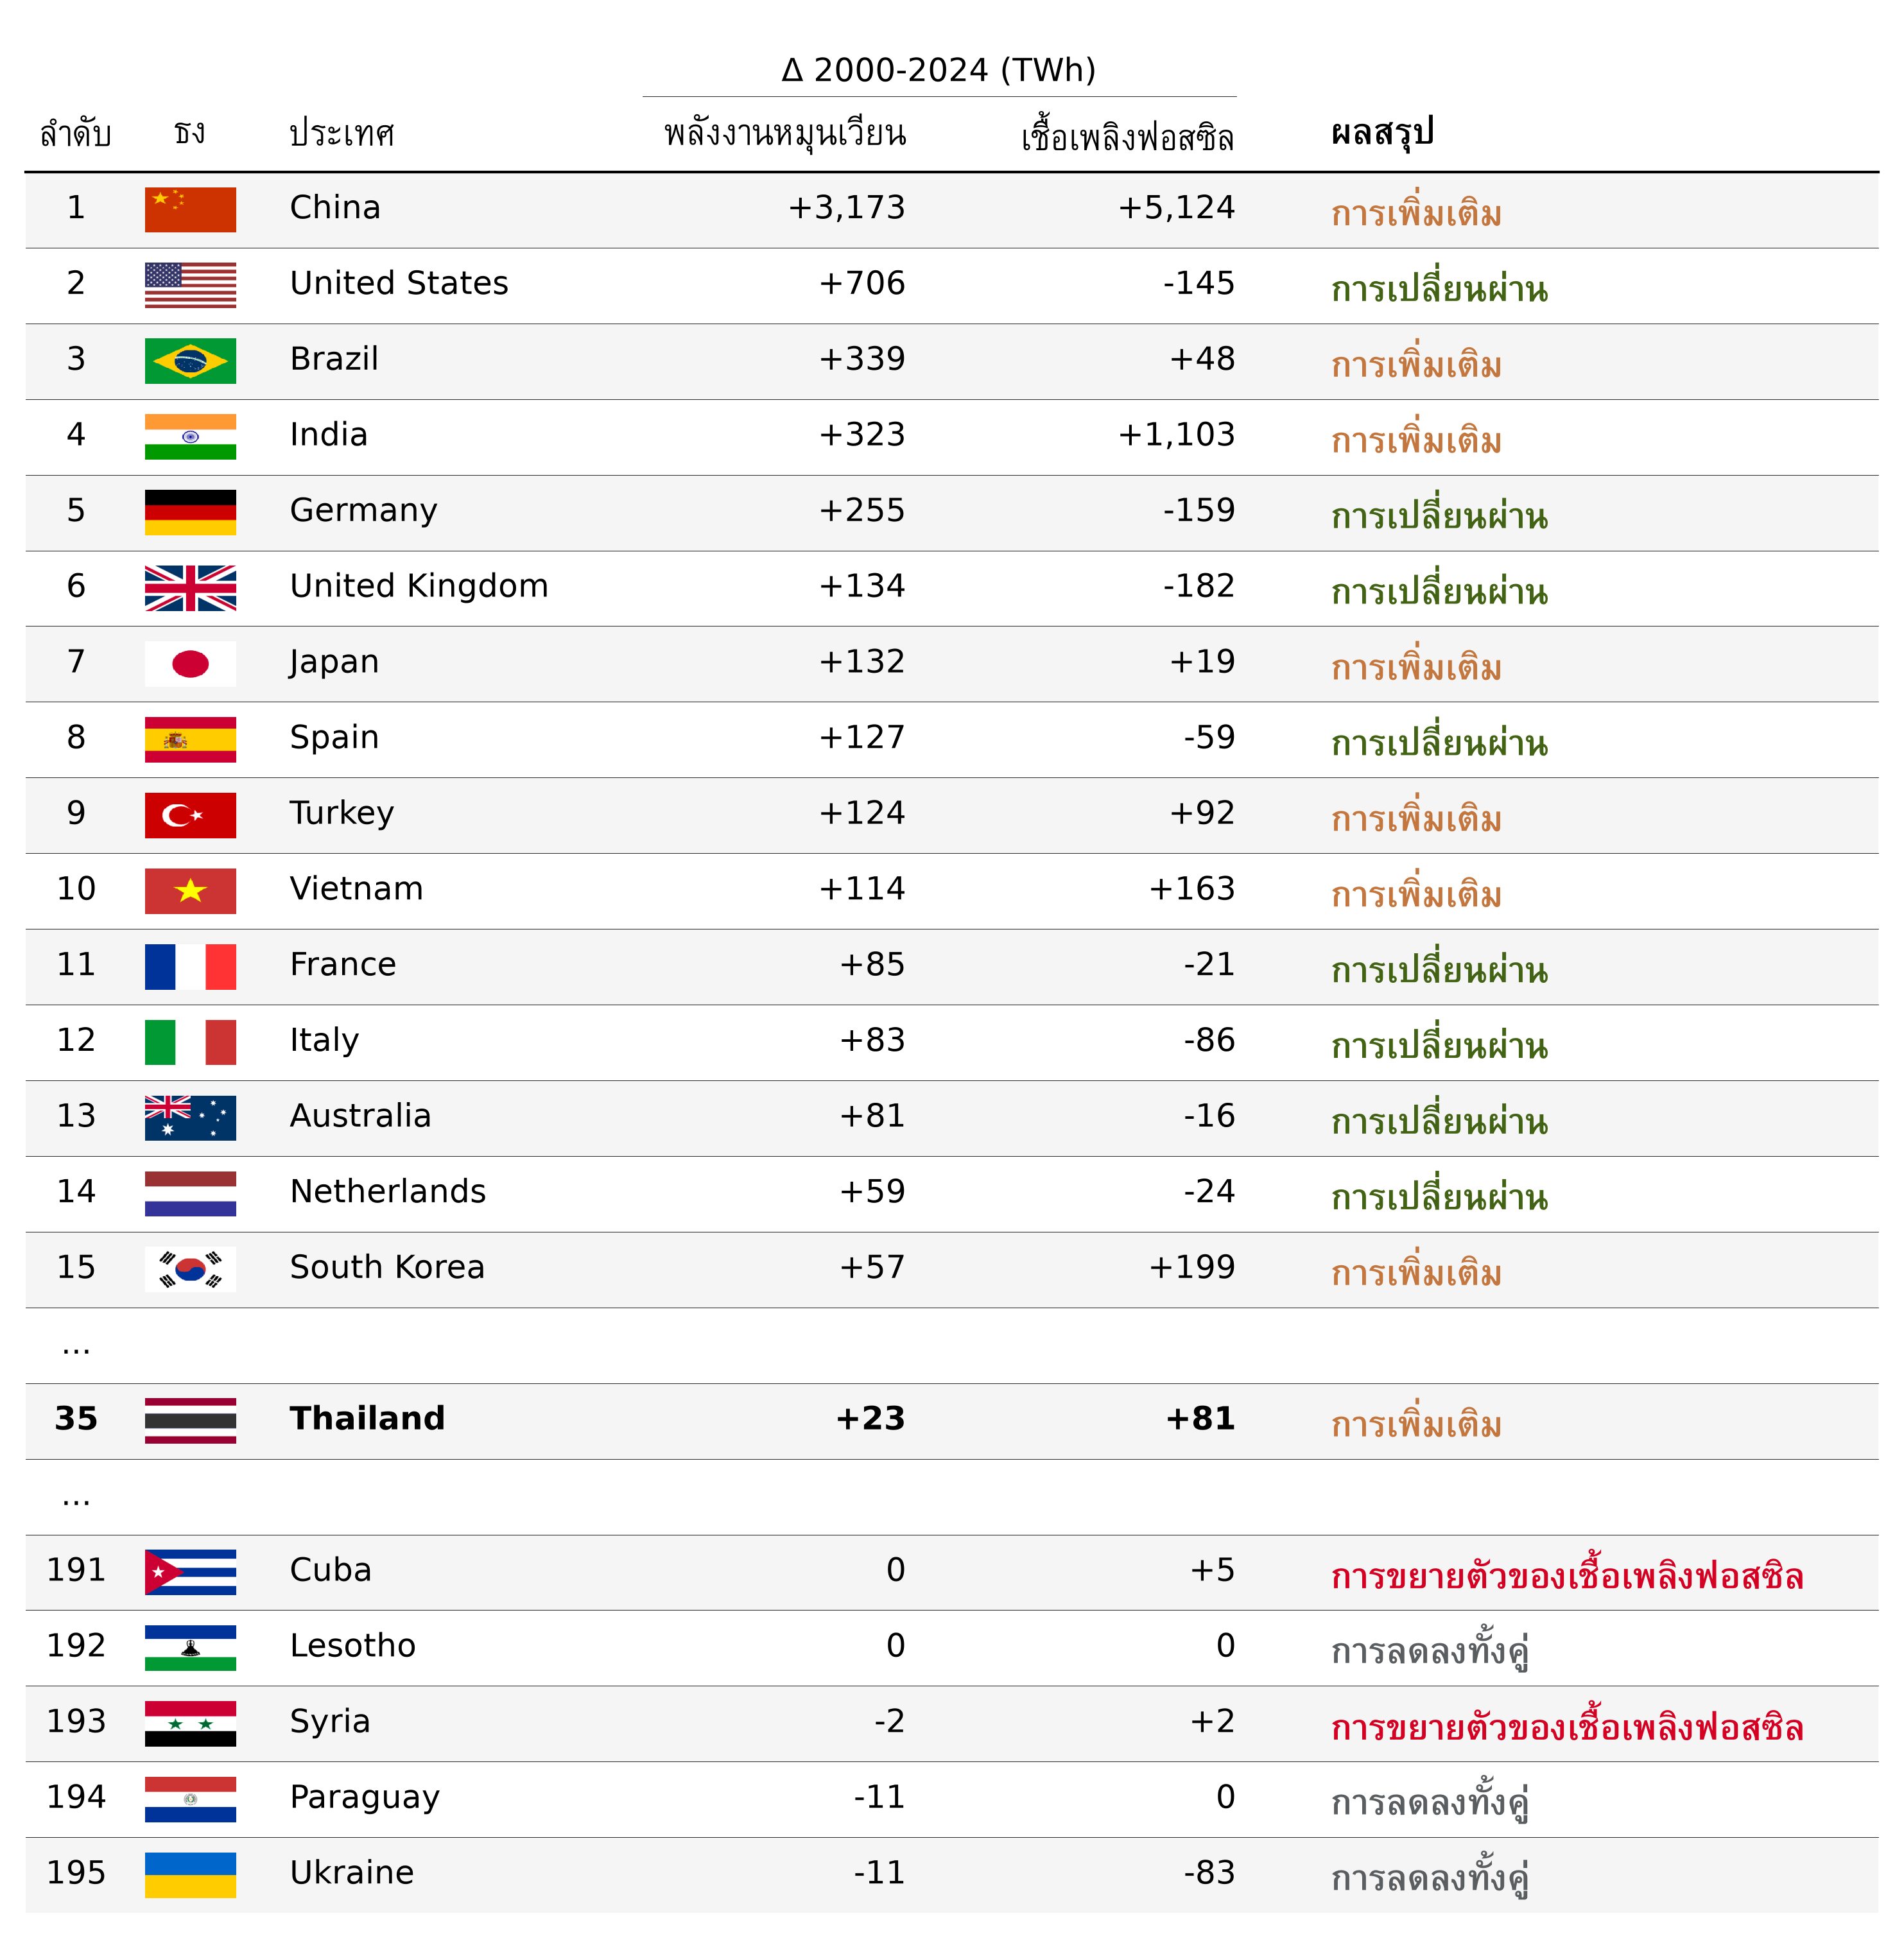

In [177]:
GARUDA_PATHS = [
    "/usr/share/fonts/truetype/tlwg/Garuda.ttf",
    "/usr/share/fonts/truetype/tlwg/Garuda-Bold.ttf",
]
for p in GARUDA_PATHS:
    if os.path.exists(p):
        fm.fontManager.addfont(p)

THAI_FONT = ["DejaVu Sans", "Garuda"]   # ใช้กับข้อความไทย (หัวข้อ/หัวตาราง) — DejaVu นำหน้าเพื่อกัน glyph เพี้ยนตอนผสมกับอังกฤษ/ตัวเลข
EN_FONT = ["DejaVu Sans"]               # ใช้กับชื่อประเทศ / ตัวเลขล้วน

plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False

TITLE_SIZE = 18
BODY_SIZE = 12

# --------------------------------------------------------------------------
# 1) โหลดข้อมูล + คำนวณ Delta RE / Delta Fossil (2000 -> 2024)
# --------------------------------------------------------------------------
# RE     = solar + wind + hydro + other_renewable   (ไม่รวม nuclear / biofuel เพราะไม่มีคอลัมน์แยก)
# Fossil = coal + gas + oil

# ใช้ข้อมูล df ที่โหลดไว้ในเซลล์ Import file
table_df = df.copy()
table_df["RE"] = (
    table_df["solar_electricity"]
    + table_df["wind_electricity"]
    + table_df["hydro_electricity"]
    + table_df["other_renewable_electricity"]
)
table_df["Fossil"] = table_df["coal_electricity"] + table_df["gas_electricity"] + table_df["oil_electricity"]

pivot = table_df[table_df["year"].isin([2000, 2024])].pivot(
    index="country", columns="year", values=["RE", "Fossil"]
)
pivot.columns = [f"{a}_{b}" for a, b in pivot.columns]
pivot["delta_re"] = pivot["RE_2024"] - pivot["RE_2000"]
pivot["delta_fossil"] = pivot["Fossil_2024"] - pivot["Fossil_2000"]
pivot = pivot.dropna(subset=["delta_re", "delta_fossil"]).reset_index()

# --------------------------------------------------------------------------
# 2) เตรียมธงประเทศ (flagpy) -> เซฟเป็นไฟล์ png ให้ plottable เรียกใช้
# --------------------------------------------------------------------------
FLAG_NAME_MAP = {
    "United States": "The United States",
    "United Kingdom": "The United Kingdom",
    "United Arab Emirates": "The United Arab Emirates",
    "Czechia": "The Czech Republic",
    "Netherlands": "The Netherlands",
    "Philippines": "The Philippines",
    "Democratic Republic of Congo": "The Democratic Republic Of The Congo",
    "Congo": "The Republic Of The Congo",
    "Bahamas": "The Bahamas",
    "Gambia": "The Gambia",
    "Maldives": "The Maldives",
    "Marshall Islands": "The Marshall Islands",
    "Micronesia (country)": "The Federated States Of Micronesia",
    "Central African Republic": "The Central African Republic",
    "Comoros": "The Comoros",
    "Dominican Republic": "The Dominican Republic",
    "Timor": "East Timor",
    "Cote d'Ivoire": "Ivory Coast",
    "Sao Tome and Principe": "São Tomé And Príncipe",
    "Saint Kitts and Nevis": "Saint Kitts And Nevis",
    "Saint Vincent and the Grenadines": "Saint Vincent And The Grenadines",
    "Antigua and Barbuda": "Antigua And Barbuda",
    "Bosnia and Herzegovina": "Bosnia And Herzegovina",
    "Trinidad and Tobago": "Trinidad And Tobago",
}

FLAG_DIR = "flags"
os.makedirs(FLAG_DIR, exist_ok=True)


def get_flag_path(country: str) -> str:
    """โหลดธงจาก flagpy แล้วเซฟเป็นไฟล์ .png คืน path (มี cache กันโหลดซ้ำ)"""
    safe_name = country.replace(" ", "_").replace("/", "-")
    out_path = os.path.join(FLAG_DIR, f"{safe_name}.png")
    if os.path.exists(out_path):
        return out_path

    lookup_name = FLAG_NAME_MAP.get(country, country)
    try:
        img = fp.get_flag_img(lookup_name)
        img.save(out_path)
    except Exception:
        placeholder = PILImage.new("RGB", (180, 90), color=(200, 200, 200))
        placeholder.save(out_path)
    return out_path


# --------------------------------------------------------------------------
# 3) ฟังก์ชันจัดอันดับ: Top 15 + Thailand (ถ้าไม่ติด Top15) + Bottom 5
# --------------------------------------------------------------------------
N_TOP = 15
N_BOTTOM = 5


def build_rank_table(pivot_df: pd.DataFrame, sort_col: str, n_top=N_TOP, n_bottom=N_BOTTOM):
    ranked = pivot_df.sort_values(sort_col, ascending=False).reset_index(drop=True)
    ranked["No."] = ranked.index + 1

    top = ranked.head(n_top)
    bottom = ranked.tail(n_bottom)
    th_row = ranked[ranked["country"] == "Thailand"]

    parts = [top]
    if not th_row.empty and th_row["No."].iloc[0] not in top["No."].values:
        parts.append(th_row)
    parts.append(bottom)

    out = pd.concat(parts).drop_duplicates(subset="No.").sort_values("No.")
    return out.reset_index(drop=True)


# --------------------------------------------------------------------------
# 3b) แทรกแถวคั่น "..." ตรงจุดที่อันดับกระโดดข้าม (เช่น 15 -> 35 -> 191)
#     ใส่ "..." เฉพาะคอลัมน์ลำดับ ส่วนคอลัมน์อื่นเว้นว่างไว้
# --------------------------------------------------------------------------
def insert_gap_rows(df: pd.DataFrame, rank_col: str) -> pd.DataFrame:
    df = df.reset_index(drop=True)
    out_rows = []
    prev_no = None
    gap_id = 0  # ใช้เป็นเลขติดลบ ไม่ซ้ำกัน เผื่อมีมากกว่า 1 จุดกระโดด
    for _, row in df.iterrows():
        cur_no = row[rank_col]
        if prev_no is not None and (cur_no - prev_no) > 1:
            gap_id -= 1
            gap_row = {}
            for col in df.columns:
                if col == rank_col:
                    gap_row[col] = gap_id  # sentinel ติดลบ -> format เป็น "..."
                elif pd.api.types.is_numeric_dtype(df[col]):
                    gap_row[col] = np.nan
                else:
                    gap_row[col] = ""  # ว่างไว้ (ไม่ใช่ None กัน str(None) โชว์คำว่า "None")
            out_rows.append(gap_row)
        out_rows.append(row.to_dict())
        prev_no = cur_no
    return pd.DataFrame(out_rows)


def format_rank(v) -> str:
    """แสดงเลขลำดับปกติ หรือ '...' สำหรับแถวคั่น (sentinel ติดลบ)"""
    if v is None or (isinstance(v, float) and pd.isna(v)):
        return "..."
    if v < 0:
        return "..."
    return f"{int(v)}"


# --------------------------------------------------------------------------
# 4) ตัวช่วยจัดรูปแบบตัวเลข -> เครื่องหมาย +/- และจำนวนเต็ม (ไม่มีทศนิยม)
# --------------------------------------------------------------------------
def format_plusminus(val) -> str:
    if val is None or (isinstance(val, float) and pd.isna(val)):
        return ""
    v = round(val)
    if v == 0:
        return "0"
    return f"{v:+,}"


# --------------------------------------------------------------------------
# 4a) วาดธงแบบปลอดภัย: ถ้าไม่มี path (แถวคั่น) ให้เว้นว่าง ไม่ error
# --------------------------------------------------------------------------
def safe_image(ax, path):
    ax.axis("off")
    if path is None or (isinstance(path, float) and pd.isna(path)) or path == "":
        return
    return image(ax, path)


# --------------------------------------------------------------------------
# 4b) Custom bar-in-cell: ตัวเลขอยู่ "นอกแท่งเสมอ" (กันตัวเลขทับแท่งสีเข้ม)
#     ค่าติดลบ -> แท่งสีเทาอ่อน (แยกให้เห็นชัดจากค่าบวก)
# --------------------------------------------------------------------------
NEG_BAR_COLOR = "#C7C7C7"


def bar_outside_label(ax, val, xlim, pos_color, neg_color=NEG_BAR_COLOR,
                       formatter=format_plusminus, textprops=None, bar_height=0.5):
    textprops = textprops or {}
    ax.set_xlim(xlim)
    ax.set_ylim(0, 1)
    ax.axis("off")

    if val is None or (isinstance(val, float) and pd.isna(val)):
        return  # แถวคั่น "..." -> ไม่วาดอะไรในคอลัมน์นี้

    color = pos_color if val >= 0 else neg_color
    ax.barh(0.5, val, height=bar_height, color=color, ec="None", zorder=0.05)

    text = formatter(val)
    pad = 0.02 * (xlim[1] - xlim[0])  # ระยะห่างคงที่จากปลายแท่ง / จากเส้นศูนย์
    # ข้อความอยู่ "ทางขวาเสมอ" ไม่ว่าค่าจะบวกหรือลบ (อ่านง่าย เรียงแนวเดียวกัน)
    x = val + pad if val >= 0 else pad
    ax.text(x, 0.5, text, va="center", ha="left", zorder=0.3, **textprops)


# --------------------------------------------------------------------------
# 5) Verdict logic (ตาม Four Quadrants)
# --------------------------------------------------------------------------
def get_verdict(row):
    re_up = row["delta_re"] > 0
    fossil_up = row["delta_fossil"] > 0
    if fossil_up and re_up:
        return "การเพิ่มเติม"
    elif (not fossil_up) and re_up:
        return "การเปลี่ยนผ่าน"
    elif fossil_up and (not re_up):
        return "การขยายตัวของเชื้อเพลิงฟอสซิล"
    else:
        return "การลดลงทั้งคู่"


# สีตัวอักษรตรงกับนิยามใน Table 1
VERDICT_COLORS = {'การเปลี่ยนผ่าน': '#426214', 'การเพิ่มเติม': '#C3773F', 'การลดลงทั้งคู่': '#5A5E60', 'การขยายตัวของเชื้อเพลิงฟอสซิล': '#D40123'}
NEUTRAL_VERDICT_COLOR = "#5A5E60"


def bold_country_row(tab: Table, table_df: pd.DataFrame, country="Thailand",
                      country_col="country", col_names=None):
    """ทำให้แถวของ 'country' (เช่น Thailand) เป็นตัวหนาทุกคอลัมน์ข้อความที่กำหนด"""
    row_idx = table_df.index[table_df[country_col] == country]
    if len(row_idx) == 0:
        return
    row_idx = row_idx[0]
    if col_names is None:
        col_names = table_df.columns
    for col in col_names:
        try:
            column = tab.columns[col]
        except KeyError:
            continue
        cell = column.cells[row_idx]
        if hasattr(cell, "text"):
            cell.text.set_fontweight("bold")


def set_column_font(tab: Table, col_name: str, font_list):
    """ตั้งฟอนต์ของ 'เนื้อหา' cells ในคอลัมน์ (ไม่รวมหัวตาราง) เป็น font_list ที่กำหนด"""
    try:
        column = tab.columns[col_name]
    except KeyError:
        return
    for cell in column.cells:
        if hasattr(cell, "text"):
            cell.text.set_fontfamily(font_list)


def save_fig(fig, path, dpi=300):
    fig.savefig(path, dpi=dpi, bbox_inches="tight", facecolor="white")
    print("Saved:", path)


def draw_split_title(ax, prefix: str, thai_rest: str, fontsize=TITLE_SIZE, y=1.04):
    """Use the same Garuda font, size and baseline for the complete title."""
    return ax.text(
        0.0, y, prefix + thai_rest,
        transform=ax.transAxes, ha="left", va="baseline",
        fontsize=fontsize, fontweight="bold", fontfamily="Garuda",
    )




# ==========================================================================
# TABLE 3: ตารางอันดับประเทศตามผลต่างพลังงานหมุนเวียน (Delta RE) — ไฮไลท์ไทย
# ==========================================================================
t3 = build_rank_table(pivot, "delta_re")
t3["flag_path"] = t3["country"].apply(get_flag_path)
t3_display = t3[["No.", "flag_path", "country", "delta_re"]].copy()
t3_display.columns = ["ลำดับ", "ธง", "ประเทศ", "Δ พลังงานหมุนเวียน (TWh)"]

re_max = t3_display["Δ พลังงานหมุนเวียน (TWh)"].max()
re_min = t3_display["Δ พลังงานหมุนเวียน (TWh)"].min()

t3_display = insert_gap_rows(t3_display, rank_col="ลำดับ")

col_defs_3 = [
    ColumnDefinition(name="ลำดับ", width=0.4, formatter=format_rank, textprops={"ha": "center"}),
    ColumnDefinition(name="ธง", width=0.5, plot_fn=safe_image, textprops={"ha": "center"}),
    ColumnDefinition(name="ประเทศ", width=1.5, textprops={"ha": "left"}),
    ColumnDefinition(
        name="Δ พลังงานหมุนเวียน (TWh)",
        width=2.2,
        plot_fn=partial(
            bar_outside_label,
            xlim=(min(0, re_min * 1.4), re_max * 1.18),
            pos_color="#25A800",
            formatter=format_plusminus,
            textprops={"fontsize": BODY_SIZE, "fontfamily": EN_FONT},
            bar_height=0.5,
        ),
    ),
]

t4 = build_rank_table(pivot, "delta_fossil")
t4["flag_path"] = t4["country"].apply(get_flag_path)
t4_display = t4[["No.", "flag_path", "country", "delta_fossil"]].copy()
t4_display.columns = ["ลำดับ", "ธง", "ประเทศ", "Δ เชื้อเพลิงฟอสซิล (TWh)"]

fossil_max = t4_display["Δ เชื้อเพลิงฟอสซิล (TWh)"].max()
fossil_min = t4_display["Δ เชื้อเพลิงฟอสซิล (TWh)"].min()

t4_display = insert_gap_rows(t4_display, rank_col="ลำดับ")

col_defs_4 = [
    ColumnDefinition(name="ลำดับ", width=0.4, formatter=format_rank, textprops={"ha": "center"}),
    ColumnDefinition(name="ธง", width=0.5, plot_fn=safe_image, textprops={"ha": "center"}),
    ColumnDefinition(name="ประเทศ", width=1.5, textprops={"ha": "left"}),
    ColumnDefinition(
        name="Δ เชื้อเพลิงฟอสซิล (TWh)",
        width=2.2,
        plot_fn=partial(
            bar_outside_label,
            xlim=(min(0, fossil_min * 1.4), fossil_max * 1.18),
            pos_color="#FF550D",
            formatter=format_plusminus,
            textprops={"fontsize": BODY_SIZE, "fontfamily": EN_FONT},
            bar_height=0.5,
        ),
    ),
]


# สร้างรูปเดียว: ตารางพลังงานหมุนเวียนซ้าย / ฟอสซิลขวา
max_rows = max(len(t3_display), len(t4_display))
fig34, (ax3, ax4) = plt.subplots(1, 2, figsize=(21, max_rows * 0.5 + 1.5), facecolor='white', dpi=300)
fig34.subplots_adjust(left=0.03, right=0.97, top=0.95, bottom=0.03, wspace=0.12)
tab3 = Table(
    t3_display,
    index_col="ลำดับ",
    column_definitions=col_defs_3,
    row_dividers=True,
    col_label_divider=True,
    footer_divider=False,
    textprops={"fontsize": BODY_SIZE, "ha": "center", "fontfamily": THAI_FONT},
    even_row_color="#f5f5f5",
    ax=ax3,
)
set_column_font(tab3, "ประเทศ", EN_FONT)
bold_country_row(
    tab3,
    t3_display.reset_index(drop=True),
    country="Thailand",
    country_col="ประเทศ",
    col_names=["ประเทศ", "Δ พลังงานหมุนเวียน (TWh)", "ลำดับ"],
)



# ==========================================================================
# TABLE 4: ตารางอันดับประเทศตามผลต่างเชื้อเพลิงฟอสซิล (Delta Fossil) — ไฮไลท์ไทย
# ==========================================================================

tab4 = Table(
    t4_display,
    index_col="ลำดับ",
    column_definitions=col_defs_4,
    row_dividers=True,
    col_label_divider=True,
    footer_divider=False,
    textprops={"fontsize": BODY_SIZE, "ha": "center", "fontfamily": THAI_FONT},
    even_row_color="#f5f5f5",
    ax=ax4,
)
set_column_font(tab4, "ประเทศ", EN_FONT)
bold_country_row(
    tab4,
    t4_display.reset_index(drop=True),
    country="Thailand",
    country_col="ประเทศ",
    col_names=["ประเทศ", "Δ เชื้อเพลิงฟอสซิล (TWh)", "ลำดับ"],
)
# ใช้ขอบเขตแกน Y เดียวกันเพื่อให้แถวของทั้งสองตารางสูงเท่ากัน
shared_limits = ax3.get_ylim() if len(t3_display) >= len(t4_display) else ax4.get_ylim()
ax3.set_ylim(shared_limits)
ax4.set_ylim(shared_limits)
save_fig(fig34, "table3_4_side_by_side.png", dpi=300)


# ==========================================================================
# TABLE 5: รวมผลต่างพลังงานหมุนเวียน + ฟอสซิล พร้อมผลสรุป เรียงตามพลังงานหมุนเวียน
# ==========================================================================
t5 = t3.copy()  # ใช้ชุดเดียวกับ Table 3 (rank by RE) เพื่อความสอดคล้อง
t5["Verdict"] = t5.apply(get_verdict, axis=1)

t5_display = t5[["No.", "flag_path", "country", "delta_re", "delta_fossil", "Verdict"]].copy()
t5_display.columns = [
    "ลำดับ", "ธง", "ประเทศ",
    "พลังงานหมุนเวียน", "เชื้อเพลิงฟอสซิล", "ผลสรุป",
]

GROUP_LABEL = "Δ 2000-2024 (TWh)"

t5_display = insert_gap_rows(t5_display, rank_col="ลำดับ")

col_defs_5 = [
    ColumnDefinition(name="ลำดับ", width=0.4, formatter=format_rank, textprops={"ha": "center"}),
    ColumnDefinition(name="ธง", width=0.5, plot_fn=safe_image, textprops={"ha": "center"}),
    ColumnDefinition(name="ประเทศ", width=1.4, textprops={"ha": "left"}),
    ColumnDefinition(
        name="พลังงานหมุนเวียน",
        width=1.3,
        formatter=format_plusminus,
        textprops={"ha": "right"},
        group=GROUP_LABEL,
    ),
    ColumnDefinition(
        name="เชื้อเพลิงฟอสซิล",
        width=1.3,
        formatter=format_plusminus,
        textprops={"ha": "right"},
        group=GROUP_LABEL,
    ),
    ColumnDefinition(
        name="ผลสรุป",
        width=2.4,
        textprops={"ha": "left", "fontweight": "bold"},
    ),
]

fig5, ax5 = plt.subplots(figsize=(12.5, len(t5_display) * 0.5 + 1.3), dpi=300)
tab5 = Table(
    t5_display,
    index_col="ลำดับ",
    column_definitions=col_defs_5,
    row_dividers=True,
    col_label_divider=True,
    footer_divider=False,
    textprops={"fontsize": BODY_SIZE, "ha": "center", "fontfamily": THAI_FONT},
    even_row_color="#f5f5f5",
    ax=ax5,
)
set_column_font(tab5, "ประเทศ", EN_FONT)
set_column_font(tab5, "พลังงานหมุนเวียน", EN_FONT)
set_column_font(tab5, "เชื้อเพลิงฟอสซิล", EN_FONT)
set_column_font(tab5, "ผลสรุป", THAI_FONT)

# ระบายสีตัวหนังสือคอลัมน์ผลสรุปตามนิยาม Four Quadrants
verdict_col = tab5.columns["ผลสรุป"]
for i, verdict in enumerate(t5_display["ผลสรุป"]):
    color = VERDICT_COLORS.get(verdict, NEUTRAL_VERDICT_COLOR)
    verdict_col.cells[i].text.set_color(color)

bold_country_row(
    tab5,
    t5_display.reset_index(drop=True),
    country="Thailand",
    country_col="ประเทศ",
    col_names=["ประเทศ", "พลังงานหมุนเวียน", "เชื้อเพลิงฟอสซิล", "ลำดับ"],
)
save_fig(fig5, "table5_merge_verdict.png")

print("DONE — combined Tables 3-4 and Table 5 generated.")

#Figure 8

จำนวนประเทศที่ Real Transition: 53
saved ticks: [0, 5, 50, 800] vmax: 800


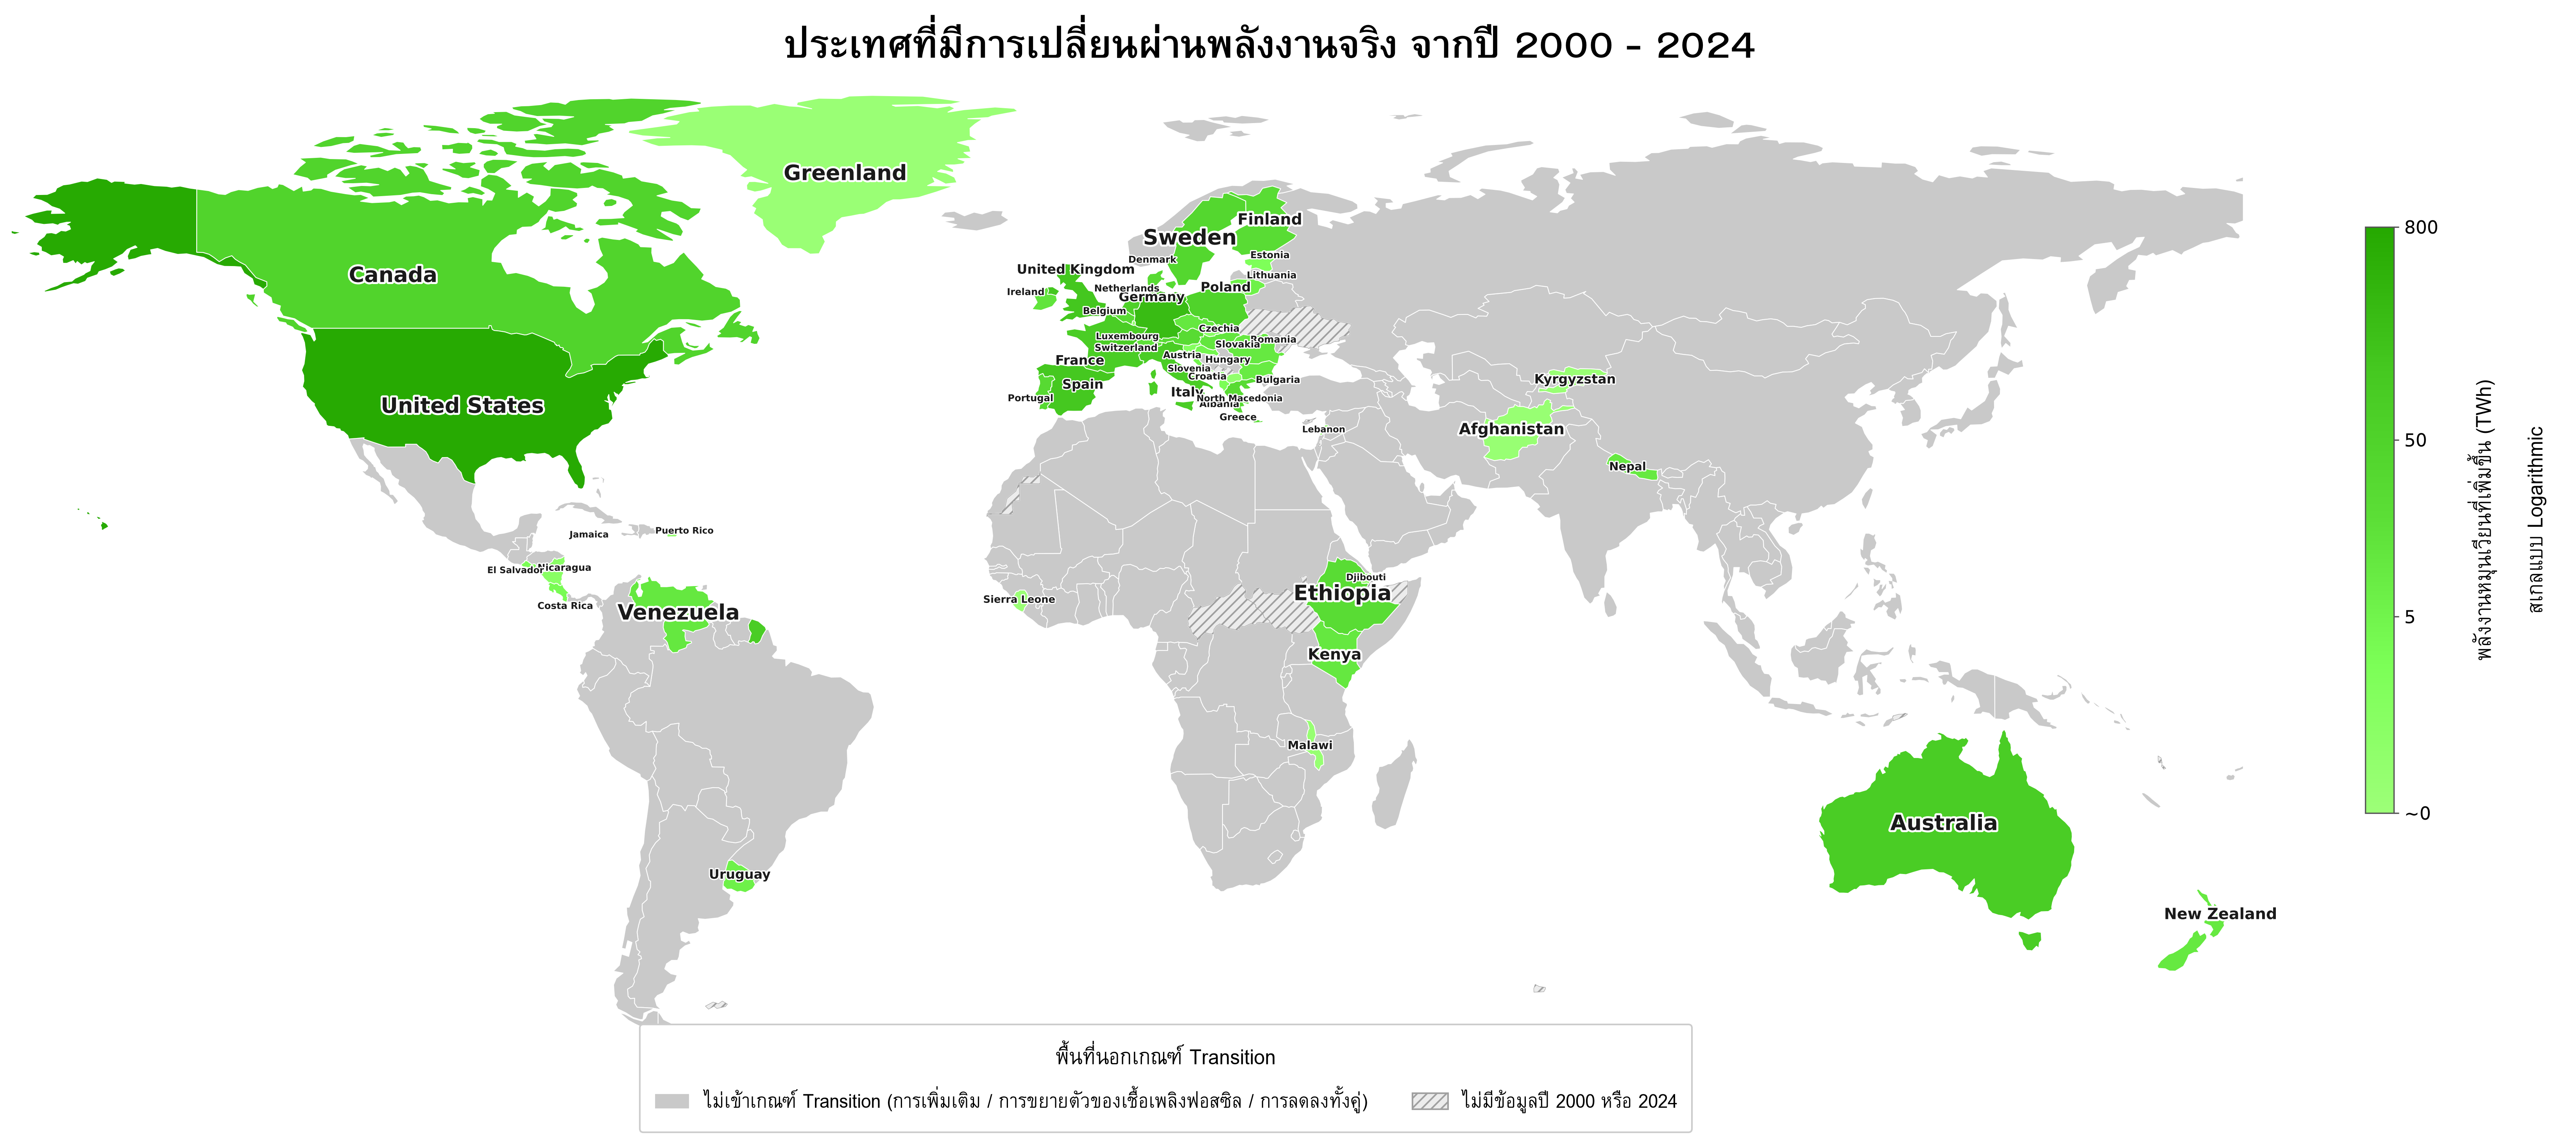

In [178]:
df = df.copy()
df['fossil'] = df['coal_electricity'] + df['gas_electricity'] + df['oil_electricity']
df['renewables'] = (df['hydro_electricity'] + df['solar_electricity']
                     + df['wind_electricity'] + df['other_renewable_electricity'])

p0 = df[df.year == 2000][['country', 'iso_code', 'fossil', 'renewables', 'electricity_generation']] \
        .rename(columns={'fossil': 'fossil_2000', 'renewables': 'ren_2000'})
p1 = df[df.year == 2024][['country', 'fossil', 'renewables', 'electricity_generation']] \
        .rename(columns={'fossil': 'fossil_2024', 'renewables': 'ren_2024',
                          'electricity_generation': 'gen_2024'})

m = p0.merge(p1, on='country').dropna(subset=['electricity_generation', 'gen_2024'])

m['delta_fossil'] = m['fossil_2024'] - m['fossil_2000']
m['delta_ren'] = m['ren_2024'] - m['ren_2000']

real_transition_map = m[(m['delta_fossil'] < 0) & (m['delta_ren'] > 0)].copy()
real_transition_map = real_transition_map.dropna(subset=['iso_code'])

print(f"จำนวนประเทศที่ Real Transition: {len(real_transition_map)}")

# ── สี: ไล่จากเขียวอ่อน -> สี RE หลัก (#25A800) -> เขียวเข้ม ─────────
C_RE        = '#25A800'
C_NOT_QUAL  = '#C9C9C9'   # มีข้อมูล แต่ไม่เข้าเกณฑ์
C_NO_DATA   = '#ECECEC'   # ไม่มีข้อมูล
C_HATCH     = '#A0A0A0'
green_scale = [
    [0.00, '#9DFF78'],
    [0.25, '#7CFF57'],
    [0.50, '#5CDF37'],
    [0.75, '#46C921'],
    [1.00, C_RE],
]
cmap = LinearSegmentedColormap.from_list('re_green', green_scale, N=256)

world = gpd.read_file("https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip")
world = world[world['NAME'] != 'Antarctica']

has_data_iso = set(m['iso_code'].dropna())

merged = world.merge(real_transition_map[['iso_code', 'country', 'delta_ren']],
                      left_on='ADM0_A3', right_on='iso_code', how='left')
merged['has_data'] = merged['ADM0_A3'].isin(has_data_iso)

vmin = 0
vmax_raw = real_transition_map['delta_ren'].max()
vmax = math.ceil(vmax_raw / 100) * 100
norm = SymLogNorm(linthresh=5, vmin=vmin, vmax=vmax)

# ── Layout: แผนที่เต็มความกว้าง + แถบสีแนวตั้งด้านขวา ────────────
fig = plt.figure(figsize=(22, 10), facecolor='white', dpi=300)
ax  = fig.add_axes([0.005, 0.10, 0.905, 0.82])     # เว้นด้านล่างไว้วาง legend

not_qualified = merged[merged['has_data'] & merged['delta_ren'].isna()]
not_qualified.plot(ax=ax, color=C_NOT_QUAL, edgecolor='white', linewidth=0.5)

no_data = merged[~merged['has_data']]
no_data.plot(ax=ax, color=C_NO_DATA, edgecolor='white', linewidth=0.5)
no_data.plot(ax=ax, facecolor='none', edgecolor=C_HATCH, hatch='////', linewidth=0.3)

transition_geo = merged.dropna(subset=['delta_ren'])
transition_geo.plot(ax=ax, column='delta_ren', cmap=cmap, norm=norm,
                     edgecolor='white', linewidth=0.5)
ax.set_axis_off()
ax.set_xlim(-170, 190)
ax.set_ylim(-58, 85)

# ── แถบสี (colorbar) ─────────────────────────────────────────
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar_ax = fig.add_axes([0.925, 0.30, 0.011, 0.50])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='vertical')

candidate_ticks = [0, 5, 50, vmax]
final_ticks = [t for t in candidate_ticks if t <= vmax]
cbar.set_ticks(final_ticks)
cbar.set_ticklabels(['~0' if t == 0 else f'{t:,.0f}' for t in final_ticks])
cbar.ax.minorticks_off()
cbar.ax.tick_params(labelsize=11, length=3, color='#555555')
cbar.outline.set_edgecolor('#555555'); cbar.outline.set_linewidth(0.8)
cbar.set_label('พลังงานหมุนเวียนที่เพิ่มขึ้น (TWh)\nสเกลแบบ Logarithmic',
               fontsize=12, fontfamily=GARUDA, labelpad=10, linespacing=1.5)

# ── Legend พื้นที่สีเทา (ใต้แผนที่ กึ่งกลาง) ────────────────────────
legend_items = [
    mpatches.Patch(facecolor=C_NOT_QUAL, edgecolor='white',
                   label='ไม่เข้าเกณฑ์ Transition (การเพิ่มเติม / การขยายตัวของเชื้อเพลิงฟอสซิล / การลดลงทั้งคู่)'),
    mpatches.Patch(facecolor=C_NO_DATA, edgecolor=C_HATCH, hatch='////',
                   label='ไม่มีข้อมูลปี 2000 หรือ 2024'),
]
fig.legend(handles=legend_items, loc='lower center', bbox_to_anchor=(0.46, 0.02), ncol=2,
           frameon=True, facecolor='white', framealpha=1.0, edgecolor='#CCCCCC',
           title='พื้นที่นอกเกณฑ์ Transition', borderpad=0.8, columnspacing=2.5,
           handlelength=2.0, handleheight=1.0,
           prop=fm.FontProperties(family=GARUDA, size=11),
           title_fontproperties=fm.FontProperties(family=GARUDA, size=12))

# ── ป้ายชื่อประเทศ (ขนาดตามพื้นที่ประเทศ) ────────────────────────
def font_for_area(a):
    if a < 3:  return 5.5
    if a < 8:  return 6.2
    if a < 15: return 7.0
    if a < 30: return 8.0
    if a < 70: return 9.5
    return 13.0

europe_dense = {'LUX','BEL','NLD','CHE','SVN','HRV','MKD','ALB','BGR','GRC','SVK','CZE',
                 'AUT','HUN','EST','LTU','DNK','IRL','GBR','PRT','DEU','POL','ITA','ESP','ROU',
                 'FRA'}
europe_big = {'GBR','DEU','POL','ITA','ESP','FRA'}
central_america = {'PRI','JAM','SLV','CRI','NIC'}

manual_offset = {
    'LUX': (-1.0,-2.0), 'BEL': (-3.4,0.9), 'NLD': (-0.6,2.8),
    'CHE': (-3.6,-0.8), 'SVN': (0.0,-3.2), 'HRV': (1.9,-2.8),
    'MKD': (0.9,-3.2), 'ALB': (-0.6,-3.6), 'BGR': (3.4,-1.5),
    'GRC': (0.5,-3.4), 'SVK': (2.6,-2.2), 'CZE': (3.8,-0.9),
    'AUT': (-1.4,-3.0), 'HUN': (1.6,-3.0), 'ROU': (3.6,1.2),
    'EST': (1.7,1.3), 'LTU': (3.4,1.7), 'DNK': (-0.6,2.8),
    'IRL': (-3.2,0.8), 'GBR': (-1.4,3.4), 'PRT': (-1.9,-1.0),
    'ESP': (1.5,0.6), 'DEU': (-1.7,2.1), 'POL': (1.3,3.1),
    'ITA': (1.7,-3.2), 'FRA': (-4.6, -2.8),
    'PRI': (2.0,0.5), 'JAM': (-2.2,0.2), 'SLV': (-2.0,-0.9),
    'CRI': (0.4,-2.1), 'NIC': (2.2,0.4),
}

trans_geo = merged.dropna(subset=['delta_ren']).copy()
trans_geo['area'] = trans_geo.geometry.area

for _, r in trans_geo.iterrows():
    pt = r.geometry.representative_point()
    fs = font_for_area(r['area'])
    iso = r['ADM0_A3']
    if iso in europe_dense:
        fs = 8.0 if iso in europe_big else min(fs, 5.8)
    if iso in central_america:
        fs = min(fs, 5.8)
    dx, dy = manual_offset.get(iso, (0, 0))
    halo_w = 2.5 if fs >= 9 else 1.5
    ax.text(pt.x + dx, pt.y + dy, r['country'], fontsize=fs, weight='bold', color='#1a1a1a',
            ha='center', va='center', zorder=10, fontfamily=DEJAVU,
            path_effects=[pe.withStroke(linewidth=halo_w, foreground='white')])

# ── หัวเรื่อง (กลางรูป) ─────────────────────────────────────────
fig.text(0.5, 0.955, 'ประเทศที่มีการเปลี่ยนผ่านพลังงานจริง จากปี 2000 - 2024',
         fontsize=22, fontfamily=GARUDA, fontweight='bold', color='#000000',
         ha='center', va='center')

plt.savefig('figure7.png', dpi=300, facecolor='white', bbox_inches='tight')
print("saved", "ticks:", final_ticks, "vmax:", vmax)